# MedAlert: Data Generation, Labeling, and Model Training

**Authors:**
- Nofer Refaeli 213357528
- Meital Gerasi


---

**Description:**  
This notebook contains the full pipeline for generating, cleaning, and modeling EMS pre-arrival reports. It includes:  
1. Data preparation and ASR dataset creation  
2. Transformer model training (DistilBERT, BioClinicalBERT)  
3. Evaluation on clean and noisy ASR datasets  
4. Error analysis  
5. Appendix: Experiments and hyperparameter tuning

A separate ASR notebook handles text-to-speech conversion, ambulance-noise injection and speech transcription.



## Dataset Loading and Initial Inspection

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import os

for file in os.listdir("/content"):
    print(file)

.config
dataset.zip
sample_data


In [ ]:
import zipfile
import os

zip_path = "dataset.zip"
extract_path = "/content/mimic-iv-ext-cds-1.0.2"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Main ZIP extracted successfully.")

Main ZIP extracted successfully.


In [ ]:
import zipfile
import os

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".zip"):
            inner_zip_path = os.path.join(root, file)

            print("Extracting inner ZIP:", inner_zip_path)

            with zipfile.ZipFile(inner_zip_path, "r") as zip_ref:
                zip_ref.extractall(root)

print("All inner ZIP files extracted successfully.")

Extracting inner ZIP: /content/mimic-iv-ext-cds-1.0.2/mimic-iv-ext-clinical-decision-support-for-referral-triage-and-diagnosis-1.0.2/clinical_data.csv.zip
All inner ZIP files extracted successfully.


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print("\nFolder:", root)
    for file in files:
        print("  ", file)


Folder: /content/mimic-iv-ext-cds-1.0.2

Folder: /content/mimic-iv-ext-cds-1.0.2/mimic-iv-ext-clinical-decision-support-for-referral-triage-and-diagnosis-1.0.2
   clinical_data.csv.zip
   specialty_referral.csv
   clinical_data.csv
   initial_assessment_info.csv
   README.txt
   vital_signs.csv
   LICENSE.txt
   patient_demographics.csv
   SHA256SUMS.txt
   specialty_referral_clinician_approved.csv
   triage_level.csv
   diagnosis.csv

Folder: /content/mimic-iv-ext-cds-1.0.2/mimic-iv-ext-clinical-decision-support-for-referral-triage-and-diagnosis-1.0.2/__MACOSX
   ._clinical_data.csv


In [ ]:
# ============================================================
# Safe CSV inspection - skip files that cannot be read
# ============================================================

import pandas as pd
import os

csv_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv"):
            path = os.path.join(root, file)
            csv_files.append(path)

print("Number of CSV files found:", len(csv_files))

for path in csv_files:
    print("\n" + "="*100)
    print("Trying to read:", path)

    try:
        temp_df = pd.read_csv(path, nrows=5)
        print("Read successfully.")
        print("Preview shape:", temp_df.shape)
        print("Columns:")
        print(list(temp_df.columns))

    except UnicodeDecodeError:
        print("UTF-8 failed. Trying latin1 encoding...")

        try:
            temp_df = pd.read_csv(path, nrows=5, encoding="latin1")
            print("Read successfully with latin1.")
            print("Preview shape:", temp_df.shape)
            print("Columns:")
            print(list(temp_df.columns))

        except Exception as e:
            print("Could not read this file.")
            print("Error:", e)

    except Exception as e:
        print("Could not read this file.")
        print("Error:", e)

Number of CSV files found: 9

Trying to read: /content/mimic-iv-ext-cds-1.0.2/mimic-iv-ext-clinical-decision-support-for-referral-triage-and-diagnosis-1.0.2/specialty_referral.csv
Read successfully.
Preview shape: (5, 5)
Columns:
['stay_id', 'HPI', 'patient_info', 'initial_vitals', 'specialty']

Trying to read: /content/mimic-iv-ext-cds-1.0.2/mimic-iv-ext-clinical-decision-support-for-referral-triage-and-diagnosis-1.0.2/clinical_data.csv
Read successfully.
Preview shape: (5, 8)
Columns:
['stay_id', 'text', 'HPI', 'tests', 'past_medication', 'diagnosis', 'primary_diagnosis', 'secondary_diagnosis']

Trying to read: /content/mimic-iv-ext-cds-1.0.2/mimic-iv-ext-clinical-decision-support-for-referral-triage-and-diagnosis-1.0.2/initial_assessment_info.csv
Read successfully.
Preview shape: (5, 9)
Columns:
['stay_id', 'triage', 'pain', 'chiefcomplaint', 'arrival_transport', 'disposition', 'icd_code', 'icd_title', 'icd_version']

Trying to read: /content/mimic-iv-ext-cds-1.0.2/mimic-iv-ext-clin

In [ ]:
# ============================================================
# Load selected task-specific files
# ============================================================

def find_file(root_dir, filename):
    """
    Find a file by name inside the extracted dataset folder.
    Ignores macOS hidden system folders.
    """
    for root, dirs, files in os.walk(root_dir):
        if "__MACOSX" in root:
            continue

        if filename in files:
            return os.path.join(root, filename)

    raise FileNotFoundError(f"Could not find {filename}")

triage_path = find_file(extract_path, "triage_level.csv")
diagnosis_path = find_file(extract_path, "diagnosis.csv")
referral_path = find_file(extract_path, "specialty_referral.csv")

triage_df = pd.read_csv(triage_path)
diagnosis_df = pd.read_csv(diagnosis_path)
referral_df = pd.read_csv(referral_path)

print("triage_df shape:", triage_df.shape)
print("diagnosis_df shape:", diagnosis_df.shape)
print("referral_df shape:", referral_df.shape)

print("\nTriage columns:")
print(triage_df.columns.tolist())

print("\nDiagnosis columns:")
print(diagnosis_df.columns.tolist())

print("\nReferral columns:")
print(referral_df.columns.tolist())

triage_df shape: (9149, 5)
diagnosis_df shape: (9149, 7)
referral_df shape: (2200, 5)

Triage columns:
['stay_id', 'HPI', 'patient_info', 'initial_vitals', 'triage']

Diagnosis columns:
['stay_id', 'HPI', 'patient_info', 'initial_vitals', 'diagnosis', 'primary_diagnosis', 'secondary_diagnosis']

Referral columns:
['stay_id', 'HPI', 'patient_info', 'initial_vitals', 'specialty']


## Data Preparation and Cleaning

In [ ]:
# ============================================================
# Merge the task-specific files by stay_id
# ============================================================

merged_df = triage_df.merge(
    diagnosis_df[["stay_id", "diagnosis", "primary_diagnosis", "secondary_diagnosis"]],
    on="stay_id",
    how="left"
)

merged_df = merged_df.merge(
    referral_df[["stay_id", "specialty"]],
    on="stay_id",
    how="left"
)

print("Merged shape:", merged_df.shape)

print("\nMerged columns:")
print(merged_df.columns.tolist())

print("\nMissing values per column:")
print(merged_df.isna().sum())

Merged shape: (9149, 9)

Merged columns:
['stay_id', 'HPI', 'patient_info', 'initial_vitals', 'triage', 'diagnosis', 'primary_diagnosis', 'secondary_diagnosis', 'specialty']

Missing values per column:
stay_id                   0
HPI                       1
patient_info              0
initial_vitals          370
triage                    0
diagnosis                 0
primary_diagnosis         0
secondary_diagnosis       0
specialty              6949
dtype: int64


In [ ]:
# ============================================================
# Create a clean prototype dataframe
# ============================================================

prototype_df = merged_df.dropna(subset=[
    "HPI",
    "initial_vitals",
    "specialty"
]).copy()

print("Original merged_df shape:", merged_df.shape)
print("Prototype df shape:", prototype_df.shape)

print("\nMissing values in prototype_df:")
print(prototype_df.isna().sum())

Original merged_df shape: (9149, 9)
Prototype df shape: (2139, 9)

Missing values in prototype_df:
stay_id                0
HPI                    0
patient_info           0
initial_vitals         0
triage                 0
diagnosis              0
primary_diagnosis      0
secondary_diagnosis    0
specialty              0
dtype: int64


In [ ]:
# ============================================================
# Inspect label-related distributions
# ============================================================

print("Triage distribution:")
print(prototype_df["triage"].value_counts(dropna=False))

print("\nTop 30 specialties:")
print(prototype_df["specialty"].value_counts(dropna=False).head(30))

print("\nNumber of unique specialties:")
print(prototype_df["specialty"].nunique())

print("\nNumber of unique diagnosis values:")
print(prototype_df["diagnosis"].nunique())

print("\nTop 30 diagnosis values:")
print(prototype_df["diagnosis"].value_counts(dropna=False).head(30))

Triage distribution:
triage
3    1225
2     773
1     123
4      18
Name: count, dtype: int64

Top 30 specialties:
specialty
['Gastroenterology']                                            338
['General Surgery']                                             270
['Orthopedics']                                                 177
['Neurosurgery']                                                 66
['Neurology']                                                    65
['Vascular Surgery']                                             43
['Gastroenterology', 'Gastroenterology']                         42
['Cardiology']                                                   35
['Urology']                                                      34
['Orthopedic Surgery']                                           33
['Dermatology']                                                  32
['Infectious Disease']                                           28
['Pulmonology']                                            

In [ ]:
# ============================================================
# Clean specialty and diagnosis fields
# ============================================================

import ast
import re

def clean_text_value(x):
    """
    Clean simple text fields:
    - convert to string
    - remove new lines
    - collapse multiple spaces
    - lowercase
    """
    if pd.isna(x):
        return ""

    x = str(x)
    x = x.replace("\n", " ")
    x = re.sub(r"\s+", " ", x).strip()
    x = x.lower()

    return x


def parse_specialty_list(x):
    """
    Convert specialty text into a clean list.
    The original values often look like:
    "['Gastroenterology', 'Gastroenterology']"

    This function:
    - parses the list if possible
    - lowercases values
    - removes duplicates inside the same case
    """
    if pd.isna(x):
        return []

    x = str(x).strip()

    if x == "" or x.lower() == "nan":
        return []

    try:
        parsed = ast.literal_eval(x)

        if isinstance(parsed, list):
            cleaned = []

            for item in parsed:
                item_clean = clean_text_value(item)

                if item_clean and item_clean != "no answer":
                    cleaned.append(item_clean)

            # Remove duplicates while preserving order
            cleaned_unique = list(dict.fromkeys(cleaned))
            return cleaned_unique

    except Exception:
        pass

    # Fallback if the value is not a valid list
    fallback = clean_text_value(x)

    if fallback and fallback != "no answer":
        return [fallback]

    return []


prototype_df["specialty_clean_list"] = prototype_df["specialty"].apply(parse_specialty_list)
prototype_df["diagnosis_clean"] = prototype_df["diagnosis"].apply(clean_text_value)
prototype_df["primary_diagnosis_clean"] = prototype_df["primary_diagnosis"].apply(clean_text_value)
prototype_df["secondary_diagnosis_clean"] = prototype_df["secondary_diagnosis"].apply(clean_text_value)

print("Example cleaned specialties:")
print(prototype_df[["specialty", "specialty_clean_list"]].head(10))

print("\nExample cleaned diagnoses:")
print(prototype_df[["diagnosis", "diagnosis_clean"]].head(10))

Example cleaned specialties:
                                           specialty  \
0                       ['Neurology', 'Pulmonology']   
1                               ['Gastroenterology']   
2           ['Vascular Surgery', 'Vascular Surgery']   
3                                   ['Neurosurgery']   
4  ['Addiction Medicine', 'Gastroenterology', 'He...   
5                               ['Gastroenterology']   
6                    ['Ophthalmology', 'Hematology']   
7                                    ['Orthopedics']   
8  ['Orthopedics', 'Emergency Medicine', 'Neurosu...   
9               ['Nephrology', 'Infectious Disease']   

                                specialty_clean_list  
0                           [neurology, pulmonology]  
1                                 [gastroenterology]  
2                                 [vascular surgery]  
3                                     [neurosurgery]  
4  [addiction medicine, gastroenterology, hematol...  
5                       

In [ ]:
# ============================================================
# Inspect cleaned specialty and diagnosis distributions
# ============================================================

from collections import Counter

# Count each specialty after cleaning
specialty_counter = Counter()

for specialties in prototype_df["specialty_clean_list"]:
    for spec in specialties:
        specialty_counter[spec] += 1

print("Top 30 cleaned specialties:")
for spec, count in specialty_counter.most_common(30):
    print(spec, ":", count)


print("\nNumber of unique cleaned specialties:")
print(len(specialty_counter))


print("\nTop 30 cleaned diagnoses:")
print(prototype_df["diagnosis_clean"].value_counts().head(30))

print("\nNumber of unique cleaned diagnoses:")
print(prototype_df["diagnosis_clean"].nunique())

Top 30 cleaned specialties:
gastroenterology : 615
orthopedics : 323
general surgery : 323
neurology : 186
cardiology : 163
neurosurgery : 127
pulmonology : 120
urology : 119
nephrology : 101
hematology : 100
endocrinology : 93
vascular surgery : 82
emergency medicine : 77
dermatology : 62
infectious disease : 59
oncology : 57
internal medicine : 50
otolaryngology : 46
orthopedic surgery : 44
psychiatry : 39
oral and maxillofacial surgery : 29
colorectal surgery : 27
rheumatology : 26
hepatology : 23
addiction medicine : 22
gynecology : 21
obstetrics and gynecology : 17
ophthalmology : 16
pain management : 12
allergy and immunology : 12

Number of unique cleaned specialties:
63

Top 30 cleaned diagnoses:
diagnosis_clean
acute appendicitis                    78
small bowel obstruction               37
acute cholecystitis                   31
abdominal pain                        23
appendicitis                          16
partial small bowel obstruction        9
diverticulitis          

Vital Signs Extraction and Cleaning

In [ ]:
# ============================================================
# Inspect raw initial_vitals format
# ============================================================

pd.set_option("display.max_colwidth", 500)

print("Examples of initial_vitals format:")
display(prototype_df["initial_vitals"].dropna().head(10))

Examples of initial_vitals format:


,initial_vitals
0,"Temperature: 100.2, Heartrate: 95.0, resprate: 28.0, o2sat: 100.0, sbp: 99.0, dbp: 47.0"
1,"Temperature: 97.8, Heartrate: 87.0, resprate: 26.0, o2sat: 99.0, sbp: 119.0, dbp: 63.0"
2,"Temperature: 98.7, Heartrate: 93.0, resprate: 16.0, o2sat: 99.0, sbp: 166.0, dbp: 97.0"
3,"Temperature: 97.0, Heartrate: 75.0, resprate: 18.0, o2sat: 97.0, sbp: 161.0, dbp: 76.0"
4,"Temperature: 97.1, Heartrate: 100.0, resprate: 18.0, o2sat: 98.0, sbp: 130.0, dbp: 98.0"
5,"Temperature: 97.8, Heartrate: 90.0, resprate: 14.0, o2sat: 100.0, sbp: 124.0, dbp: 86.0"
6,"Temperature: 97.9, Heartrate: 84.0, resprate: 20.0, o2sat: 99.0, sbp: 176.0, dbp: 74.0"
7,"Temperature: 98.6, Heartrate: 88.0, resprate: 18.0, o2sat: 97.0, sbp: 108.0, dbp: 73.0"
8,"Temperature: 98.8, Heartrate: 110.0, resprate: 20.0, o2sat: 96.0, sbp: 163.0, dbp: 99.0"
9,"Temperature: 100.1, Heartrate: 128.0, resprate: 20.0, o2sat: 99.0, sbp: 151.0, dbp: 73.0"


In [ ]:
# ============================================================
# Re-extract numeric vital signs from initial_vitals
# with patterns that match the actual dataset format
# ============================================================

import re
import numpy as np
import pandas as pd

def find_number(text, patterns):
    """
    Search for the first numeric value that matches one of the patterns.
    Returns float or NaN.
    """
    text = str(text).lower()

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_initial_vitals_fixed(vitals_text):
    """
    Extract initial vital signs from the actual format:
    Temperature: 100.2, Heartrate: 95.0, resprate: 28.0,
    o2sat: 100.0, sbp: 99.0, dbp: 47.0
    """
    text = str(vitals_text).lower()

    vitals = {
        "temperature": find_number(text, [
            r"temperature\s*:\s*([0-9.]+)",
            r"temp\s*:\s*([0-9.]+)"
        ]),

        "heart_rate": find_number(text, [
            r"heartrate\s*:\s*([0-9.]+)",
            r"heart rate\s*:\s*([0-9.]+)",
            r"\bhr\s*:\s*([0-9.]+)"
        ]),

        "respiration_rate": find_number(text, [
            r"resprate\s*:\s*([0-9.]+)",
            r"respiration rate\s*:\s*([0-9.]+)",
            r"respiratory rate\s*:\s*([0-9.]+)",
            r"\brr\s*:\s*([0-9.]+)"
        ]),

        "oxygen_saturation": find_number(text, [
            r"o2sat\s*:\s*([0-9.]+)",
            r"oxygen saturation\s*:\s*([0-9.]+)",
            r"spo2\s*:\s*([0-9.]+)"
        ]),

        "systolic_bp": find_number(text, [
            r"sbp\s*:\s*([0-9.]+)",
            r"systolic blood pressure\s*:\s*([0-9.]+)"
        ]),

        "diastolic_bp": find_number(text, [
            r"dbp\s*:\s*([0-9.]+)",
            r"diastolic blood pressure\s*:\s*([0-9.]+)"
        ]),
    }

    return vitals


# Remove old extracted vital columns if they already exist
vital_cols = [
    "temperature",
    "heart_rate",
    "respiration_rate",
    "oxygen_saturation",
    "systolic_bp",
    "diastolic_bp"
]

prototype_df = prototype_df.drop(columns=[col for col in vital_cols if col in prototype_df.columns])

# Re-parse vitals
vitals_parsed = prototype_df["initial_vitals"].apply(parse_initial_vitals_fixed)
vitals_df = pd.DataFrame(vitals_parsed.tolist())

prototype_df = pd.concat(
    [prototype_df.reset_index(drop=True), vitals_df.reset_index(drop=True)],
    axis=1
)

print("Prototype shape after re-adding vitals:", prototype_df.shape)

print("\nExtracted vitals missing values BEFORE cleaning:")
print(prototype_df[vital_cols].isna().sum())

print("\nExtracted vitals summary BEFORE cleaning:")
display(prototype_df[vital_cols].describe())

Prototype shape after re-adding vitals: (2139, 19)

Extracted vitals missing values BEFORE cleaning:
temperature          42
heart_rate            7
respiration_rate     31
oxygen_saturation    28
systolic_bp          10
diastolic_bp         12
dtype: int64

Extracted vitals summary BEFORE cleaning:


,temperature,heart_rate,respiration_rate,oxygen_saturation,systolic_bp,diastolic_bp
count,2097.000000,2132.000000,2108.000000,2111.000000,2129.000000,2127.000000
mean,98.126726,84.890713,17.513757,98.063003,143.565524,76.783733
std,1.979763,18.003357,2.211911,3.882066,425.386791,27.136189
min,18.000000,16.000000,12.000000,9.000000,15.000000,24.000000
25%,97.600000,72.000000,16.000000,97.000000,118.000000,66.000000
50%,98.100000,84.000000,18.000000,99.000000,133.000000,76.000000
75%,98.600000,96.000000,18.000000,100.000000,148.000000,85.000000
max,104.400000,164.000000,46.000000,100.000000,19734.000000,698.000000


In [ ]:
# ============================================================
# Inspect suspicious blood pressure parsing
# ============================================================

suspicious_bp = prototype_df[
    (prototype_df["systolic_bp"] > 300) |
    (prototype_df["diastolic_bp"] > 200) |
    (prototype_df["systolic_bp"] < 50) |
    (prototype_df["diastolic_bp"] < 20)
][["initial_vitals", "systolic_bp", "diastolic_bp"]]

print("Number of suspicious BP rows:", len(suspicious_bp))
display(suspicious_bp.head(10))

Number of suspicious BP rows: 6


,initial_vitals,systolic_bp,diastolic_bp
913,"Temperature: 97.1, Heartrate: 84.0, resprate: 18.0, o2sat: 99.0, sbp: 127.0, dbp: 698.0",127.0,698.0
1287,"Temperature: 97.7, Heartrate: 73.0, resprate: 15.0, o2sat: 100.0, sbp: 133.0, dbp: 674.0",133.0,674.0
1317,"Temperature: 98.2, Heartrate: 116.0, resprate: 18.0, o2sat: 89.0, sbp: 18.0",18.0,NaN
1776,"Temperature: 96.3, Heartrate: 97.0, resprate: 20.0, o2sat: 99.0, sbp: 19734.0, dbp: 87.0",19734.0,87.0
1913,"Temperature: 99.3, Heartrate: 96.0, o2sat: 97.0, sbp: 15.0, dbp: 65.0",15.0,65.0
2096,"Temperature: 98.0, Heartrate: 62.0, resprate: 18.0, o2sat: 95.0, sbp: 114.0, dbp: 696.0",114.0,696.0


In [ ]:
# ============================================================
# Clean clinically implausible vital values
# ============================================================

# Keep a copy before cleaning, for documentation
prototype_df["systolic_bp_raw"] = prototype_df["systolic_bp"]
prototype_df["diastolic_bp_raw"] = prototype_df["diastolic_bp"]

# Replace implausible values with NaN
prototype_df.loc[
    (prototype_df["systolic_bp"] < 50) | (prototype_df["systolic_bp"] > 300),
    "systolic_bp"
] = np.nan

prototype_df.loc[
    (prototype_df["diastolic_bp"] < 20) | (prototype_df["diastolic_bp"] > 200),
    "diastolic_bp"
] = np.nan

prototype_df.loc[
    (prototype_df["heart_rate"] < 20) | (prototype_df["heart_rate"] > 250),
    "heart_rate"
] = np.nan

prototype_df.loc[
    (prototype_df["respiration_rate"] < 4) | (prototype_df["respiration_rate"] > 80),
    "respiration_rate"
] = np.nan

prototype_df.loc[
    (prototype_df["oxygen_saturation"] < 40) | (prototype_df["oxygen_saturation"] > 100),
    "oxygen_saturation"
] = np.nan

prototype_df.loc[
    (prototype_df["temperature"] < 80) | (prototype_df["temperature"] > 110),
    "temperature"
] = np.nan

print("Missing values AFTER plausibility cleaning:")
print(prototype_df[vital_cols].isna().sum())

print("\nVitals summary AFTER cleaning:")
display(prototype_df[vital_cols].describe())

Missing values AFTER plausibility cleaning:
temperature          43
heart_rate            8
respiration_rate     31
oxygen_saturation    31
systolic_bp          13
diastolic_bp         15
dtype: int64

Vitals summary AFTER cleaning:


,temperature,heart_rate,respiration_rate,oxygen_saturation,systolic_bp,diastolic_bp
count,2096.000000,2131.000000,2108.000000,2108.000000,2126.000000,2124.000000
mean,98.164954,84.923041,17.513757,98.186433,134.470367,75.918550
std,0.924821,17.945580,2.211911,2.085925,22.509184,14.362459
min,95.000000,36.000000,12.000000,75.000000,68.000000,24.000000
25%,97.600000,72.000000,16.000000,97.000000,118.000000,66.000000
50%,98.100000,84.000000,18.000000,99.000000,133.000000,76.000000
75%,98.600000,96.000000,18.000000,100.000000,148.000000,85.000000
max,104.400000,164.000000,46.000000,100.000000,239.000000,126.000000


In [ ]:
# ============================================================
# Check suspicious vitals after cleaning
# ============================================================

suspicious_after_cleaning = prototype_df[
    (prototype_df["systolic_bp"] > 300) |
    (prototype_df["diastolic_bp"] > 200) |
    (prototype_df["heart_rate"] > 250) |
    (prototype_df["respiration_rate"] > 80) |
    (prototype_df["oxygen_saturation"] > 100) |
    (prototype_df["temperature"] > 110)
]

print("Number of suspicious rows after cleaning:", len(suspicious_after_cleaning))

Number of suspicious rows after cleaning: 0


In [ ]:
# ============================================================
# Print all unique specialties and their counts
# ============================================================

from collections import Counter

specialty_counter = Counter()

for specialty_list in prototype_df["specialty_clean_list"]:
    if isinstance(specialty_list, list):
        for specialty in specialty_list:
            specialty_counter[specialty] += 1

print("Number of unique specialties:", len(specialty_counter))
print("\nAll specialties and counts:")
print("=" * 80)

for specialty, count in specialty_counter.most_common():
    print(f"{specialty}: {count}")

Number of unique specialties: 63

All specialties and counts:
gastroenterology: 615
orthopedics: 323
general surgery: 323
neurology: 186
cardiology: 163
neurosurgery: 127
pulmonology: 120
urology: 119
nephrology: 101
hematology: 100
endocrinology: 93
vascular surgery: 82
emergency medicine: 77
dermatology: 62
infectious disease: 59
oncology: 57
internal medicine: 50
otolaryngology: 46
orthopedic surgery: 44
psychiatry: 39
oral and maxillofacial surgery: 29
colorectal surgery: 27
rheumatology: 26
hepatology: 23
addiction medicine: 22
gynecology: 21
obstetrics and gynecology: 17
ophthalmology: 16
pain management: 12
allergy and immunology: 12
hematology-oncology: 9
gynecologic oncology: 8
podiatry: 7
pediatrics: 6
bariatric surgery: 5
trauma surgery: 5
interventional radiology: 5
family medicine: 5
nutrition: 4
thoracic surgery: 4
dentistry: 3
radiology: 3
anesthesiology: 3
reproductive endocrinology: 3
unknown specialty: 2
plastic surgery: 2
sleep medicine: 2
sports medicine: 1
toxicolo

## Rule-Based Target Label Creation

**Arrival Destination Label**

In [ ]:
# ============================================================
# Improved keyword matching helpers
# ============================================================

import re
import pandas as pd

def has_word(text, word):
    """
    Match a full word only.
    Example:
    has_word(text, "flu") will NOT match "fluid".
    """
    text = str(text).lower()
    pattern = r"\b" + re.escape(word.lower()) + r"\b"
    return re.search(pattern, text) is not None


def has_phrase(text, phrase):
    """
    Match a phrase with word boundaries around it.
    Safer than simple 'phrase in text'.
    """
    text = str(text).lower()
    phrase = phrase.lower().strip()
    pattern = r"\b" + re.escape(phrase) + r"\b"
    return re.search(pattern, text) is not None


def has_any_phrase(text, phrases):
    """
    Check if any phrase appears safely in the text.
    """
    return any(has_phrase(text, phrase) for phrase in phrases)

In [ ]:
# ============================================================
# Create cleaner text field for rule-based labeling
# ============================================================

def shorten_text(x, max_chars=1200):
    """
    Keep text short enough so discharge instructions do not dominate the rules.
    """
    if pd.isna(x):
        return ""

    x = str(x)
    x = re.sub(r"\s+", " ", x).strip().lower()

    return x[:max_chars]


def combine_case_text_for_rules_clean(row):
    """
    Create a cleaner combined text field for rule-based labeling.
    We keep the clinically relevant fields, but avoid letting very long
    discharge/instruction text dominate the rules.
    """
    hpi_text = shorten_text(row.get("HPI", ""), max_chars=1000)
    diagnosis_text = shorten_text(row.get("diagnosis_clean", ""), max_chars=300)
    primary_dx_text = shorten_text(row.get("primary_diagnosis_clean", ""), max_chars=300)
    secondary_dx_text = shorten_text(row.get("secondary_diagnosis_clean", ""), max_chars=300)
    specialty_text = " ".join(row.get("specialty_clean_list", []))

    parts = [
        hpi_text,
        diagnosis_text,
        primary_dx_text,
        secondary_dx_text,
        specialty_text
    ]

    combined = " ".join([p for p in parts if p])
    combined = re.sub(r"\s+", " ", combined).strip().lower()

    return combined


prototype_df["case_text_for_rules_clean"] = prototype_df.apply(
    combine_case_text_for_rules_clean,
    axis=1
)

print("Example clean rule text:")
display(prototype_df[["case_text_for_rules_clean"]].head(3))

Example clean rule text:


,case_text_for_rules_clean
0,"patient is an ___ year-old patient with history of sjogren's syndrome, moderate mr, recent hospitalization for sepsis secondary to c. diff colitis complicated by hypercarbic respiratory failure requiring intubation, who is presenting from ___ with worsening dyspnea for one day. patient was discharged from ___ yesterday (___) following hospitalization for c. diff colitis. patient had abg at ___, which was 7.___. her vitals on transfer were 97.9 99 24 113/68 92% 2l. she reports shortness of br..."
1,"___ year old male with history to intestinal sarcoidosis s/p ex.laparoscopy, right colectomy ___ (___), itp s/p open splenectomy, and inguinal hernia repair complaining of new abdominal pain that started last night and has now progressed to ___ with 1 episode of foot particulate emesis. he denies fevers and chills. he has never had an episode like this before. he reports he urinated this am without difficulty. it is difficult for him to breath this am. he also has new bilateral shoulder pain..."
2,"___ w rt ak pop to ___ bypass with nrgsv for a thrombosed popliteal aneurysm in ___ present with worsening new onset right foot claudication. peripheral arterial disease right posterior tibial deep vein thrombosis ['peripheral arterial disease', 'right posterior tibial deep vein thrombosis'] [] vascular surgery"


In [ ]:
# ============================================================
# Arrival destination:
# Add intermediate rule for high-risk injuries -> monitored_bed
# ============================================================

def derive_arrival_destination_with_reason_v3(row):
    text = str(row["case_text_for_rules_clean"]).lower()

    triage = str(row["triage"]).strip()

    sbp = row["systolic_bp"]
    hr = row["heart_rate"]
    rr = row["respiration_rate"]
    spo2 = row["oxygen_saturation"]

    # --------------------------------------------------------
    # Trauma bay logic - strict
    # --------------------------------------------------------
    trauma_mechanism = has_any_phrase(text, [
        "motor vehicle collision",
        "motor vehicle crash",
        "hit by car",
        "pedestrian struck",
        "restrained passenger",
        "rear ended",
        "gunshot wound",
        "stab wound",
        "assault",
        "fell from",
        "fall from",
        "fall down",
        "traumatic injury"
    ])

    major_trauma_finding = has_any_phrase(text, [
        "unstable c5",
        "cervical spine fracture",
        "tibia-fibula fracture",
        "femur fracture",
        "pelvic fracture",
        "multiple fractures",
        "open fracture",
        "subarachnoid hemorrhage",
        "head laceration"
    ])

    trauma_case = trauma_mechanism or major_trauma_finding

    # --------------------------------------------------------
    # High-risk injury logic
    # These cases may not need trauma_bay, but should not be standard bed.
    # --------------------------------------------------------
    high_risk_injury = has_any_phrase(text, [
        "cervical spine fracture",
        "c-spine",
        "c2 fracture",
        "c4-5",
        "vertebral body fracture",
        "subdural hematoma",
        "subarachnoid hemorrhage",
        "head strike",
        "head injury",
        "loss of consciousness",
        "femur fracture",
        "femoral neck fracture",
        "hip fracture",
        "pelvic fracture",
        "tibia-fibula fracture",
        "fracture/dislocation",
        "on coumadin",
        "on warfarin",
        "anticoagulation"
    ])

    # --------------------------------------------------------
    # Isolation logic - strict
    # --------------------------------------------------------
    clear_isolation_risk = has_any_phrase(text, [
        "covid",
        "coronavirus",
        "influenza",
        "tuberculosis",
        "c diff",
        "c. diff",
        "clostridium difficile",
        "infectious diarrhea",
        "contact isolation",
        "airborne isolation",
        "droplet isolation"
    ])

    respiratory_infection_risk = (
        has_any_phrase(text, [
            "pneumonia",
            "respiratory infection",
            "viral respiratory infection"
        ])
        and
        has_any_phrase(text, [
            "cough",
            "fever",
            "shortness of breath",
            "dyspnea",
            "hypoxia"
        ])
    )

    infectious_isolation_case = clear_isolation_risk or respiratory_infection_risk

    # --------------------------------------------------------
    # Instability logic
    # --------------------------------------------------------
    unstable_by_triage = triage == "1"

    unstable_by_vitals = (
        (pd.notna(sbp) and sbp < 90) or
        (pd.notna(spo2) and spo2 < 90) or
        (pd.notna(rr) and (rr < 8 or rr > 30)) or
        (pd.notna(hr) and (hr > 140 or hr < 40))
    )

    unstable_by_text = has_any_phrase(text, [
        "shock",
        "unresponsive",
        "non-responsive",
        "cardiac arrest",
        "intubated",
        "minimally responsive"
    ])

    unstable = unstable_by_triage or unstable_by_vitals or unstable_by_text

    # --------------------------------------------------------
    # Rule order
    # --------------------------------------------------------
    if trauma_case and unstable:
        return "trauma_bay", "strict_trauma_case_and_unstable"

    elif unstable_by_vitals:
        return "resuscitation_bay", "unstable_vitals"

    elif unstable_by_text:
        return "resuscitation_bay", "unstable_text"

    elif unstable_by_triage:
        return "resuscitation_bay", "triage_1"

    elif infectious_isolation_case:
        return "isolation_room", "strict_infection_control_risk"

    elif triage == "2":
        return "monitored_bed", "triage_2"

    elif pd.notna(spo2) and spo2 < 94:
        return "monitored_bed", "low_oxygen_saturation"

    elif pd.notna(hr) and (hr > 120 or hr < 50):
        return "monitored_bed", "abnormal_heart_rate"

    elif high_risk_injury:
        return "monitored_bed", "high_risk_injury_needs_monitoring"

    elif triage == "4":
        return "triage_or_waiting_room", "triage_4_low_acuity"

    else:
        return "standard_ed_bed", "default_stable_ed_bed"


arrival_results = prototype_df.apply(
    derive_arrival_destination_with_reason_v3,
    axis=1
)

prototype_df["arrival_destination"] = arrival_results.apply(lambda x: x[0])
prototype_df["arrival_destination_reason"] = arrival_results.apply(lambda x: x[1])

print("Arrival destination distribution after v3 high-risk injury rule:")
print(prototype_df["arrival_destination"].value_counts())

print("\nArrival destination reasons after v3:")
print(prototype_df["arrival_destination_reason"].value_counts())

Arrival destination distribution after v3 high-risk injury rule:
arrival_destination
standard_ed_bed           1054
monitored_bed              869
resuscitation_bay          145
isolation_room              48
triage_or_waiting_room      17
trauma_bay                   6
Name: count, dtype: int64

Arrival destination reasons after v3:
arrival_destination_reason
default_stable_ed_bed                1054
triage_2                              736
high_risk_injury_needs_monitoring      98
triage_1                               79
strict_infection_control_risk          48
unstable_vitals                        40
unstable_text                          26
abnormal_heart_rate                    19
triage_4_low_acuity                    17
low_oxygen_saturation                  16
strict_trauma_case_and_unstable         6
Name: count, dtype: int64


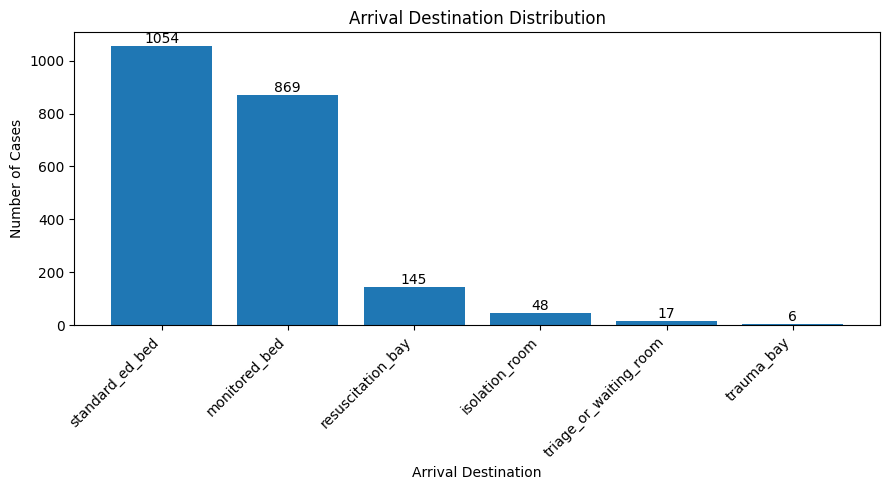

In [ ]:
# ============================================================
# Plot arrival_destination distribution with counts on bars
# ============================================================

import matplotlib.pyplot as plt

arrival_counts = prototype_df["arrival_destination"].value_counts()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    arrival_counts.index,
    arrival_counts.values
)

plt.title("Arrival Destination Distribution")
plt.xlabel("Arrival Destination")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45, ha="right")

# Add count labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Specialty Consultation Labels

**specialty consult label: Single-label**

In [ ]:
# ============================================================
# Inspect original cleaned specialties before grouping
# ============================================================

from collections import Counter

original_specialty_counter = Counter()

for specialty_list in prototype_df["specialty_clean_list"]:
    if isinstance(specialty_list, list):
        for specialty in specialty_list:
            original_specialty_counter[specialty] += 1

print("Number of unique original cleaned specialties before grouping:")
print(len(original_specialty_counter))

print("\nOriginal cleaned specialty distribution before grouping:")
print("=" * 80)

for specialty, count in original_specialty_counter.most_common():
    print(specialty, ":", count)

Number of unique original cleaned specialties before grouping:
63

Original cleaned specialty distribution before grouping:
gastroenterology : 615
orthopedics : 323
general surgery : 323
neurology : 186
cardiology : 163
neurosurgery : 127
pulmonology : 120
urology : 119
nephrology : 101
hematology : 100
endocrinology : 93
vascular surgery : 82
emergency medicine : 77
dermatology : 62
infectious disease : 59
oncology : 57
internal medicine : 50
otolaryngology : 46
orthopedic surgery : 44
psychiatry : 39
oral and maxillofacial surgery : 29
colorectal surgery : 27
rheumatology : 26
hepatology : 23
addiction medicine : 22
gynecology : 21
obstetrics and gynecology : 17
ophthalmology : 16
pain management : 12
allergy and immunology : 12
hematology-oncology : 9
gynecologic oncology : 8
podiatry : 7
pediatrics : 6
bariatric surgery : 5
trauma surgery : 5
interventional radiology : 5
family medicine : 5
nutrition : 4
thoracic surgery : 4
dentistry : 3
radiology : 3
anesthesiology : 3
reproducti

In [ ]:
# ============================================================
# Map cleaned specialties into broader specialty consult labels
# ============================================================

def map_specialty_to_consult_group(specialty):
    """
    Map each cleaned specialty name into a broader consult label.
    This reduces raw specialties into fewer clinically meaningful groups.
    """
    specialty = str(specialty).lower().strip()

    # Gastro / liver
    if specialty in [
        "gastroenterology",
        "hepatology",
        "bariatric surgery"
    ]:
        return "gastroenterology_consult"

    # Orthopedics
    elif specialty in [
        "orthopedics",
        "orthopedic surgery",
        "sports medicine",
        "orthopedic oncology",
        "hand surgery",
        "podiatry",
        "physical medicine and rehabilitation"
    ]:
        return "orthopedic_consult"

    # General surgery
    elif specialty in [
        "general surgery",
        "colorectal surgery",
        "trauma surgery",
        "transplant surgery"
    ]:
        return "general_surgery_consult"

    # Neurology
    elif specialty in [
        "neurology",
        "sleep medicine"
    ]:
        return "neurology_consult"

    # Neurosurgery
    elif specialty == "neurosurgery":
        return "neurosurgery_consult"

    # Cardiology / cardiothoracic
    elif specialty in [
        "cardiology",
        "cardiothoracic surgery"
    ]:
        return "cardiology_consult"

    # Pulmonary / thoracic
    elif specialty in [
        "pulmonology",
        "thoracic surgery"
    ]:
        return "pulmonology_consult"

    # Urology / urogynecology
    elif specialty in [
        "urology",
        "urogynecology"
    ]:
        return "urology_consult"

    # Nephrology
    elif specialty in [
        "nephrology",
        "transplant nephrology"
    ]:
        return "nephrology_consult"

    # Hematology / oncology
    elif specialty in [
        "hematology",
        "oncology",
        "hematology-oncology",
        "hematology/oncology",
        "gynecologic oncology"
    ]:
        return "hematology_oncology_consult"

    # Endocrinology
    # Keep this as a separate label because it has enough cases
    # and it represents a meaningful clinical group.
    elif specialty in [
        "endocrinology",
        "reproductive endocrinology",
        "reproductive endocrinology and infertility"
    ]:
        return "endocrinology_consult"

    # Vascular
    elif specialty in [
        "vascular surgery",
        "interventional radiology"
    ]:
        return "vascular_surgery_consult"

    # Psychiatry / addiction / toxicology
    # Keep this as a separate label instead of merging into other_consult.
    elif specialty in [
        "psychiatry",
        "addiction medicine",
        "toxicology"
    ]:
        return "psychiatry_addiction_consult"

    # OB/GYN
    elif specialty in [
        "gynecology",
        "obstetrics and gynecology",
        "obstetrics"
    ]:
        return "obgyn_consult"

    # Infectious disease + dermatology / wound
    # This group captures infections, cellulitis, skin/soft tissue issues, and wound-related cases.
    elif specialty in [
        "infectious disease",
        "dermatology",
        "wound care"
    ]:
        return "infectious_dermatology_consult"

    # Medicine / ED
    elif specialty in [
        "emergency medicine",
        "internal medicine",
        "family medicine",
        "geriatrics"
    ]:
        return "medicine_or_ed_consult"

    # ENT / eyes / oral / dental
    elif specialty in [
        "otolaryngology",
        "ophthalmology",
        "oral and maxillofacial surgery",
        "dentistry",
        "periodontology"
    ]:
        return "ent_or_eye_oral_consult"

    # Allergy/immunology should not be mapped to infectious disease,
    # because cases like anaphylaxis are not infectious.
    elif specialty in [
        "allergy and immunology"
    ]:
        return "other_consult"

    # Other small or less frequent specialties
    else:
        return "other_consult"

In [ ]:
# ============================================================
# Create final single-label specialty consult target
# ============================================================

def create_specialty_consult_label(specialty_list):
    """
    Create a single final specialty consult label from specialty_clean_list.

    Logic:
    1. Map all specialties into broader consult groups.
    2. Remove duplicate mapped labels while preserving order.
    3. Prefer a specific consult label over generic labels
       such as medicine_or_ed_consult or other_consult.
    """

    # If the specialty list is missing or empty, assign other_consult
    if not isinstance(specialty_list, list) or len(specialty_list) == 0:
        return "other_consult"

    mapped_labels = []

    # Map each raw specialty into a broader consult group
    for specialty in specialty_list:
        mapped_label = map_specialty_to_consult_group(specialty)
        mapped_labels.append(mapped_label)

    # Remove duplicate labels while preserving their original order
    mapped_labels = list(dict.fromkeys(mapped_labels))

    # These labels are generic and should be used only if no specific label exists
    generic_labels = [
        "medicine_or_ed_consult",
        "other_consult"
    ]

    # Prefer the first specific label
    for label in mapped_labels:
        if label not in generic_labels:
            return label

    # If all labels are generic, return the first generic label
    if len(mapped_labels) > 0:
        return mapped_labels[0]

    return "other_consult"


prototype_df["specialty_consult_label"] = prototype_df["specialty_clean_list"].apply(
    create_specialty_consult_label
)

print("Number of specialty consult labels:")
print(prototype_df["specialty_consult_label"].nunique())

print("\nSpecialty consult label distribution:")
print(prototype_df["specialty_consult_label"].value_counts())

Number of specialty consult labels:
18

Specialty consult label distribution:
specialty_consult_label
gastroenterology_consult          552
general_surgery_consult           331
orthopedic_consult                315
neurology_consult                 123
neurosurgery_consult              106
infectious_dermatology_consult     92
cardiology_consult                 90
hematology_oncology_consult        78
pulmonology_consult                70
vascular_surgery_consult           62
ent_or_eye_oral_consult            61
urology_consult                    61
nephrology_consult                 47
other_consult                      41
medicine_or_ed_consult             32
obgyn_consult                      30
endocrinology_consult              30
psychiatry_addiction_consult       18
Name: count, dtype: int64


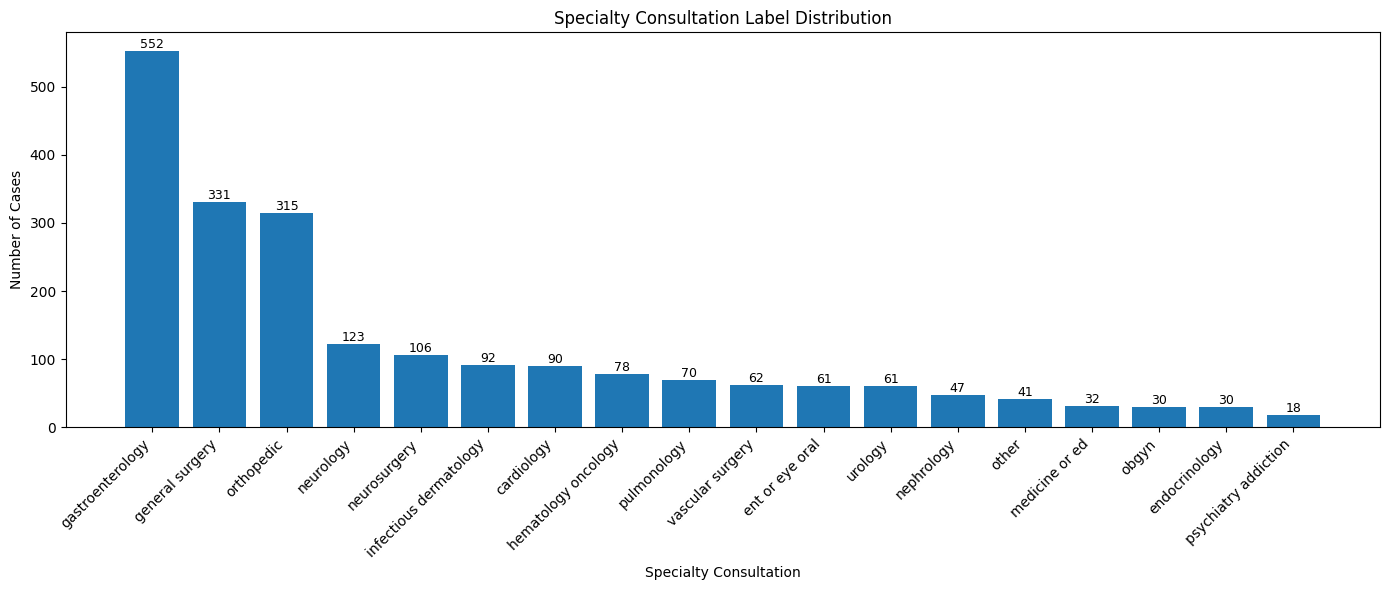

In [ ]:
# ============================================================
# Plot specialty_consult_label distribution with counts on bars
# ============================================================

import matplotlib.pyplot as plt

# Count labels
label_counts = prototype_df["specialty_consult_label"].value_counts()

# Short labels for cleaner plot
short_labels = (
    label_counts.index
    .str.replace("_consult", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Create plot
plt.figure(figsize=(14, 6))

bars = plt.bar(short_labels, label_counts.values)

# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Specialty Consultation Label Distribution")
plt.xlabel("Specialty Consultation")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**specialty_consult_multi_labels**

In [ ]:
# ============================================================
# Create multi-label specialty consult target
# ============================================================

def create_specialty_consult_multi_labels(specialty_list):
    """
    Convert all specialties in specialty_clean_list into grouped consult labels.

    Multi-label:
    One case can have more than one specialty consult label.

    Logic:
    1. Map all specialties into broader consult labels.
    2. Remove duplicate labels while preserving order.
    3. If specific labels exist, remove generic labels:
       - other_consult
       - medicine_or_ed_consult
    """

    if not isinstance(specialty_list, list) or len(specialty_list) == 0:
        return ["other_consult"]

    labels = []

    for specialty in specialty_list:
        mapped_label = map_specialty_to_consult_group(specialty)
        labels.append(mapped_label)

    # Remove duplicates while preserving order
    labels = list(dict.fromkeys(labels))

    # Remove generic labels if more specific labels exist
    generic_labels = [
        "other_consult",
        "medicine_or_ed_consult"
    ]

    specific_labels = [
        label for label in labels
        if label not in generic_labels
    ]

    if len(specific_labels) > 0:
        labels = specific_labels

    if len(labels) == 0:
        labels = ["other_consult"]

    return labels


prototype_df["specialty_consult_multi_labels"] = prototype_df[
    "specialty_clean_list"
].apply(create_specialty_consult_multi_labels)

print("Examples:")
display(prototype_df[[
    "specialty_clean_list",
    "specialty_consult_label",
    "specialty_consult_multi_labels",
    "diagnosis_clean"
]].head(20))

Examples:


,specialty_clean_list,specialty_consult_label,specialty_consult_multi_labels,diagnosis_clean
0,"[neurology, pulmonology]",neurology_consult,"[neurology_consult, pulmonology_consult]",primary diagnoses: altered mental status hypoxia secondary diagnoses: clostridium difficule
1,[gastroenterology],gastroenterology_consult,[gastroenterology_consult],perforated duodenal ulcer
2,[vascular surgery],vascular_surgery_consult,[vascular_surgery_consult],peripheral arterial disease right posterior tibial deep vein thrombosis
3,[neurosurgery],neurosurgery_consult,[neurosurgery_consult],lumbar stenosis l2-5
4,"[addiction medicine, gastroenterology, hematology, psychiatry, infectious disease]",psychiatry_addiction_consult,"[psychiatry_addiction_consult, gastroenterology_consult, hematology_oncology_consult, infectious_dermatology_consult]",alcohol withdrawal pancreatitis thrombocytopenia schizoaffective hiv
5,[gastroenterology],gastroenterology_consult,[gastroenterology_consult],abdominal pain
6,"[ophthalmology, hematology]",ent_or_eye_oral_consult,"[ent_or_eye_oral_consult, hematology_oncology_consult]",left facial/pre-septal cellulitis supratherapeutic inr
7,[orthopedics],orthopedic_consult,[orthopedic_consult],left distal tibia/fibula fracture
8,"[orthopedics, emergency medicine, neurosurgery]",orthopedic_consult,"[orthopedic_consult, neurosurgery_consult]",s/p fall injuries: - c2 body fracture - t3 transverse process fracture - left distal clavicle fracture - right first rib fracture - left second rib fracture
9,"[nephrology, infectious disease]",nephrology_consult,"[nephrology_consult, infectious_dermatology_consult]",primary esrd with hd initiation necrotizing fasciitis with osteomyelitis secondary t2dm htn anemia hld


In [ ]:
# ============================================================
# Inspect multi-label specialty consult distribution
# ============================================================

from collections import Counter

multilabel_counter = Counter()

for labels in prototype_df["specialty_consult_multi_labels"]:
    for label in labels:
        multilabel_counter[label] += 1

print("Number of unique multi-label consult labels:", len(multilabel_counter))

print("\nMulti-label specialty consult distribution:")
print("=" * 80)

for label, count in multilabel_counter.most_common():
    print(label, ":", count)


prototype_df["num_specialty_consult_labels"] = prototype_df[
    "specialty_consult_multi_labels"
].apply(len)

print("\nNumber of labels per case:")
print(prototype_df["num_specialty_consult_labels"].value_counts().sort_index())

percentage_multilabel = (
    (prototype_df["num_specialty_consult_labels"] > 1).mean() * 100
)

print("\nPercentage of cases with more than one label:")
print(round(percentage_multilabel, 2), "%")

Number of unique multi-label consult labels: 18

Multi-label specialty consult distribution:
gastroenterology_consult : 631
orthopedic_consult : 372
general_surgery_consult : 356
neurology_consult : 188
hematology_oncology_consult : 165
cardiology_consult : 163
neurosurgery_consult : 127
pulmonology_consult : 124
infectious_dermatology_consult : 120
urology_consult : 119
nephrology_consult : 102
endocrinology_consult : 97
vascular_surgery_consult : 87
ent_or_eye_oral_consult : 83
psychiatry_addiction_consult : 59
other_consult : 42
obgyn_consult : 38
medicine_or_ed_consult : 32

Number of labels per case:
num_specialty_consult_labels
1    1633
2     332
3     113
4      39
5      19
6       3
Name: count, dtype: int64

Percentage of cases with more than one label:
23.66 %


### Manual Label Validation

In [ ]:
# ============================================================
# Manual inspection - selected specialty consult labels
# ============================================================

labels_to_review = [
    "other_consult",
    "medicine_or_ed_consult",
    "psychiatry_addiction_consult",
    "endocrinology_consult",
    "infectious_dermatology_consult",
    "obgyn_consult"
]

for target_label in labels_to_review:

    label_cases_df = prototype_df[
        prototype_df["specialty_consult_label"] == target_label
    ].copy()

    print("\n" + "#" * 140)
    print("SPECIALTY CONSULT LABEL:", target_label)
    print("Number of source cases:", label_cases_df.shape[0])
    print("#" * 140)

    for _, row in label_cases_df.head(10).iterrows():

        print("\n" + "=" * 120)
        print("SOURCE CASE ID:", row["stay_id"])

        print("\nSpecialty clean list:")
        print(row["specialty_clean_list"])

        print("\nSpecialty consult label:")
        print(row["specialty_consult_label"])

        print("\nMulti-label specialty consult labels:")
        print(row["specialty_consult_multi_labels"])

        print("\nDiagnosis:")
        print(row["diagnosis_clean"])

        print("\nHPI:")
        print(str(row["HPI"])[:1200])


############################################################################################################################################
SPECIALTY CONSULT LABEL: other_consult
Number of source cases: 41
############################################################################################################################################

SOURCE CASE ID: 36945261

Specialty clean list:
['rheumatology']

Specialty consult label:
other_consult

Multi-label specialty consult labels:
['other_consult']

Diagnosis:
primary: 1) acute gouty arthritis secondary: 1) hypertension 2) obesity

HPI:
Mr. ___ is a ___ man, transferred from ___ with atraumatic left elbow pain for 2 days and fever to T101
on day prior to presentation. He had pain with movement of left
elbow. Two days ago, he also had some pain in his left Achilles
tendon, but states now resolved. He presented to ___ and
arthrocentesis showed 95,000 WBC. He was started on vancomycin.
Gram stain at ___ showed polys without organi

# Final Labeled Dataset

In [ ]:
# ============================================================
# Check final label columns before generation
# ============================================================

needed_cols = [
    "stay_id",
    "HPI",
    "patient_info",
    "initial_vitals",
    "triage",
    "diagnosis_clean",
    "arrival_destination",
    "arrival_destination_reason",
    "specialty_consult_label",
    "specialty_consult_multi_labels"
]

for col in needed_cols:
    print(col, "exists:", col in labeled_df.columns)

print("\nShape:")
print(labeled_df.shape)

print("\nArrival destination distribution:")
print(labeled_df["arrival_destination"].value_counts())

print("\nSpecialty consult label distribution:")
print(labeled_df["specialty_consult_label"].value_counts())

stay_id exists: True
HPI exists: True
patient_info exists: True
initial_vitals exists: True
triage exists: True
diagnosis_clean exists: True
arrival_destination exists: True
arrival_destination_reason exists: True
specialty_consult_label exists: True
specialty_consult_multi_labels exists: True

Shape:
(2139, 26)

Arrival destination distribution:
arrival_destination
standard_ed_bed           1054
monitored_bed              869
resuscitation_bay          145
isolation_room              48
triage_or_waiting_room      17
trauma_bay                   6
Name: count, dtype: int64

Specialty consult label distribution:
specialty_consult_label
gastroenterology_consult          552
general_surgery_consult           331
orthopedic_consult                315
neurology_consult                 123
neurosurgery_consult              106
infectious_dermatology_consult     92
cardiology_consult                 90
hematology_oncology_consult        78
pulmonology_consult                70
vascular_surge

In [ ]:
# ============================================================
# Create and save final labeled dataset
# Includes:
# 1. arrival_destination
# 2. specialty_consult_label
# 3. specialty_consult_multi_labels
# ============================================================

from google.colab import drive
import os

drive.mount('/content/drive')

labeled_df = prototype_df.copy()

print("labeled_df shape:", labeled_df.shape)

print("\nSelected label columns:")
print([
    "arrival_destination",
    "arrival_destination_reason",
    "specialty_consult_label",
    "specialty_consult_multi_labels"
])

print("\nAll columns:")
print(labeled_df.columns.tolist())

output_path = "/content/drive/MyDrive/mimic_ext_labeled_cases_arrival_specialty_consult_v1.csv"

labeled_df.to_csv(
    output_path,
    index=False
)

print("\nSaved final labeled_df:")
print(output_path)

Mounted at /content/drive
labeled_df shape: (2139, 26)

Selected label columns:
['arrival_destination', 'arrival_destination_reason', 'specialty_consult_label', 'specialty_consult_multi_labels']

All columns:
['stay_id', 'HPI', 'patient_info', 'initial_vitals', 'triage', 'diagnosis', 'primary_diagnosis', 'secondary_diagnosis', 'specialty', 'specialty_clean_list', 'diagnosis_clean', 'primary_diagnosis_clean', 'secondary_diagnosis_clean', 'temperature', 'heart_rate', 'respiration_rate', 'oxygen_saturation', 'systolic_bp', 'diastolic_bp', 'systolic_bp_raw', 'diastolic_bp_raw', 'case_text_for_rules_clean', 'arrival_destination', 'arrival_destination_reason', 'specialty_consult_label', 'specialty_consult_multi_labels']

Saved final labeled_df:
/content/drive/MyDrive/mimic_ext_labeled_cases_arrival_specialty_consult_v1.csv


# Synthetic EMS Report Generation

Install and import OpenAI

In [ ]:
# ============================================================
# Tab 1 - Install and import OpenAI
# ============================================================

!pip install openai -q

import os
import json
import time
import pandas as pd
from getpass import getpass
from openai import OpenAI

In [ ]:
# ============================================================
# Tab 2 - Set OpenAI API key
# ============================================================

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

client = OpenAI()

print("OpenAI client is ready.")

Enter your OpenAI API key: ··········
OpenAI client is ready.


In [ ]:
# ============================================================
# Tab 3 - Load final labeled dataset from Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

labeled_df = pd.read_csv(
    "/content/drive/MyDrive/mimic_ext_labeled_cases_arrival_specialty_consult_v1.csv"
)

print("labeled_df shape:", labeled_df.shape)
print(labeled_df.columns.tolist())

Mounted at /content/drive
labeled_df shape: (2139, 27)
['stay_id', 'HPI', 'patient_info', 'initial_vitals', 'triage', 'diagnosis', 'primary_diagnosis', 'secondary_diagnosis', 'specialty', 'specialty_clean_list', 'diagnosis_clean', 'primary_diagnosis_clean', 'secondary_diagnosis_clean', 'temperature', 'heart_rate', 'respiration_rate', 'oxygen_saturation', 'systolic_bp', 'diastolic_bp', 'systolic_bp_raw', 'diastolic_bp_raw', 'case_text_for_rules_clean', 'arrival_destination', 'arrival_destination_reason', 'specialty_consult_label', 'specialty_consult_multi_labels', 'num_specialty_consult_labels']


In [ ]:
# ============================================================
# Tab 4 - Convert list-like columns back to Python lists
# ============================================================

import ast
import pandas as pd

def parse_list_column(value):
    """
    Convert a string representation of a list back into a Python list.
    If the value is already a list, keep it as is.
    """
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return parsed

        return [parsed]

    except Exception:
        return [str(value)]


list_columns = [
    "specialty_clean_list",
    "specialty_consult_multi_labels"
]

for col in list_columns:
    if col in labeled_df.columns:
        labeled_df[col] = labeled_df[col].apply(parse_list_column)
        print(col, "converted to list.")
    else:
        print(col, "does not exist in labeled_df.")

print("\nFinished converting list-like columns.")

display(labeled_df[list_columns].head())

specialty_clean_list converted to list.
specialty_consult_multi_labels converted to list.

Finished converting list-like columns.


,specialty_clean_list,specialty_consult_multi_labels
0,"[neurology, pulmonology]","[neurology_consult, pulmonology_consult]"
1,[gastroenterology],[gastroenterology_consult]
2,[vascular surgery],[vascular_surgery_consult]
3,[neurosurgery],[neurosurgery_consult]
4,"[addiction medicine, gastroenterology, hematol...","[psychiatry_addiction_consult, gastroenterolog..."


In [ ]:
# ============================================================
# Tab 5 - Helper function for JSON-safe values
# ============================================================

import numpy as np
import pandas as pd

def safe_value(value):
    """
    Convert pandas/numpy values into JSON-safe Python values.

    This prevents errors such as:
    TypeError: Object of type int64 is not JSON serializable

    The function also handles lists and dictionaries safely.
    """

    # Keep lists, but clean each item inside the list
    if isinstance(value, list):
        return [safe_value(item) for item in value]

    # Keep dictionaries, but clean each value inside the dictionary
    if isinstance(value, dict):
        return {
            key: safe_value(val)
            for key, val in value.items()
        }

    # Handle missing values
    if pd.isna(value):
        return None

    # Convert numpy integers to regular Python int
    if isinstance(value, np.integer):
        return int(value)

    # Convert numpy floats to regular Python float
    if isinstance(value, np.floating):
        return float(value)

    # Convert numpy booleans to regular Python bool
    if isinstance(value, np.bool_):
        return bool(value)

    # Keep normal Python values as they are
    return value

Build case_seed without labels

In [ ]:
# ============================================================
# Tab 6 - Build clinical case seed without target labels, diagnosis, or triage
# ============================================================

def build_case_seed(row):
    """
    Build a structured clinical seed from one labeled_df row.

    The seed contains only clinical source facts that can reasonably
    appear in an EMS handoff report.

    Important:
    The seed does NOT include target labels or label-derived fields, such as:
    - arrival_destination
    - arrival_destination_reason
    - specialty
    - specialty_clean_list
    - specialty_consult_label
    - specialty_consult_multi_labels

    It also does NOT include diagnosis fields, because the specialty_referral
    in the original dataset was generated from diagnosis. Removing diagnosis
    reduces leakage risk for the specialty consult prediction task.

    It also does NOT include triage/acuity, because arrival_destination was
    partly derived from triage. Removing triage reduces leakage risk for the
    arrival destination prediction task.

    The HPI is used as the clinical narrative source for generation.
    """

    case_seed = {
        "source_case_id": safe_value(row.get("stay_id")),

        # Basic patient context
        "patient_info": safe_value(row.get("patient_info")),

        # Original clinical narrative
        "hpi": safe_value(row.get("HPI")),

        # Initial vitals as raw text
        "initial_vitals_raw": safe_value(row.get("initial_vitals")),

        # Initial vitals as structured values
        "vitals": {
            "temperature": safe_value(row.get("temperature")),
            "heart_rate": safe_value(row.get("heart_rate")),
            "respiration_rate": safe_value(row.get("respiration_rate")),
            "oxygen_saturation": safe_value(row.get("oxygen_saturation")),
            "systolic_bp": safe_value(row.get("systolic_bp")),
            "diastolic_bp": safe_value(row.get("diastolic_bp"))
        }
    }

    return case_seed

In [ ]:
# ============================================================
# Test one case seed and check for leakage
# ============================================================

sample_seed = build_case_seed(labeled_df.iloc[0])

print(json.dumps(sample_seed, ensure_ascii=False, indent=2))

{
  "source_case_id": 32822973,
  "patient_info": "Gender: Female, Race: WHITE, Age: 80",
  "hpi": "Patient is an ___ year-old patient with history of Sjogren's\nsyndrome, moderate MR, recent hospitalization for sepsis\nsecondary to c. diff colitis complicated by hypercarbic\nrespiratory failure requiring intubation, who is presenting from\n___ with worsening dyspnea for one day.  Patient was\ndischarged from ___ yesterday (___) following hospitalization\nfor c. diff colitis.  Patient had ABG at ___, which was\n7.___.  Her vitals on transfer were 97.9 99 24 113/68 92%\n2L. She reports shortness of breath associated with the cough.\nShe denies chest pain. She denies nausea or vomiting. She denies\nabdominal pain.\n\n",
  "initial_vitals_raw": "Temperature: 100.2, Heartrate: 95.0, resprate: 28.0, o2sat: 100.0, sbp: 99.0, dbp: 47.0",
  "vitals": {
    "temperature": 100.2,
    "heart_rate": 95.0,
    "respiration_rate": 28.0,
    "oxygen_saturation": 100.0,
    "systolic_bp": 99.0,
    "d

## Prompt Design and Generation Testing

In [ ]:
# ============================================================
#  Create prompt for EMS report generation with variants
# ============================================================

def make_ems_prompt(case_seed, text_variant):
    """
    Create an EMS-oriented prompt for OpenAI text generation.
    The prompt receives clinical source facts only, not target labels.
    The variant controls the writing style.
    """

    variant_instructions = {
        "professional_complete": """
Write a clean, professional EMS pre-arrival report.
Use complete sentences.
Include age/sex, main complaint, relevant history, current vitals, key positives, key negatives, and current status.
Keep it concise and EMS-oriented, not like a hospital summary.
Target length: 55-85 words.
""",

"brief_radio_missing_details": """
Write a brief EMS radio-style report.
Use concise prehospital wording and short practical phrasing.
Do not include every detail.
Mention only 2-3 key vitals total. Do not list the full vital sign set.
Prefer the most clinically relevant abnormal or reassuring vitals.
Do not include temperature, heart rate, respiratory rate, blood pressure, and oxygen saturation all together.
Focus on the main complaint, immediate clinical concern, and current stability.
Target length: 35-50 words.
""",

        "patient_reported_uncertain": """
Write an EMS report that sounds based mainly on the patient's reported symptoms.
Use cautious wording such as "reports", "states", "complains of", "unclear", "possible", or "concern for" when appropriate.
Do not make the report too polished or too definitive.
Use less formal medical wording when describing patient-reported symptoms. Do not overuse formal chronic disease names unless they are clearly important.
Still include key vitals and safety-relevant negatives if available.
Target length: 45-70 words.
""",

        "distracted_or_disorganized_handoff": """
Write a realistic EMS handoff that is understandable but less perfectly organized.
Use natural spoken EMS-style phrasing.
The speaker may mention details out of order, restart a sentence, repeat one minor point, or add one brief relevant background detail from the case.
You may start with the most urgent current finding, the main complaint, or the vital sign concern, instead of always starting with age and history.
The report should feel like a real-time handoff from a busy crew, not a polished written summary.
Do not make it chaotic, nonsensical, or unsafe.
Do not create ASR noise, transcription errors, misspellings, or random words.
Preserve the important warning signs, current symptoms, and current status.
Mention only the most relevant vitals, not necessarily the full vital sign set.
Target length: 55-85 words.
"""
    }

    if text_variant not in variant_instructions:
        raise ValueError(f"Unknown text_variant: {text_variant}")

    selected_variant_instruction = variant_instructions[text_variant]

    prompt = f"""
You are generating a synthetic ambulance pre-arrival report to the emergency department.

Use the clinical facts below, but write the report as a realistic EMS radio or phone handoff.
The report should sound like a pre-arrival update from EMS, not a hospital discharge summary.

Text variant:
{text_variant}

Variant-specific instruction:
{selected_variant_instruction}

General rules:
- Do not mention target labels, label names, dataset columns, rules, or classification categories.
- Do not mention ED destination categories such as standard bed, monitored bed, resuscitation bay, trauma bay, isolation room, or waiting room.
- Do not mention triage level, acuity level, or phrases such as "triage 1", "triage 2", "acuity 2", etc.
- Do not mention specialty names, consult groups, hospital services, departments, or specialist-directed evaluation.
- Avoid specialty-service wording such as "neurosurgical evaluation", "orthopedic evaluation", "surgical evaluation", "GI evaluation", "cardiology consult", "neurology evaluation", or "OB/GYN team". Clinical symptom words are allowed when needed.
- If the source mentions transfer or evaluation, rewrite it as a neutral EMS handoff focused on symptoms, current findings, and stability, not on the receiving service.
- Do not write "transferred for", "en route for evaluation", "for further evaluation", or "for management". Use neutral EMS phrasing such as "bringing in a patient with..." or "transporting a patient with...".
- Do not mention diagnosis fields or write the report as a final diagnosis list.
- Do not make every report sound like a final diagnosis. Prefer symptom-based or prehospital-impression wording.
- Do not mention race or ethnicity, even if included in the source facts.
- Do not invent contradictory facts.
- Do not invent treatments, procedures, exact times, or ETA unless explicitly present in the clinical facts.
- Never include ETA unless ETA is explicitly present in the clinical facts.
- Do not write a full hospital summary.
- Do not mention specific imaging or lab results such as CT, MRI, X-ray, ABG, WBC, troponin, or other test values. If such information appears in the source, translate it into an EMS-style clinical concern or observation, such as "possible head injury", "concerning neurologic finding", "infection concern", or "breathing concern", without naming the test result.
- Translate complex hospital diagnoses into simpler EMS-style language when possible. For example, instead of "hypercarbic respiratory failure", write "recent severe breathing problem" or "history of needing a breathing tube", while preserving the clinical meaning.
- If prior testing, imaging, or treatment appears in the source, mention it only briefly and only if the result is clearly available and clinically relevant.
- Do not mention masked, incomplete, or placeholder test results at all, including ABG, labs, imaging, or measurements with missing values.
- If a source value contains placeholders such as "___", "7.___", or an incomplete number, do not interpret it and do not convert it into a clinical conclusion.
- Do not infer severity from masked values. Use only clearly available clinical facts and complete vital signs.
- Do not change oxygen delivery details. If the source says the patient is on oxygen, such as 2 liters or nasal cannula, do not rewrite it as room air.
- Do not convert, simplify, or reinterpret oxygen support. Preserve oxygen delivery exactly when mentioned.
- When reporting vital signs, you may use approximate or qualitative wording instead of exact values, as long as the clinical meaning is preserved.
- Examples: "BP around 100 systolic", "heart rate around 110", "tachypneic", "borderline low blood pressure", "oxygenating well on 2 liters".
- Keep clinical wording internally consistent: do not describe a normal vital sign as abnormal, and do not state that a symptom or finding is present and later deny it.

Important:
Keep clinically important signals that affect ED preparation, such as:
- respiratory symptoms, fever, cough, pneumonia-like symptoms, or infection concern
- trauma mechanism and major injury findings
- chest pain or cardiac concern
- focal neurologic symptoms
- severe pain, bleeding, hypotension, hypoxia, or altered mental status
- self-harm, overdose, agitation, unsafe behavior, or psychiatric safety concerns when present
- pregnancy-related symptoms only if clearly present in the source facts

Clinical facts:
{json.dumps(case_seed, ensure_ascii=False, indent=2)}

Write exactly one ambulance pre-arrival report.
Return only the report text, without explanations.
""".strip()

    return prompt

In [ ]:
# ============================================================
# - Generate one EMS report by variant
# ============================================================

def generate_ems_report(case_seed, text_variant, model="gpt-4.1-mini"):
    """
    Generate one EMS handoff report using OpenAI.
    The model generates text only, not labels.
    """

    response = client.responses.create(
        model=model,
        input=make_ems_prompt(case_seed, text_variant),
        temperature=0.8
    )

    return response.output_text.strip()

In [ ]:
# ============================================================
# Test all text variants on one case
# ============================================================

sample_seed = build_case_seed(labeled_df.iloc[0])

text_variants = [
    "professional_complete",
    "brief_radio_missing_details",
    "patient_reported_uncertain",
    "distracted_or_disorganized_handoff"
]

for variant in text_variants:
    print("\n" + "=" * 120)
    print("VARIANT:", variant)
    print("=" * 120)

    report = generate_ems_report(
        case_seed=sample_seed,
        text_variant=variant
    )

    print(report)

In [ ]:
# ============================================================
# Test generation on several different source cases
# ============================================================

sample_indices = [0, 10, 50, 100, 200]

text_variants = [
    "professional_complete",
    "brief_radio_missing_details",
    "patient_reported_uncertain",
    "distracted_or_disorganized_handoff"
]

for idx in sample_indices:
    row = labeled_df.iloc[idx]
    case_seed = build_case_seed(row)

    print("\n" + "#" * 140)
    print("SOURCE CASE ID:", row["stay_id"])
    print("Arrival destination label:", row["arrival_destination"])
    print("Specialty consult label:", row["specialty_consult_label"])
    print("#" * 140)

    for variant in text_variants:
        print("\n" + "=" * 120)
        print("VARIANT:", variant)
        print("=" * 120)

        report = generate_ems_report(
            case_seed=case_seed,
            text_variant=variant
        )

        print(report)

In [ ]:
# ============================================================
# Check that all required objects/functions exist before full generation
# ============================================================

required_names = [
    "labeled_df",
    "build_case_seed",
    "make_ems_prompt",
    "generate_ems_report",
    "client"
]

for name in required_names:
    print(name, "exists:", name in globals())

print("\nlabeled_df shape:")
print(labeled_df.shape)

needed_cols = [
    "stay_id",
    "arrival_destination",
    "specialty_consult_label",
    "specialty_consult_multi_labels"
]

print("\nColumns needed:")
for col in needed_cols:
    print(col, "exists:", col in labeled_df.columns)

labeled_df exists: True
build_case_seed exists: True
make_ems_prompt exists: True
generate_ems_report exists: True
client exists: True

labeled_df shape:
(2139, 27)

Columns needed:
stay_id exists: True
arrival_destination exists: True
specialty_consult_label exists: True
specialty_consult_multi_labels exists: True


# Full Synthetic Dataset Generation and Quality Checks

In [ ]:
# ============================================================
# Full generation: all source cases x 4 variants
# With checkpoint/resume directly in Google Drive
# ============================================================

import os
import json
import time
import pandas as pd

output_path = "/content/drive/MyDrive/generated_ems_reports_arrival_specialty_consult_v1.csv"

text_variants = [
    "professional_complete",
    "brief_radio_missing_details",
    "patient_reported_uncertain",
    "distracted_or_disorganized_handoff"
]

# ------------------------------------------------------------
# Load existing checkpoint if it exists
# ------------------------------------------------------------

if os.path.exists(output_path):
    generated_df = pd.read_csv(output_path)
    completed_ids = set(generated_df["generated_report_id"].astype(str))
    print("Existing output file found.")
    print("Already generated reports:", len(completed_ids))
else:
    generated_df = pd.DataFrame()
    completed_ids = set()
    print("No existing output file found.")
    print("Starting full generation from scratch.")

expected_total = len(labeled_df) * len(text_variants)

print("\nSource cases:", len(labeled_df))
print("Variants per case:", len(text_variants))
print("Expected total reports:", expected_total)
print("Already completed:", len(completed_ids))

# ------------------------------------------------------------
# Generate reports with resume support
# ------------------------------------------------------------

generated_count = len(completed_ids)

for _, row in labeled_df.iterrows():

    source_case_id = str(row["stay_id"])
    case_seed = build_case_seed(row)

    for text_variant in text_variants:

        generated_report_id = f"mimic_ext_cds_{source_case_id}_{text_variant}_v1"

        # Skip reports that already exist in the checkpoint
        if generated_report_id in completed_ids:
            continue

        try:
            report_text = generate_ems_report(
                case_seed=case_seed,
                text_variant=text_variant
            )

            output_row = {
                "generated_report_id": generated_report_id,
                "source_case_id": source_case_id,
                "text_variant": text_variant,
                "text": report_text,

                # Labels for modeling
                "arrival_destination": row["arrival_destination"],
                "specialty_consult_label": row["specialty_consult_label"],

                # Keep multi-label as JSON string for safe CSV saving
                "specialty_consult_multi_labels": json.dumps(
                    row["specialty_consult_multi_labels"],
                    ensure_ascii=False
                )
            }

            # Append one row to CSV immediately
            output_row_df = pd.DataFrame([output_row])

            output_row_df.to_csv(
                output_path,
                mode="a",
                index=False,
                header=not os.path.exists(output_path)
            )

            completed_ids.add(generated_report_id)
            generated_count += 1

            print(
                f"Generated and saved: {generated_report_id} "
                f"({generated_count}/{expected_total})"
            )

            # Small pause to reduce API pressure
            time.sleep(0.2)

        except Exception as e:
            print("\nError while generating:")
            print("source_case_id:", source_case_id)
            print("text_variant:", text_variant)
            print("error:", e)
            print("Stopping safely. You can rerun this cell later to resume.")
            raise

print("\nGeneration finished or safely stopped.")

# ------------------------------------------------------------
# Load and summarize final/current output
# ------------------------------------------------------------

generated_full_df = pd.read_csv(output_path)

print("\nCurrent generated file:")
print(output_path)

print("\nCurrent shape:")
print(generated_full_df.shape)

print("\nUnique source cases:")
print(generated_full_df["source_case_id"].nunique())

print("\nText variants:")
print(generated_full_df["text_variant"].value_counts())

print("\nArrival destination distribution:")
print(generated_full_df["arrival_destination"].value_counts())

print("\nSpecialty consult label distribution:")
print(generated_full_df["specialty_consult_label"].value_counts())

Streaming output truncated to the last 5000 lines.
Generated and saved: mimic_ext_cds_33003133_distracted_or_disorganized_handoff_v1 (3608/8556)
Generated and saved: mimic_ext_cds_31138594_professional_complete_v1 (3609/8556)
Generated and saved: mimic_ext_cds_31138594_brief_radio_missing_details_v1 (3610/8556)
Generated and saved: mimic_ext_cds_31138594_patient_reported_uncertain_v1 (3611/8556)
Generated and saved: mimic_ext_cds_31138594_distracted_or_disorganized_handoff_v1 (3612/8556)
Generated and saved: mimic_ext_cds_30827302_professional_complete_v1 (3613/8556)
Generated and saved: mimic_ext_cds_30827302_brief_radio_missing_details_v1 (3614/8556)
Generated and saved: mimic_ext_cds_30827302_patient_reported_uncertain_v1 (3615/8556)
Generated and saved: mimic_ext_cds_30827302_distracted_or_disorganized_handoff_v1 (3616/8556)
Generated and saved: mimic_ext_cds_34123186_professional_complete_v1 (3617/8556)
Generated and saved: mimic_ext_cds_34123186_brief_radio_missing_details_v1 (36

In [ ]:
import os
import pandas as pd

output_path = "/content/drive/MyDrive/generated_ems_reports_arrival_specialty_consult_v1.csv"

print("File exists:", os.path.exists(output_path))

if os.path.exists(output_path):
    generated_full_df = pd.read_csv(output_path)

    print("Shape:", generated_full_df.shape)
    print("Unique source cases:", generated_full_df["source_case_id"].nunique())

    print("\nText variants:")
    print(generated_full_df["text_variant"].value_counts())

    print("\nArrival destination distribution:")
    print(generated_full_df["arrival_destination"].value_counts())

    print("\nSpecialty consult label distribution:")
    print(generated_full_df["specialty_consult_label"].value_counts())
else:
    print("File was not found in Google Drive at this path.")

File exists: True
Shape: (8556, 7)
Unique source cases: 2139

Text variants:
text_variant
professional_complete                 2139
brief_radio_missing_details           2139
patient_reported_uncertain            2139
distracted_or_disorganized_handoff    2139
Name: count, dtype: int64

Arrival destination distribution:
arrival_destination
standard_ed_bed           4216
monitored_bed             3476
resuscitation_bay          580
isolation_room             192
triage_or_waiting_room      68
trauma_bay                  24
Name: count, dtype: int64

Specialty consult label distribution:
specialty_consult_label
gastroenterology_consult          2208
general_surgery_consult           1324
orthopedic_consult                1260
neurology_consult                  492
neurosurgery_consult               424
infectious_dermatology_consult     368
cardiology_consult                 360
hematology_oncology_consult        312
pulmonology_consult                280
vascular_surgery_consult       

In [ ]:
# ============================================================
# Print 2 text variants from the same source case with wrapped text
# ============================================================

import textwrap

# Pick one source case that has all 4 variants
variant_counts = generated_full_df.groupby("source_case_id")["text_variant"].nunique()
example_source_case_id = variant_counts[variant_counts == 4].index[0]

example_case = generated_full_df[
    generated_full_df["source_case_id"] == example_source_case_id
].copy()

selected_variants = [
    "professional_complete",
    "brief_radio_missing_details"
]

example_case_2_variants = example_case[
    example_case["text_variant"].isin(selected_variants)
].copy()

print("=" * 90)
print("Example: Same clinical case, different EMS report variants")
print("=" * 90)

print("\nSource case ID:", example_source_case_id)
print("Arrival destination:", example_case["arrival_destination"].iloc[0])
print("Specialty consult label:", example_case["specialty_consult_label"].iloc[0])

for _, row in example_case_2_variants.iterrows():
    print("\n" + "-" * 90)
    print("Text variant:", row["text_variant"])
    print("-" * 90)

    wrapped_text = textwrap.fill(
        str(row["text"]),
        width=95
    )

    print(wrapped_text)

Example: Same clinical case, different EMS report variants

Source case ID: 30001856
Arrival destination: standard_ed_bed
Specialty consult label: gastroenterology_consult

------------------------------------------------------------------------------------------
Text variant: professional_complete
------------------------------------------------------------------------------------------
We are en route with a 54-year-old male with a history of alcoholic cirrhosis and hepatitis C,
status post TIPS procedure, presenting with three weeks of worsening epigastric pain now
constant and radiating around his abdomen. He reports vomiting this morning, possibly with
blood, and subjective fever and chills earlier today. No chest pain or shortness of breath.
Vital signs are stable with a temperature of 99.1, heart rate 83, respiratory rate 16, oxygen
saturation 97%, and blood pressure 140/71. Patient remains awake and alert.

-----------------------------------------------------------------------

In [ ]:
# ============================================================
# Final sanity checks
# ============================================================

print("Shape:", generated_full_df.shape)

print("\nUnique generated_report_id:")
print(generated_full_df["generated_report_id"].nunique())

print("\nDuplicated generated_report_id:")
print(generated_full_df["generated_report_id"].duplicated().sum())

print("\nEmpty text rows:")
print((generated_full_df["text"].astype(str).str.strip() == "").sum())

print("\nMissing values:")
print(generated_full_df.isna().sum())

print("\nVariants per source case:")
variants_per_case = generated_full_df.groupby("source_case_id")["text_variant"].nunique()
print(variants_per_case.value_counts().sort_index())

print("\nCases without exactly 4 variants:")
print((variants_per_case != 4).sum())

Shape: (8556, 7)

Unique generated_report_id:
8556

Duplicated generated_report_id:
0

Empty text rows:
0

Missing values:
generated_report_id               0
source_case_id                    0
text_variant                      0
text                              0
arrival_destination               0
specialty_consult_label           0
specialty_consult_multi_labels    0
dtype: int64

Variants per source case:
text_variant
4    2139
Name: count, dtype: int64

Cases without exactly 4 variants:
0


In [ ]:
# ============================================================
# Text length checks by variant
# ============================================================

generated_full_df["word_count"] = generated_full_df["text"].astype(str).apply(
    lambda x: len(x.split())
)

length_summary = generated_full_df.groupby("text_variant")["word_count"].agg(
    ["count", "min", "mean", "median", "max"]
)

print(length_summary)

                                    count  min       mean  median  max
text_variant                                                          
brief_radio_missing_details          2139   25  38.316971    38.0   49
distracted_or_disorganized_handoff   2139   48  77.886863    77.0  118
patient_reported_uncertain           2139   48  64.921459    64.0   99
professional_complete                2139   54  78.736793    78.0  107


In [ ]:
# ============================================================
# Check for possible leakage / problematic terms
# ============================================================

problem_terms = [
    # Labels / ED destination
    "standard bed",
    "monitored bed",
    "resuscitation bay",
    "trauma bay",
    "isolation room",
    "waiting room",

    # Triage
    "triage",
    "acuity",

    # Specialty / consult / services
    "consult",
    "consulted",
    "consultation",
    "service",
    "department",
    "specialist",
    "specialty",
    "neurosurgical evaluation",
    "neurosurgical eval",
    "orthopedic evaluation",
    "surgical evaluation",
    "neurology evaluation",
    "cardiology evaluation",
    "gi evaluation",
    "ob/gyn evaluation",

    # Hospital workflow
    "for further evaluation",
    "for management",
    "transferred for",
    "en route for evaluation",

    # Lab / imaging issues
    "ct showed",
    "head ct showed",
    "mri showed",
    "x-ray showed",
    "xray showed",
    "abg showed",
    "acidemia",
    "acidosis",
    "troponin",
    "white blood cells",
    "wbc"
]

problem_rows = []

for term in problem_terms:
    mask = generated_full_df["text"].astype(str).str.lower().str.contains(term, regex=False)
    count = mask.sum()

    if count > 0:
        problem_rows.append({
            "term": term,
            "count": count
        })

problem_terms_df = pd.DataFrame(problem_rows).sort_values("count", ascending=False)

print(problem_terms_df)

                        term  count
11                 ct showed    115
8     for further evaluation    110
12            head ct showed     17
1                    consult     15
13                mri showed     14
7        surgical evaluation     12
16                  troponin     11
9            transferred for     10
2                  consulted      9
18                       wbc      8
15                  acidosis      6
14              x-ray showed      5
17         white blood cells      4
3                 specialist      3
10   en route for evaluation      2
5         neurosurgical eval      2
4   neurosurgical evaluation      2
6      orthopedic evaluation      2
0               waiting room      1


In [ ]:
# ============================================================
# Inspect readable examples for selected problematic terms
# ============================================================

problematic_terms_to_review = [
    "ct showed"
    "for further evaluation",
    "consult",
    "surgical evaluation",
    "waiting room",
    "acidosis",
    "wbc",
    "troponin",
    "X-ray",
    "mri showed",
    "neurosurgical evaluation",
    "orthopedic evaluation"


]

max_examples = 10


def print_problematic_term_examples(
    dataframe,
    term,
    max_examples=10
):
    """
    Print readable examples containing a selected problematic term.
    """

    examples = dataframe[
        dataframe["text"]
        .astype(str)
        .str.lower()
        .str.contains(
            term.lower(),
            regex=False
        )
    ].copy()

    print("\n" + "#" * 120)
    print("TERM:", term)
    print("Number of examples:", len(examples))
    print("#" * 120)

    if examples.empty:
        print("No matching examples were found.")
        return

    for _, row in examples.head(max_examples).iterrows():
        print("\n" + "=" * 120)
        print("Generated report ID:", row["generated_report_id"])
        print("Source case ID:", row["source_case_id"])
        print("Variant:", row["text_variant"])
        print("Arrival destination:", row["arrival_destination"])
        print(
            "Specialty consult label:",
            row["specialty_consult_label"]
        )

        print("\nText:")
        print(row["text"])
        print("=" * 120)


for term in problematic_terms_to_review:
    print_problematic_term_examples(
        dataframe=generated_full_df,
        term=term,
        max_examples=max_examples
    )

## post-processing V1

In [ ]:
# ============================================================
# More precise post-processing candidate detection
# ============================================================

import re

precise_problem_patterns = [
    # Imaging result wording
    r"\bct showed\b",
    r"\bhead ct showed\b",
    r"\bct shows\b",
    r"\bct revealed\b",
    r"\bct demonstrated\b",
    r"\bct confirmed\b",
    r"\bmri showed\b",
    r"\bmri shows\b",
    r"\bmri revealed\b",
    r"\bmri demonstrated\b",
    r"\bmri confirmed\b",
    r"\bx[- ]?ray showed\b",
    r"\bx[- ]?ray confirmed\b",
    r"\bx[- ]?rays showed\b",
    r"\bx[- ]?rays confirmed\b",
    r"\bimaging showed\b",
    r"\bscan showed\b",

    # Lab result wording
    r"\btroponin\b",
    r"\bwbc\b",
    r"\bwhite blood cells\b",
    r"\bwhite count\b",
    r"\blabs showed\b",
    r"\blab showed\b",

    # Consult / service / specialty wording
    r"\bconsult\b",
    r"\bconsulted\b",
    r"\bconsultation\b",
    r"\bconsult pending\b",
    r"\bneurosurgical evaluation\b",
    r"\bneurosurgical eval\b",
    r"\bsurgical evaluation\b",
    r"\borthopedic evaluation\b",
    r"\borthopedic care\b",
    r"\borthopedics already consulted\b",
    r"\borthopedics was consulted\b",
    r"\bvascular surgery was consulted\b",
    r"\bplastic surgery was consulted\b",
    r"\bsurgery was consulted\b",

    # Workflow wording
    r"\bfor further evaluation\b",
    r"\ben route for evaluation\b",
    r"\btransferred for\b",
    r"\bfor management\b"
]

def contains_precise_problem_pattern(text):
    text_lower = str(text).lower()

    for pattern in precise_problem_patterns:
        if re.search(pattern, text_lower):
            return True

    return False

generated_full_df["needs_postprocessing_precise"] = generated_full_df["text"].apply(
    contains_precise_problem_pattern
)

print("Total rows:", len(generated_full_df))
print("Rows needing precise post-processing:", generated_full_df["needs_postprocessing_precise"].sum())
print("Percentage:", round(generated_full_df["needs_postprocessing_precise"].mean() * 100, 2), "%")

Total rows: 8556
Rows needing precise post-processing: 461
Percentage: 5.39 %


In [ ]:
# ============================================================
# Inspect precise post-processing candidates
# ============================================================

postprocess_precise_df = generated_full_df[
    generated_full_df["needs_postprocessing_precise"]
].copy()

print("Post-processing candidates shape:", postprocess_precise_df.shape)

print("\nBy text variant:")
print(postprocess_precise_df["text_variant"].value_counts())

print("\nBy specialty label:")
print(postprocess_precise_df["specialty_consult_label"].value_counts())

print("\nBy arrival destination:")
print(postprocess_precise_df["arrival_destination"].value_counts())

Post-processing candidates shape: (461, 9)

By text variant:
text_variant
distracted_or_disorganized_handoff    207
brief_radio_missing_details           133
professional_complete                  84
patient_reported_uncertain             37
Name: count, dtype: int64

By specialty label:
specialty_consult_label
gastroenterology_consult          99
general_surgery_consult           75
orthopedic_consult                72
neurosurgery_consult              71
neurology_consult                 28
ent_or_eye_oral_consult           19
cardiology_consult                18
pulmonology_consult               15
vascular_surgery_consult          14
infectious_dermatology_consult    10
hematology_oncology_consult       10
urology_consult                    9
nephrology_consult                 7
other_consult                      5
obgyn_consult                      4
endocrinology_consult              3
psychiatry_addiction_consult       2
Name: count, dtype: int64

By arrival destination:
arrival

In [ ]:
# ============================================================
# Print readable sample of post-processing candidates
# ============================================================

sample_candidates = postprocess_precise_df.sample(
    min(20, len(postprocess_precise_df)),
    random_state=42
)

for _, row in sample_candidates.iterrows():
    print("\n" + "=" * 120)
    print("Generated report ID:", row["generated_report_id"])
    print("Source case ID:", row["source_case_id"])
    print("Variant:", row["text_variant"])
    print("Arrival destination:", row["arrival_destination"])
    print("Specialty consult label:", row["specialty_consult_label"])
    print("\nText:")
    print(row["text"])

In [ ]:
# ============================================================
# Save candidate list before post-processing
# ============================================================

candidate_path = "/content/drive/MyDrive/postprocessing_candidates_v1.csv"

postprocess_precise_df.to_csv(candidate_path, index=False)

print("Saved candidates:")
print(candidate_path)
print("Shape:", postprocess_precise_df.shape)

Saved candidates:
/content/drive/MyDrive/postprocessing_candidates_v1.csv
Shape: (461, 9)


In [ ]:
# ============================================================
# Prepare text_original and text_cleaned columns
# ============================================================

if "text_original" not in generated_full_df.columns:
    generated_full_df["text_original"] = generated_full_df["text"]

if "text_cleaned" not in generated_full_df.columns:
    generated_full_df["text_cleaned"] = generated_full_df["text"]

print("Columns ready.")
print(generated_full_df[["text", "text_original", "text_cleaned"]].head(1))

Columns ready.
                                                text  \
0  We are transporting an 80-year-old female with...   

                                       text_original  \
0  We are transporting an 80-year-old female with...   

                                        text_cleaned  
0  We are transporting an 80-year-old female with...  


In [ ]:
# ============================================================
# LLM post-processing function for one EMS report
# ============================================================

def make_postprocessing_prompt(report_text):
    """
    Create a prompt that asks the LLM to minimally clean one generated EMS report.
    """

    prompt = f"""
You are reviewing a synthetic EMS pre-arrival report.

Your task:
Edit the report only if it contains wording that sounds too hospital-based, too diagnostic, or leakage-prone.

Problematic wording includes:
- Specific imaging results, such as CT showed, MRI showed, X-ray showed, scan showed
- Specific lab/test results, such as troponin, WBC, white count, white blood cells, ABG, INR, hematocrit, hemoglobin, creatinine, lab values
- Specialist/service wording, such as consult, consulted, neurosurgical evaluation, surgical evaluation, orthopedic evaluation
- Hospital workflow wording, such as transferred for, for further evaluation, for management

Rules:
- Make the smallest possible edit.
- Preserve the main clinical meaning.
- Do not add new medical facts.
- Do not remove important symptoms, mechanism, vital signs, or current status.
- Do not mention target labels, specialties, consults, hospital services, imaging results, or lab values.
- Keep it as a realistic EMS handoff.
- Return only the cleaned report text. Do not explain the changes.
- Replace INR or coagulation lab values with general clinical wording. For example, "INR is elevated" or "INR of 3.0" can become "on blood thinners with increased bleeding risk", without mentioning the numeric value.

Original report:
{report_text}
""".strip()

    return prompt


def clean_report_with_llm(report_text, model="gpt-4.1-mini"):
    """
    Use the LLM to minimally clean one generated report.
    """

    response = client.responses.create(
        model=model,
        input=make_postprocessing_prompt(report_text),
        temperature=0.2
    )

    return response.output_text.strip()

In [ ]:
# ============================================================
# Run V1 LLM post-processing on all precise candidate rows
# With checkpoint/resume
# ============================================================

import os
import time
import pandas as pd

checkpoint_path = "/content/drive/MyDrive/postprocessing_v1_checkpoint.csv"

candidate_ids = set(postprocess_precise_df["generated_report_id"].astype(str))

print("Number of candidate rows:", len(candidate_ids))

# ------------------------------------------------------------
# Load existing checkpoint if available
# ------------------------------------------------------------

if os.path.exists(checkpoint_path):
    checkpoint_df = pd.read_csv(checkpoint_path)
    completed_ids = set(checkpoint_df["generated_report_id"].astype(str))

    print("Existing checkpoint found.")
    print("Already cleaned:", len(completed_ids))
else:
    checkpoint_df = pd.DataFrame()
    completed_ids = set()

    print("No checkpoint found.")
    print("Starting from scratch.")

# ------------------------------------------------------------
# Run cleaning only for candidates not yet completed
# ------------------------------------------------------------

for _, row in postprocess_precise_df.iterrows():

    report_id = str(row["generated_report_id"])

    if report_id in completed_ids:
        continue

    original_text = row["text"]

    try:
        cleaned_text = clean_report_with_llm(original_text)

        output_row = {
            "generated_report_id": report_id,
            "source_case_id": row["source_case_id"],
            "text_variant": row["text_variant"],
            "arrival_destination": row["arrival_destination"],
            "specialty_consult_label": row["specialty_consult_label"],
            "text_original": original_text,
            "text_cleaned": cleaned_text
        }

        output_row_df = pd.DataFrame([output_row])

        output_row_df.to_csv(
            checkpoint_path,
            mode="a",
            index=False,
            header=not os.path.exists(checkpoint_path)
        )

        completed_ids.add(report_id)

        print(f"Cleaned and saved: {report_id} ({len(completed_ids)}/{len(candidate_ids)})")

        time.sleep(0.2)

    except Exception as e:
        print("\nError during post-processing:")
        print("generated_report_id:", report_id)
        print("error:", e)
        print("Stopping safely. You can rerun this cell later to resume.")
        raise

print("\nPost-processing finished or safely stopped.")
print("Checkpoint saved to:")
print(checkpoint_path)

In [ ]:
# ============================================================
# Check post-processing checkpoint before merge
# ============================================================

checkpoint_df = pd.read_csv(checkpoint_path)

print("Checkpoint shape:", checkpoint_df.shape)
print("Unique cleaned IDs:", checkpoint_df["generated_report_id"].nunique())

print("\nExpected candidate rows:")
print(postprocess_precise_df["generated_report_id"].nunique())

print("\nDuplicated IDs in checkpoint:")
print(checkpoint_df["generated_report_id"].duplicated().sum())

In [ ]:
# ============================================================
# Merge V1 cleaned texts back into full dataset
# ============================================================

checkpoint_df = pd.read_csv(checkpoint_path)

print("Checkpoint shape:", checkpoint_df.shape)
print("Unique cleaned IDs:", checkpoint_df["generated_report_id"].nunique())

# Create mapping from report ID to cleaned text
cleaned_text_map = dict(
    zip(
        checkpoint_df["generated_report_id"].astype(str),
        checkpoint_df["text_cleaned"].astype(str)
    )
)

# Update only candidate rows that were cleaned
generated_full_df["generated_report_id"] = generated_full_df["generated_report_id"].astype(str)

generated_full_df["text_cleaned"] = generated_full_df.apply(
    lambda row: cleaned_text_map.get(row["generated_report_id"], row["text_cleaned"]),
    axis=1
)

print("Updated text_cleaned column.")

print("\nRows where text_cleaned differs from text_original:")
print((generated_full_df["text_cleaned"] != generated_full_df["text_original"]).sum())

Checkpoint shape: (461, 7)
Unique cleaned IDs: 461
Updated text_cleaned column.

Rows where text_cleaned differs from text_original:
460


In [ ]:
# ============================================================
# Save final cleaned dataset
# ============================================================

cleaned_path = "/content/drive/MyDrive/generated_ems_reports_arrival_specialty_consult_v1_cleaned.csv"

generated_full_df.to_csv(cleaned_path, index=False)

print("Saved cleaned dataset:")
print(cleaned_path)
print("Shape:", generated_full_df.shape)

In [ ]:
# ============================================================
# Print before/after examples from V1 post-processing checkpoint
# Wrapped text for readable screenshots
# ============================================================

import pandas as pd
import textwrap
import os

checkpoint_path = "/content/drive/MyDrive/postprocessing_v1_checkpoint.csv"

print("Checkpoint exists:", os.path.exists(checkpoint_path))

checkpoint_df = pd.read_csv(checkpoint_path)

print("Checkpoint shape:", checkpoint_df.shape)

sample_to_print = checkpoint_df.sample(
    n=min(5, len(checkpoint_df)),   # use 5 examples for easier screenshot
    random_state=42
)

for _, row in sample_to_print.iterrows():
    print("\n" + "=" * 100)
    print("Generated report ID:", row["generated_report_id"])
    print("Source case ID:", row["source_case_id"])
    print("Variant:", row["text_variant"])
    print("Arrival destination:", row["arrival_destination"])
    print("Specialty consult label:", row["specialty_consult_label"])

    print("\n--- ORIGINAL TEXT ---")
    print(textwrap.fill(str(row["text_original"]), width=90))

    print("\n--- CLEANED TEXT ---")
    print(textwrap.fill(str(row["text_cleaned"]), width=90))

Checkpoint exists: True
Checkpoint shape: (461, 7)

Generated report ID: mimic_ext_cds_30935092_brief_radio_missing_details_v1
Source case ID: 30935092
Variant: brief_radio_missing_details
Arrival destination: monitored_bed
Specialty consult label: general_surgery_consult

--- ORIGINAL TEXT ---
51-year-old male with history of esophageal cancer post-esophagectomy, presenting with 2
days of worsening crampy abdominal pain and bilious vomiting. CT shows small bowel
obstruction. Vitals stable with BP 102 systolic, O2 sat 95% on room air. Transporting now.

--- CLEANED TEXT ---
51-year-old male with history of esophageal cancer post-esophagectomy, presenting with 2
days of worsening crampy abdominal pain and bilious vomiting consistent with small bowel
obstruction. Vitals stable with BP 102 systolic, O2 sat 95% on room air. Transporting now.

Generated report ID: mimic_ext_cds_38621730_distracted_or_disorganized_handoff_v1
Source case ID: 38621730
Variant: distracted_or_disorganized_handof

In [ ]:
# ============================================================
# Check remaining problematic terms after V1 post-processing
# Using text_cleaned
# ============================================================



# Terms/patterns to check after cleaning
remaining_problem_patterns = [
    # Imaging/result wording
    r"\bct showed\b",
    r"\bct shows\b",
    r"\bhead ct showed\b",
    r"\bmri showed\b",
    r"\bmri shows\b",
    r"\bx[- ]?ray showed\b",
    r"\bx[- ]?rays showed\b",
    r"\bx[- ]?ray confirmed\b",
    r"\bx[- ]?rays confirmed\b",
    r"\bimaging showed\b",
    r"\bimaging shows\b",
    r"\bscan showed\b",
    r"\bscan shows\b",

    # Lab/result wording
    r"\btroponin\b",
    r"\bwbc\b",
    r"\bwhite blood cells\b",
    r"\bwhite count\b",
    r"\blabs showed\b",
    r"\blabs show\b",
    r"\blab showed\b",
    r"\blab shows\b",
    r"\binr\b",

    # Consult/service/specialty wording
    r"\bconsult\b",
    r"\bconsulted\b",
    r"\bconsultation\b",
    r"\bneurosurgical evaluation\b",
    r"\bneurosurgical eval\b",
    r"\bsurgical evaluation\b",
    r"\borthopedic evaluation\b",
    r"\borthopedic care\b",
    r"\borthopedics\b",
    r"\bvascular surgery\b",
    r"\bplastic surgery\b",

    # Workflow wording
    r"\bfor further evaluation\b",
    r"\ben route for evaluation\b",
    r"\btransferred for\b",
    r"\bfor management\b",

    # Things V1 sometimes creates
    r"\bimaging shows\b",
    r"\bexam shows dilated\b",
    r"\breports fluid\b"
]

problem_rows_after_cleaning = []

for pattern in remaining_problem_patterns:
    mask = generated_full_df["text_cleaned"].astype(str).str.lower().str.contains(
        pattern,
        regex=True
    )

    count = mask.sum()

    if count > 0:
        problem_rows_after_cleaning.append({
            "pattern": pattern,
            "count": count
        })

remaining_problem_df = pd.DataFrame(problem_rows_after_cleaning)

if remaining_problem_df.empty:
    print("No remaining problematic terms found.")
else:
    remaining_problem_df = remaining_problem_df.sort_values("count", ascending=False)
    print("Remaining problematic terms after cleaning:")
    print(remaining_problem_df)

Remaining problematic terms after cleaning:
                   pattern  count
7                  \binr\b     47
10       \bimaging shows\b     15
1        \bimaging shows\b     15
8          \borthopedics\b      6
9     \bvascular surgery\b      6
6            \blabs show\b      3
4          \bwhite count\b      3
3    \bwhite blood cells\b      3
12       \breports fluid\b      2
2          \bscan showed\b      1
0       \bimaging showed\b      1
5          \blabs showed\b      1
11  \bexam shows dilated\b      1


In [ ]:
# ============================================================
# Print readable examples for remaining problematic terms
# ============================================================

max_examples_per_pattern = 5

if remaining_problem_df.empty:
    print("No examples to inspect.")
else:
    for pattern in remaining_problem_df["pattern"].head(15):
        examples = generated_full_df[
            generated_full_df["text_cleaned"].astype(str).str.lower().str.contains(
                pattern,
                regex=True
            )
        ].copy()

        print("\n" + "#" * 140)
        print("PATTERN:", pattern)
        print("Number of examples:", examples.shape[0])
        print("#" * 140)

        for _, row in examples.head(max_examples_per_pattern).iterrows():
            print("\n" + "=" * 120)
            print("Generated report ID:", row["generated_report_id"])
            print("Source case ID:", row["source_case_id"])
            print("Variant:", row["text_variant"])
            print("Arrival destination:", row["arrival_destination"])
            print("Specialty consult label:", row["specialty_consult_label"])

            print("\n--- ORIGINAL TEXT ---")
            print(row["text_original"])

            print("\n--- CLEANED TEXT ---")
            print(row["text_cleaned"])


############################################################################################################################################
PATTERN: \binr\b
Number of examples: 47
############################################################################################################################################

Generated report ID: mimic_ext_cds_34441313_brief_radio_missing_details_v1
Source case ID: 34441313
Variant: brief_radio_missing_details
Arrival destination: monitored_bed
Specialty consult label: infectious_dermatology_consult

--- ORIGINAL TEXT ---
67-year-old male with cellulitis at recent fem-pop site, hypotensive with BP 90/45, oxygen saturation 90% on room air. No chest pain or respiratory distress. Treated prehospital for hyperkalemia and elevated INR. Stable mental status, en route now.

--- CLEANED TEXT ---
67-year-old male with cellulitis at recent fem-pop site, hypotensive with BP 90/45, oxygen saturation 90% on room air. No chest pain or respiratory distre

### Round 2 Post-Processing

In [ ]:
# ============================================================
# Identify unique rows that still need round 2 post-processing
# Based on text_cleaned after V1
# ============================================================

import re
import pandas as pd

# Patterns that still indicate problematic wording after V1
round2_problem_patterns = [
    # Imaging-result wording that remained
    r"\bct showed\b",
    r"\bct shows\b",
    r"\bhead ct showed\b",
    r"\bmri showed\b",
    r"\bmri shows\b",
    r"\bx[- ]?ray showed\b",
    r"\bx[- ]?rays showed\b",
    r"\bx[- ]?ray confirmed\b",
    r"\bx[- ]?rays confirmed\b",
    r"\bimaging showed\b",
    r"\bimaging shows\b",
    r"\bscan showed\b",
    r"\bscan shows\b",

    # Lab-result wording that remained
    r"\btroponin\b",
    r"\bwbc\b",
    r"\bwhite blood cells\b",
    r"\bwhite count\b",
    r"\blabs showed\b",
    r"\blabs show\b",
    r"\blab showed\b",
    r"\blab shows\b",
    r"\binr\b",
    r"\bhematocrit\b",
    r"\bhemoglobin\b",
    r"\bcreatinine\b",

    # Specialist/service wording that remained
    r"\bconsult\b",
    r"\bconsulted\b",
    r"\bconsultation\b",
    r"\bneurosurgical evaluation\b",
    r"\bneurosurgical eval\b",
    r"\bsurgical evaluation\b",
    r"\borthopedic evaluation\b",
    r"\borthopedic care\b",
    r"\borthopedics\b",
    r"\bvascular surgery\b",
    r"\bplastic surgery\b",

    # Workflow wording
    r"\bfor further evaluation\b",
    r"\ben route for evaluation\b",
    r"\btransferred for\b",
    r"\bfor management\b",

    # Strange replacements created by V1
    r"\breports fluid\b",
    r"\bexam shows dilated\b"
]


def find_matching_patterns(text, patterns):
    """
    Return a list of problematic regex patterns found in a given text.
    """
    text_lower = str(text).lower()

    found = []
    for pattern in patterns:
        if re.search(pattern, text_lower):
            found.append(pattern)

    return found


# Create a column with the list of remaining problematic patterns
generated_full_df["round2_problem_patterns"] = generated_full_df["text_cleaned"].apply(
    lambda x: find_matching_patterns(x, round2_problem_patterns)
)

# Mark rows that still need round 2
generated_full_df["needs_round2_postprocessing"] = generated_full_df["round2_problem_patterns"].apply(
    lambda x: len(x) > 0
)

round2_candidates_df = generated_full_df[
    generated_full_df["needs_round2_postprocessing"]
].copy()

print("Total rows:", len(generated_full_df))
print("Rows needing round 2 post-processing:", round2_candidates_df.shape[0])
print("Percentage:", round(round2_candidates_df.shape[0] / len(generated_full_df) * 100, 2), "%")

print("\nBy text variant:")
print(round2_candidates_df["text_variant"].value_counts())

print("\nBy specialty label:")
print(round2_candidates_df["specialty_consult_label"].value_counts())

print("\nBy arrival destination:")
print(round2_candidates_df["arrival_destination"].value_counts())

Total rows: 8556
Rows needing round 2 post-processing: 168
Percentage: 1.96 %

By text variant:
text_variant
distracted_or_disorganized_handoff    73
professional_complete                 49
brief_radio_missing_details           30
patient_reported_uncertain            16
Name: count, dtype: int64

By specialty label:
specialty_consult_label
gastroenterology_consult          53
hematology_oncology_consult       27
orthopedic_consult                22
general_surgery_consult           15
neurosurgery_consult              13
urology_consult                    7
vascular_surgery_consult           6
nephrology_consult                 5
pulmonology_consult                5
infectious_dermatology_consult     4
other_consult                      3
medicine_or_ed_consult             2
neurology_consult                  2
ent_or_eye_oral_consult            2
cardiology_consult                 2
Name: count, dtype: int64

By arrival destination:
arrival_destination
monitored_bed        119
stand

In [ ]:
# ============================================================
# Print readable examples of round 2 candidates
# ============================================================

sample_round2 = round2_candidates_df.sample(
    n=min(15, len(round2_candidates_df)),
    random_state=42
)

for _, row in sample_round2.iterrows():
    print("\n" + "=" * 140)
    print("Generated report ID:", row["generated_report_id"])
    print("Source case ID:", row["source_case_id"])
    print("Variant:", row["text_variant"])
    print("Arrival destination:", row["arrival_destination"])
    print("Specialty consult label:", row["specialty_consult_label"])
    print("Problem patterns:", row["round2_problem_patterns"])

    print("\n--- ORIGINAL TEXT ---")
    print(row["text_original"])

    print("\n--- CLEANED TEXT AFTER V1 ---")
    print(row["text_cleaned"])


Generated report ID: mimic_ext_cds_36468731_distracted_or_disorganized_handoff_v1
Source case ID: 36468731
Variant: distracted_or_disorganized_handoff
Arrival destination: monitored_bed
Specialty consult label: nephrology_consult
Problem patterns: ['\\binr\\b']

--- ORIGINAL TEXT ---
45-year-old male with history of high blood pressure, high cholesterol, and mechanical aortic valve on aspirin and warfarin. He had right renal infarct diagnosed after severe back pain, nausea, and vomiting. Was started on heparin drip here after a subtherapeutic INR. Pain improved now. Vitals stable, BP elevated around 170s systolic, HR 80s, sats 97% on room air, no respiratory distress. Left AMA earlier but returned for care. No active complaints currently.

--- CLEANED TEXT AFTER V1 ---
45-year-old male with history of high blood pressure, high cholesterol, and mechanical aortic valve on aspirin and warfarin. He had right renal infarct diagnosed after severe back pain, nausea, and vomiting. Was started

In [ ]:
# ============================================================
# LLM post-processing function for remaining problematic reports - Round 2
# ============================================================

def make_postprocessing_prompt_round2(report_text):
    """
    Create a stricter prompt for a second post-processing round.
    This round targets remaining lab, imaging, and service wording after V1.
    """

    prompt = f"""
You are reviewing a synthetic EMS pre-arrival report that was already post-processed once.

Your task:
Make a minimal second-pass edit only if the report still contains hospital-style,
diagnostic, lab-result, imaging-result, or service/specialty wording.

Remaining problematic wording includes:
- Imaging-result wording, such as "imaging shows", "imaging showed", "scan showed", "CT showed", "MRI showed", "X-ray showed"
- Specific lab/test results, such as INR, hematocrit, hemoglobin, creatinine, WBC, white count, white blood cells, troponin, ABG, or numeric lab values
- Specialist/service wording, such as orthopedics, vascular surgery, plastic surgery, consult, consulted, surgical evaluation, orthopedic evaluation, neurosurgical evaluation
- Unnatural replacements for test findings, such as "reports fluid" or "exam shows dilated bowel loops"

Rules:
- Make the smallest possible edit.
- Preserve the main clinical meaning.
- Do not add new medical facts.
- Do not remove important symptoms, mechanism, vital signs, or current status.
- Do not mention target labels, specialties, consults, hospital services, imaging results, or lab values.
- Keep it as a realistic EMS handoff.
- Replace INR or coagulation lab values with general clinical wording, such as "on blood thinners with increased bleeding risk", without mentioning the numeric value.
- Replace hematocrit or hemoglobin values with general clinical wording, such as "concern for significant anemia" or "concern for blood loss", without mentioning the numeric value.
- Replace creatinine or kidney lab values with general clinical wording, such as "kidney function concern", without mentioning the numeric value.
- Do not write "imaging shows" or "imaging showed". Remove the imaging-result wording or rewrite it using already-mentioned symptoms/mechanism.
- Do not write "reports" for imaging or lab findings unless the patient could realistically report it as a symptom.
- Remove or rewrite specialty/service wording such as "orthopedics", "vascular surgery", or "plastic surgery" when it refers to service involvement.
- Return only the cleaned report text. Do not explain the changes.

Original report:
{report_text}
""".strip()

    return prompt


def clean_report_with_llm_round2(report_text, model="gpt-4.1-mini"):
    """
    Use the LLM to clean remaining problematic wording after V1.
    """

    response = client.responses.create(
        model=model,
        input=make_postprocessing_prompt_round2(report_text),
        temperature=0.2
    )

    return response.output_text.strip()

In [ ]:
# ============================================================
# Run Round 2 LLM post-processing on remaining problematic rows
# With checkpoint/resume
# ============================================================

import os
import time
import pandas as pd

round2_checkpoint_path = "/content/drive/MyDrive/postprocessing_round2_checkpoint.csv"

candidate_ids_round2 = set(round2_candidates_df["generated_report_id"].astype(str))

print("Number of round 2 candidate rows:", len(candidate_ids_round2))

# ------------------------------------------------------------
# Load existing checkpoint if available
# ------------------------------------------------------------

if os.path.exists(round2_checkpoint_path):
    round2_checkpoint_df = pd.read_csv(round2_checkpoint_path)
    completed_ids_round2 = set(round2_checkpoint_df["generated_report_id"].astype(str))

    print("Existing Round 2 checkpoint found.")
    print("Already cleaned in Round 2:", len(completed_ids_round2))
else:
    round2_checkpoint_df = pd.DataFrame()
    completed_ids_round2 = set()

    print("No Round 2 checkpoint found.")
    print("Starting Round 2 from scratch.")

# ------------------------------------------------------------
# Run cleaning only for candidates not yet completed
# ------------------------------------------------------------

for _, row in round2_candidates_df.iterrows():

    report_id = str(row["generated_report_id"])

    if report_id in completed_ids_round2:
        continue

    # Important: clean the V1-cleaned text, not the original text
    current_cleaned_text = row["text_cleaned"]

    try:
        cleaned_text_round2 = clean_report_with_llm_round2(current_cleaned_text)

        output_row = {
            "generated_report_id": report_id,
            "source_case_id": row["source_case_id"],
            "text_variant": row["text_variant"],
            "arrival_destination": row["arrival_destination"],
            "specialty_consult_label": row["specialty_consult_label"],
            "text_after_v1": current_cleaned_text,
            "text_cleaned_round2": cleaned_text_round2
        }

        output_row_df = pd.DataFrame([output_row])

        output_row_df.to_csv(
            round2_checkpoint_path,
            mode="a",
            index=False,
            header=not os.path.exists(round2_checkpoint_path)
        )

        completed_ids_round2.add(report_id)

        print(
            f"Round 2 cleaned and saved: {report_id} "
            f"({len(completed_ids_round2)}/{len(candidate_ids_round2)})"
        )

        time.sleep(0.2)

    except Exception as e:
        print("\nError during Round 2 post-processing:")
        print("generated_report_id:", report_id)
        print("error:", e)
        print("Stopping safely. You can rerun this cell later to resume.")
        raise

print("\nRound 2 post-processing finished or safely stopped.")
print("Round 2 checkpoint saved to:")
print(round2_checkpoint_path)

Number of round 2 candidate rows: 168
No Round 2 checkpoint found.
Starting Round 2 from scratch.
Round 2 cleaned and saved: mimic_ext_cds_33090111_brief_radio_missing_details_v1 (1/168)
Round 2 cleaned and saved: mimic_ext_cds_33090111_distracted_or_disorganized_handoff_v1 (2/168)
Round 2 cleaned and saved: mimic_ext_cds_36843688_distracted_or_disorganized_handoff_v1 (3/168)
Round 2 cleaned and saved: mimic_ext_cds_31118306_distracted_or_disorganized_handoff_v1 (4/168)
Round 2 cleaned and saved: mimic_ext_cds_38712053_distracted_or_disorganized_handoff_v1 (5/168)
Round 2 cleaned and saved: mimic_ext_cds_30145500_patient_reported_uncertain_v1 (6/168)
Round 2 cleaned and saved: mimic_ext_cds_38621730_distracted_or_disorganized_handoff_v1 (7/168)
Round 2 cleaned and saved: mimic_ext_cds_38813613_professional_complete_v1 (8/168)
Round 2 cleaned and saved: mimic_ext_cds_38705008_distracted_or_disorganized_handoff_v1 (9/168)
Round 2 cleaned and saved: mimic_ext_cds_34441313_brief_radio_miss

In [ ]:
# ============================================================
# Check Round 2 checkpoint before merge
# ============================================================

round2_checkpoint_df = pd.read_csv(round2_checkpoint_path)

print("Round 2 checkpoint shape:", round2_checkpoint_df.shape)
print("Unique cleaned IDs:", round2_checkpoint_df["generated_report_id"].nunique())

print("\nExpected Round 2 candidate rows:")
print(round2_candidates_df["generated_report_id"].nunique())

print("\nDuplicated IDs in Round 2 checkpoint:")
print(round2_checkpoint_df["generated_report_id"].duplicated().sum())

Round 2 checkpoint shape: (168, 7)
Unique cleaned IDs: 168

Expected Round 2 candidate rows:
168

Duplicated IDs in Round 2 checkpoint:
0


In [ ]:
# ============================================================
# Merge Round 2 cleaned texts back into full dataset
# ============================================================

round2_checkpoint_df = pd.read_csv(round2_checkpoint_path)

# Create mapping from report ID to Round 2 cleaned text
round2_cleaned_text_map = dict(
    zip(
        round2_checkpoint_df["generated_report_id"].astype(str),
        round2_checkpoint_df["text_cleaned_round2"].astype(str)
    )
)

generated_full_df["generated_report_id"] = generated_full_df["generated_report_id"].astype(str)

# Keep V1 cleaned text as backup before Round 2 overwrite
if "text_cleaned_v1" not in generated_full_df.columns:
    generated_full_df["text_cleaned_v1"] = generated_full_df["text_cleaned"]

# Update only rows that were cleaned in Round 2
generated_full_df["text_cleaned"] = generated_full_df.apply(
    lambda row: round2_cleaned_text_map.get(row["generated_report_id"], row["text_cleaned"]),
    axis=1
)

print("Updated text_cleaned with Round 2 results.")

print("\nRows changed by Round 2:")
print((generated_full_df["text_cleaned"] != generated_full_df["text_cleaned_v1"]).sum())

Updated text_cleaned with Round 2 results.

Rows changed by Round 2:
166


In [ ]:
# ============================================================
# Save final cleaned dataset after Round 2
# ============================================================

cleaned_round2_path = "/content/drive/MyDrive/generated_ems_reports_arrival_specialty_consult_v1_cleaned_round2.csv"

generated_full_df.to_csv(cleaned_round2_path, index=False)

print("Saved final cleaned dataset after Round 2:")
print(cleaned_round2_path)
print("Shape:", generated_full_df.shape)

Saved final cleaned dataset after Round 2:
/content/drive/MyDrive/generated_ems_reports_arrival_specialty_consult_v1_cleaned_round2.csv
Shape: (8556, 14)


In [ ]:
# ============================================================
# Inspect examples changed by Round 2
# ============================================================

round2_checkpoint_path = "/content/drive/MyDrive/postprocessing_round2_checkpoint.csv"
round2_checkpoint_df = pd.read_csv(round2_checkpoint_path)

print("Round 2 checkpoint shape:", round2_checkpoint_df.shape)

# Keep only rows where Round 2 actually changed the V1 text
changed_round2_df = round2_checkpoint_df[
    round2_checkpoint_df["text_after_v1"].astype(str) !=
    round2_checkpoint_df["text_cleaned_round2"].astype(str)
].copy()

print("Rows actually changed by Round 2:", changed_round2_df.shape[0])

sample_changed = changed_round2_df.sample(
    n=min(20, len(changed_round2_df)),
    random_state=42
)

for _, row in sample_changed.iterrows():
    print("\n" + "=" * 140)
    print("Generated report ID:", row["generated_report_id"])
    print("Source case ID:", row["source_case_id"])
    print("Variant:", row["text_variant"])
    print("Arrival destination:", row["arrival_destination"])
    print("Specialty consult label:", row["specialty_consult_label"])

    print("\n--- TEXT AFTER V1 ---")
    print(row["text_after_v1"])

    print("\n--- TEXT AFTER ROUND 2 ---")
    print(row["text_cleaned_round2"])

Round 2 checkpoint shape: (168, 7)
Rows actually changed by Round 2: 166

Generated report ID: mimic_ext_cds_36922615_distracted_or_disorganized_handoff_v1
Source case ID: 36922615
Variant: distracted_or_disorganized_handoff
Arrival destination: monitored_bed
Specialty consult label: hematology_oncology_consult

--- TEXT AFTER V1 ---
69-year-old male with a history of mechanical heart valves on warfarin, coming in for ongoing gum bleeding after a dental cleaning. He’s having trouble swallowing sometimes because of clots, mostly on the left side, and he keeps pulling off clots which restarts the bleeding. No chest pain or shortness of breath. Blood pressure’s high, around 190 systolic, pulse is steady near 80, and oxygen saturation is mid-90s on room air. INR was elevated over 4 at the last hospital. No fever or respiratory distress at this time.

--- TEXT AFTER ROUND 2 ---
69-year-old male with a history of mechanical heart valves on blood thinners with increased bleeding risk, coming 

In [ ]:
# ============================================================
# Inspect Round 2 changes for INR-related examples
# ============================================================

inr_changes = round2_checkpoint_df[
    round2_checkpoint_df["text_after_v1"].astype(str).str.lower().str.contains("inr", regex=False) |
    round2_checkpoint_df["text_cleaned_round2"].astype(str).str.lower().str.contains("inr", regex=False)
].copy()

print("INR-related Round 2 rows:", inr_changes.shape[0])

for _, row in inr_changes.head(20).iterrows():
    print("\n" + "=" * 140)
    print("Generated report ID:", row["generated_report_id"])
    print("Source case ID:", row["source_case_id"])
    print("Variant:", row["text_variant"])
    print("Arrival destination:", row["arrival_destination"])
    print("Specialty consult label:", row["specialty_consult_label"])

    print("\n--- TEXT AFTER V1 ---")
    print(row["text_after_v1"])

    print("\n--- TEXT AFTER ROUND 2 ---")
    print(row["text_cleaned_round2"])

INR-related Round 2 rows: 47

Generated report ID: mimic_ext_cds_34441313_brief_radio_missing_details_v1
Source case ID: 34441313
Variant: brief_radio_missing_details
Arrival destination: monitored_bed
Specialty consult label: infectious_dermatology_consult

--- TEXT AFTER V1 ---
67-year-old male with cellulitis at recent fem-pop site, hypotensive with BP 90/45, oxygen saturation 90% on room air. No chest pain or respiratory distress. Treated prehospital for hyperkalemia and elevated INR. Stable mental status, en route now.

--- TEXT AFTER ROUND 2 ---
67-year-old male with cellulitis at recent fem-pop site, hypotensive with BP 90/45, oxygen saturation 90% on room air. No chest pain or respiratory distress. Treated prehospital for high potassium and on blood thinners with increased bleeding risk. Stable mental status, en route now.

Generated report ID: mimic_ext_cds_34441313_distracted_or_disorganized_handoff_v1
Source case ID: 34441313
Variant: distracted_or_disorganized_handoff
Arriv

In [ ]:
# ============================================================
# Check remaining problematic terms after Round 2
# ============================================================

problem_rows_after_round2 = []

for pattern in round2_problem_patterns:
    mask = generated_full_df["text_cleaned"].astype(str).str.lower().str.contains(
        pattern,
        regex=True
    )

    count = mask.sum()

    if count > 0:
        problem_rows_after_round2.append({
            "pattern": pattern,
            "count": count
        })

remaining_after_round2_df = pd.DataFrame(problem_rows_after_round2)

if remaining_after_round2_df.empty:
    print("No remaining problematic terms found after Round 2.")
else:
    remaining_after_round2_df = remaining_after_round2_df.sort_values("count", ascending=False)
    print("Remaining problematic terms after Round 2:")
    print(remaining_after_round2_df)

Remaining problematic terms after Round 2:
                 pattern  count
0  \bwhite blood cells\b      2
1        \bwhite count\b      2
2   \bvascular surgery\b      1


In [ ]:
# ============================================================
# Inspect final remaining problematic terms after Round 2
# ============================================================

final_remaining_patterns = [
    r"\bwhite blood cells\b",
    r"\bwhite count\b",
    r"\bvascular surgery\b"
]

for pattern in final_remaining_patterns:
    examples = generated_full_df[
        generated_full_df["text_cleaned"].astype(str).str.lower().str.contains(
            pattern,
            regex=True
        )
    ].copy()

    print("\n" + "#" * 140)
    print("PATTERN:", pattern)
    print("Number of examples:", examples.shape[0])
    print("#" * 140)

    for _, row in examples.iterrows():
        print("\n" + "=" * 120)
        print("Generated report ID:", row["generated_report_id"])
        print("Source case ID:", row["source_case_id"])
        print("Variant:", row["text_variant"])
        print("Arrival destination:", row["arrival_destination"])
        print("Specialty consult label:", row["specialty_consult_label"])

        print("\n--- ORIGINAL TEXT ---")
        print(row["text_original"])

        print("\n--- CLEANED TEXT FINAL ---")
        print(row["text_cleaned"])

In [ ]:
# ============================================================
# Save final cleaned dataset after all cleanup
# ============================================================

final_cleaned_path = "/content/drive/MyDrive/generated_ems_reports_arrival_specialty_consult_v1_cleaned_final.csv"

generated_full_df.to_csv(final_cleaned_path, index=False)

print("Saved final cleaned dataset:")
print(final_cleaned_path)
print("Shape:", generated_full_df.shape)

# Models


In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# Load final cleaned dataset
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/generated_ems_reports_arrival_specialty_consult_v1_cleaned_final.csv")

print(df.shape)

(8556, 15)


In [ ]:
# ============================================================
# Check expected shape and number of source cases
# ============================================================

expected_rows = 8556
expected_source_cases = 2139

actual_rows = df.shape[0]
actual_source_cases = df["source_case_id"].nunique()

print("Number of rows:", actual_rows)
print("Number of unique source_case_id:", actual_source_cases)

if actual_rows == expected_rows:
    print("Row count is correct.")
else:
    print("Warning: Row count is different from expected.")

if actual_source_cases == expected_source_cases:
    print("Number of unique source cases is correct.")
else:
    print("Warning: Number of unique source cases is different from expected.")

Number of rows: 8556
Number of unique source_case_id: 2139
Row count is correct.
Number of unique source cases is correct.


In [ ]:
# ============================================================
#  Check target columns
# ============================================================

target_columns = [
    "arrival_destination",
    "specialty_consult_label",
    "specialty_consult_multi_labels"
]

for col in target_columns:
    if col in df.columns:
        print("\nTarget column:", col)
        print("Missing values:", df[col].isna().sum())
        print("Number of unique values:", df[col].nunique())
        print(df[col].value_counts().head(20))
    else:
        print("Warning:", col, "is missing.")


Target column: arrival_destination
Missing values: 0
Number of unique values: 6
arrival_destination
standard_ed_bed           4216
monitored_bed             3476
resuscitation_bay          580
isolation_room             192
triage_or_waiting_room      68
trauma_bay                  24
Name: count, dtype: int64

Target column: specialty_consult_label
Missing values: 0
Number of unique values: 18
specialty_consult_label
gastroenterology_consult          2208
general_surgery_consult           1324
orthopedic_consult                1260
neurology_consult                  492
neurosurgery_consult               424
infectious_dermatology_consult     368
cardiology_consult                 360
hematology_oncology_consult        312
pulmonology_consult                280
vascular_surgery_consult           248
ent_or_eye_oral_consult            244
urology_consult                    244
nephrology_consult                 188
other_consult                      164
medicine_or_ed_consult         

In [ ]:
# ============================================================
# Final leakage / problem terms check on text_cleaned
# ============================================================


# ------------------------------------------------------------
# 1. Define suspicious problem terms
# ------------------------------------------------------------

problem_terms = [
    # Imaging / hospital-like results
    "ct showed",
    "ct shows",
    "ct scan showed",
    "ct scan shows",
    "mri showed",
    "mri shows",
    "x-ray showed",
    "x-ray shows",
    "imaging showed",
    "imaging shows",

    # Direct consult / evaluation wording
    "consult",
    "consultation",
    "surgical evaluation",
    "neurosurgical evaluation",
    "orthopedic evaluation",
    "vascular surgery",

    # Lab-like terms that may sound post-arrival
    "troponin",
    "wbc",
    "white blood cells",
    "white count",
    "inr",
    "hematocrit",
    "hemoglobin",
    "creatinine"
]

# ------------------------------------------------------------
# 2. Prepare cleaned text for case-insensitive search
# ------------------------------------------------------------

text_cleaned_lower = df["text_cleaned"].fillna("").astype(str).str.lower()

# ------------------------------------------------------------
# 3. Count how many times each suspicious term appears
# ------------------------------------------------------------

problem_summary = []

for term in problem_terms:
    count = text_cleaned_lower.str.contains(term, regex=False).sum()

    problem_summary.append({
        "problem_term": term,
        "count": count
    })

problem_summary_df = pd.DataFrame(problem_summary)

problem_summary_df = problem_summary_df.sort_values(
    by="count",
    ascending=False
).reset_index(drop=True)

display(problem_summary_df)

,problem_term,count
0,white count,2
1,white blood cells,2
2,troponin,1
3,vascular surgery,1
4,inr,1
5,ct showed,0
6,ct scan showed,0
7,ct shows,0
8,x-ray shows,0
9,x-ray showed,0


Find a random_state for group split

In [ ]:
# Find random_state where all classes appear in train / validation / test

from sklearn.model_selection import GroupShuffleSplit

def check_split_class_coverage(df, target_column, group_column, random_state, test_size=0.15, val_size=0.15):
    first_split = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )

    train_val_idx, test_idx = next(
        first_split.split(df, df[target_column], groups=df[group_column])
    )

    df_train_val = df.iloc[train_val_idx].copy()
    df_test = df.iloc[test_idx].copy()

    relative_val_size = val_size / (1 - test_size)

    second_split = GroupShuffleSplit(
        n_splits=1,
        test_size=relative_val_size,
        random_state=random_state
    )

    train_idx_inner, val_idx_inner = next(
        second_split.split(
            df_train_val,
            df_train_val[target_column],
            groups=df_train_val[group_column]
        )
    )

    df_train = df_train_val.iloc[train_idx_inner].copy()
    df_val = df_train_val.iloc[val_idx_inner].copy()

    all_classes = set(df[target_column].unique())
    train_classes = set(df_train[target_column].unique())
    val_classes = set(df_val[target_column].unique())
    test_classes = set(df_test[target_column].unique())

    train_missing = all_classes - train_classes
    val_missing = all_classes - val_classes
    test_missing = all_classes - test_classes

    return df_train, df_val, df_test, train_missing, val_missing, test_missing

In [ ]:
# Search for random_state with full class coverage

target_column = "arrival_destination"
group_column = "source_case_id"

valid_random_state = None

for random_state in range(1, 501):
    df_train_tmp, df_val_tmp, df_test_tmp, train_missing, val_missing, test_missing = check_split_class_coverage(
        df=df,
        target_column=target_column,
        group_column=group_column,
        random_state=random_state
    )

    if len(train_missing) == 0 and len(val_missing) == 0 and len(test_missing) == 0:
        valid_random_state = random_state
        print("Found valid random_state:", random_state)
        break

if valid_random_state is None:
    print("No perfect random_state found in range 1-500.")
else:
    print("\nTrain distribution:")
    print(df_train_tmp[target_column].value_counts())

    print("\nValidation distribution:")
    print(df_val_tmp[target_column].value_counts())

    print("\nTest distribution:")
    print(df_test_tmp[target_column].value_counts())

    print("\nUnique source cases:")
    print("Train:", df_train_tmp[group_column].nunique())
    print("Validation:", df_val_tmp[group_column].nunique())
    print("Test:", df_test_tmp[group_column].nunique())

    print("\nOverlap checks:")
    print("Train-Val:", len(set(df_train_tmp[group_column]).intersection(set(df_val_tmp[group_column]))))
    print("Train-Test:", len(set(df_train_tmp[group_column]).intersection(set(df_test_tmp[group_column]))))
    print("Val-Test:", len(set(df_val_tmp[group_column]).intersection(set(df_test_tmp[group_column]))))

Found valid random_state: 1

Train distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
trauma_bay                 12
triage_or_waiting_room      8
Name: count, dtype: int64

Unique source cases:
Train: 1497
Validation: 321
Test: 321

Overlap checks:
Train-Val: 0
Train-Test: 0
Val-Test: 0


In [ ]:
# Check whether random_state=1 is valid for specialty_consult_label

df_train_tmp, df_val_tmp, df_test_tmp, train_missing, val_missing, test_missing = check_split_class_coverage(
    df=df,
    target_column="specialty_consult_label",
    group_column="source_case_id",
    random_state=1
)

print("Missing classes with random_state=1")
print("=" * 80)

print("\nMissing in Train:")
print(train_missing)

print("\nMissing in Validation:")
print(val_missing)

print("\nMissing in Test:")
print(test_missing)

print("\nTrain distribution:")
print(df_train_tmp["specialty_consult_label"].value_counts())

print("\nValidation distribution:")
print(df_val_tmp["specialty_consult_label"].value_counts())

print("\nTest distribution:")
print(df_test_tmp["specialty_consult_label"].value_counts())

print("\nUnique source cases:")
print("Train:", df_train_tmp["source_case_id"].nunique())
print("Validation:", df_val_tmp["source_case_id"].nunique())
print("Test:", df_test_tmp["source_case_id"].nunique())

print("\nOverlap checks:")
print("Train-Val:", len(set(df_train_tmp["source_case_id"]).intersection(set(df_val_tmp["source_case_id"]))))
print("Train-Test:", len(set(df_train_tmp["source_case_id"]).intersection(set(df_test_tmp["source_case_id"]))))
print("Val-Test:", len(set(df_val_tmp["source_case_id"]).intersection(set(df_test_tmp["source_case_id"]))))

Missing classes with random_state=1

Missing in Train:
set()

Missing in Validation:
set()

Missing in Test:
set()

Train distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  324
neurosurgery_consult               272
infectious_dermatology_consult     260
cardiology_consult                 260
hematology_oncology_consult        216
vascular_surgery_consult           184
pulmonology_consult                180
urology_consult                    172
ent_or_eye_oral_consult            168
nephrology_consult                 140
other_consult                      116
medicine_or_ed_consult             100
obgyn_consult                       80
endocrinology_consult               76
psychiatry_addiction_consult        48
Name: count, dtype: int64

Validation distribution:
specialty_consult_label
gastroenterology_consult          300
orthopedic_consult      

In [ ]:
# Train / validation / test split by source_case_id

from sklearn.model_selection import GroupShuffleSplit
# random_state=1 was selected because it keeps all arrival_destination classes
# represented in train, validation, and test while preserving group separation.
def create_group_train_val_test_split(df, target_column, group_column, test_size=0.15, val_size=0.15, random_state=1):
    X = df[["text_cleaned"]].copy()
    y = df[target_column].copy()
    groups = df[group_column].copy()

    first_split = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )

    train_val_idx, test_idx = next(first_split.split(X, y, groups=groups))

    df_train_val = df.iloc[train_val_idx].copy()
    df_test = df.iloc[test_idx].copy()

    relative_val_size = val_size / (1 - test_size)

    second_split = GroupShuffleSplit(
        n_splits=1,
        test_size=relative_val_size,
        random_state=random_state
    )

    X_train_val = df_train_val[["text_cleaned"]]
    y_train_val = df_train_val[target_column]
    groups_train_val = df_train_val[group_column]

    train_idx_inner, val_idx_inner = next(
        second_split.split(X_train_val, y_train_val, groups=groups_train_val)
    )

    df_train = df_train_val.iloc[train_idx_inner].copy()
    df_val = df_train_val.iloc[val_idx_inner].copy()

    print("Target:", target_column)
    print("Train shape:", df_train.shape)
    print("Validation shape:", df_val.shape)
    print("Test shape:", df_test.shape)

    print("\nUnique source cases:")
    print("Train:", df_train[group_column].nunique())
    print("Validation:", df_val[group_column].nunique())
    print("Test:", df_test[group_column].nunique())

    train_groups = set(df_train[group_column])
    val_groups = set(df_val[group_column])
    test_groups = set(df_test[group_column])

    print("\nSource case overlap checks:")
    print("Train-Val overlap:", len(train_groups.intersection(val_groups)))
    print("Train-Test overlap:", len(train_groups.intersection(test_groups)))
    print("Val-Test overlap:", len(val_groups.intersection(test_groups)))

    print("\nTrain target distribution:")
    print(df_train[target_column].value_counts())

    print("\nValidation target distribution:")
    print(df_val[target_column].value_counts())

    print("\nTest target distribution:")
    print(df_test[target_column].value_counts())

    return df_train, df_val, df_test

In [ ]:
# ============================================================
# Create final train / validation / test splits for both targets
# ============================================================

df_train_arrival, df_val_arrival, df_test_arrival = create_group_train_val_test_split(
    df=df,
    target_column="arrival_destination",
    group_column="source_case_id"
)

df_train_specialty, df_val_specialty, df_test_specialty = create_group_train_val_test_split(
    df=df,
    target_column="specialty_consult_label",
    group_column="source_case_id"
)

Target: arrival_destination
Train shape: (5988, 15)
Validation shape: (1284, 15)
Test shape: (1284, 15)

Unique source cases:
Train: 1497
Validation: 321
Test: 321

Source case overlap checks:
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
trauma_bay                 12
triage_or_waiting_room      

In [ ]:
# ============================================================
# Check whether arrival and specialty use the same test source cases
# ============================================================

arrival_test_ids = set(df_test_arrival["source_case_id"])
specialty_test_ids = set(df_test_specialty["source_case_id"])

print("Same test source_case_ids:", arrival_test_ids == specialty_test_ids)
print("Arrival test IDs:", len(arrival_test_ids))
print("Specialty test IDs:", len(specialty_test_ids))
print("Overlap:", len(arrival_test_ids.intersection(specialty_test_ids)))

Same test source_case_ids: True
Arrival test IDs: 321
Specialty test IDs: 321
Overlap: 321


Save split IDs

In [ ]:
# ============================================================
# Save fixed split source_case_ids for reproducibility
# ============================================================

split_dir = "/content/drive/MyDrive/ems_nlp_results/fixed_splits"
os.makedirs(split_dir, exist_ok=True)

# Save train source_case_ids
pd.DataFrame({
    "source_case_id": sorted(df_train_specialty["source_case_id"].unique())
}).to_csv(
    f"{split_dir}/train_source_case_ids.csv",
    index=False
)

# Save validation source_case_ids
pd.DataFrame({
    "source_case_id": sorted(df_val_specialty["source_case_id"].unique())
}).to_csv(
    f"{split_dir}/val_source_case_ids.csv",
    index=False
)

# Save test source_case_ids
pd.DataFrame({
    "source_case_id": sorted(df_test_specialty["source_case_id"].unique())
}).to_csv(
    f"{split_dir}/test_source_case_ids.csv",
    index=False
)

print("Saved fixed split IDs to:")
print(split_dir)

print("\nNumber of source cases saved:")
print("Train:", df_train_specialty["source_case_id"].nunique())
print("Validation:", df_val_specialty["source_case_id"].nunique())
print("Test:", df_test_specialty["source_case_id"].nunique())

Saved fixed split IDs to:
/content/drive/MyDrive/ems_nlp_results/fixed_splits

Number of source cases saved:
Train: 1497
Validation: 321
Test: 321


Create ASR subset from df_test_specialty

In [ ]:
# ============================================================
# Save full fixed test set for ASR
# 321 source cases × 4 variants = 1284 rows
# ============================================================

import os

asr_dir = "/content/drive/MyDrive/ems_nlp_results"
os.makedirs(asr_dir, exist_ok=True)

asr_full_test_subset = df_test_specialty.copy()

asr_full_test_path = f"{asr_dir}/asr_full_test_set_1284_complete_cases.csv"

asr_full_test_subset.to_csv(asr_full_test_path, index=False)

print("Saved full ASR test set to:")
print(asr_full_test_path)

print("\nShape:", asr_full_test_subset.shape)
print("Unique source cases:", asr_full_test_subset["source_case_id"].nunique())

print("\nText variants:")
print(asr_full_test_subset["text_variant"].value_counts())

print("\nArrival distribution:")
print(asr_full_test_subset["arrival_destination"].value_counts())

print("\nSpecialty distribution:")
print(asr_full_test_subset["specialty_consult_label"].value_counts())

Saved full ASR test set to:
/content/drive/MyDrive/ems_nlp_results/asr_full_test_set_1284_complete_cases.csv

Shape: (1284, 14)
Unique source cases: 321

Text variants:
text_variant
professional_complete                 321
brief_radio_missing_details           321
patient_reported_uncertain            321
distracted_or_disorganized_handoff    321
Name: count, dtype: int64

Arrival distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
trauma_bay                 12
triage_or_waiting_room      8
Name: count, dtype: int64

Specialty distribution:
specialty_consult_label
gastroenterology_consult          336
general_surgery_consult           188
orthopedic_consult                160
neurology_consult                  92
neurosurgery_consult               92
cardiology_consult                 60
infectious_dermatology_consult     56
ent_or_eye_oral_consult            48
urology_consult       

 Create full ASR:
 This file is the handoff between the data-generation notebook
and the separate ASR pipeline notebook.
It contains clean text for TTS input, but does not yet contain
 noisy ASR transcripts or WER results.

In [ ]:
# ============================================================
# Create full ASR input file from text_cleaned
# 2,139 source cases × 4 variants = 8,556 rows
# ============================================================

import os
import pandas as pd

asr_dir = "/content/drive/MyDrive/ems_nlp_results"
os.makedirs(asr_dir, exist_ok=True)

df_asr_full_input = generated_full_df.copy()

# Keep the original generated text for documentation
df_asr_full_input["text_before_cleaning"] = df_asr_full_input["text"]

# Use text_cleaned as the source text for TTS / ASR
df_asr_full_input["text"] = df_asr_full_input["text_cleaned"]

# Save file
asr_full_input_path = f"{asr_dir}/asr_full_dataset_8556_from_text_cleaned.csv"

df_asr_full_input.to_csv(asr_full_input_path, index=False)

print("Saved full ASR input file to:")
print(asr_full_input_path)

print("\nShape:", df_asr_full_input.shape)
print("Unique source cases:", df_asr_full_input["source_case_id"].nunique())

print("\nText variants:")
print(df_asr_full_input["text_variant"].value_counts())

print("\nCheck text equals text_cleaned:")
print((df_asr_full_input["text"].astype(str) == df_asr_full_input["text_cleaned"].astype(str)).all())

Saved full ASR input file to:
/content/drive/MyDrive/ems_nlp_results/asr_full_dataset_8556_from_text_cleaned.csv

Shape: (8556, 15)
Unique source cases: 2139

Text variants:
text_variant
professional_complete                 2139
brief_radio_missing_details           2139
patient_reported_uncertain            2139
distracted_or_disorganized_handoff    2139
Name: count, dtype: int64

Check text equals text_cleaned:
True



## Transformer Classification

In [ ]:
# Transformer setup

!pip install -q transformers datasets accelerate evaluate

import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
Device: cuda


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:    print("No GPU detected.")

CUDA available: True
GPU: Tesla T4


In [ ]:
# Dataset class for Transformer text classification

class EMSReportDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

        return item

In [ ]:
# ============================================================
# Helper function for Transformer training and evaluation
# Supports separate output folders to avoid overwriting previous runs
# ============================================================

def train_transformer_classifier(
    df_train,
    df_val,
    df_test,
    target_column,
    model_name="distilbert-base-uncased",
    run_name=None,
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
):
    print("Target:", target_column)
    print("Model:", model_name)
    print("=" * 100)

    # ------------------------------------------------------------
    # 1. Create a safe run name for output directory
    # ------------------------------------------------------------

    if run_name is None:
        safe_model_name = model_name.replace("/", "_")
        run_name = safe_model_name + "_" + target_column

    output_dir = "./transformer_results_" + run_name

    print("Run name:", run_name)
    print("Output directory:", output_dir)

    # ------------------------------------------------------------
    # 2. Encode labels
    # ------------------------------------------------------------

    label_encoder = LabelEncoder()

    y_train = label_encoder.fit_transform(df_train[target_column])
    y_val = label_encoder.transform(df_val[target_column])
    y_test = label_encoder.transform(df_test[target_column])

    label_names = list(label_encoder.classes_)
    num_labels = len(label_names)

    print("Number of labels:", num_labels)
    print("\nLabel mapping:")
    for idx, label in enumerate(label_names):
        print(idx, "=", label)

    # ------------------------------------------------------------
    # 3. Prepare text columns
    # ------------------------------------------------------------

    X_train = df_train["text_cleaned"].fillna("").astype(str)
    X_val = df_val["text_cleaned"].fillna("").astype(str)
    X_test = df_test["text_cleaned"].fillna("").astype(str)

    print("\nTrain size:", len(X_train))
    print("Validation size:", len(X_val))
    print("Test size:", len(X_test))

    print("\nTrain target distribution:")
    print(df_train[target_column].value_counts())

    print("\nValidation target distribution:")
    print(df_val[target_column].value_counts())

    print("\nTest target distribution:")
    print(df_test[target_column].value_counts())

    # ------------------------------------------------------------
    # 4. Load tokenizer and create datasets
    # ------------------------------------------------------------

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = EMSReportDataset(X_train, y_train, tokenizer, max_length=max_length)
    val_dataset = EMSReportDataset(X_val, y_val, tokenizer, max_length=max_length)
    test_dataset = EMSReportDataset(X_test, y_test, tokenizer, max_length=max_length)

    # ------------------------------------------------------------
    # 5. Load model
    # ------------------------------------------------------------

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

    # ------------------------------------------------------------
    # 6. Metrics function
    # ------------------------------------------------------------

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)

        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro"),
            "weighted_f1": f1_score(labels, preds, average="weighted")
        }

    # ------------------------------------------------------------
    # 7. Training arguments
    # ------------------------------------------------------------

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_strategy="epoch",
        save_total_limit=1,
        report_to="none"
    )

    # ------------------------------------------------------------
    # 8. Regular Trainer, without class weights
    # ------------------------------------------------------------

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # ------------------------------------------------------------
    # 9. Final evaluation on test set
    # ------------------------------------------------------------

    print("\nFinal evaluation on test set:")
    test_output = trainer.predict(test_dataset)

    y_pred = np.argmax(test_output.predictions, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:")
    print(accuracy)

    print("\nMacro F1:")
    print(macro_f1)

    print("\nWeighted F1:")
    print(weighted_f1)

    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    return trainer, tokenizer, label_encoder, y_test, y_pred

### **DistilBERT**

 **arrival_destination**

In [ ]:
# ============================================================
# Transformer model - DistilBERT without class weights
# Target: arrival_destination
# ============================================================

distilbert_arrival_trainer, distilbert_arrival_tokenizer, distilbert_arrival_label_encoder, y_test_arrival_distilbert, y_pred_arrival_distilbert = train_transformer_classifier(
    df_train=df_train_arrival,
    df_val=df_val_arrival,
    df_test=df_test_arrival,
    target_column="arrival_destination",
    model_name="distilbert-base-uncased",
    run_name="distilbert_arrival_destination_no_weights",
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: arrival_destination
Model: distilbert-base-uncased
Run name: distilbert_arrival_destination_no_weights
Output directory: ./transformer_results_distilbert_arrival_destination_no_weights
Number of labels: 6

Label mapping:
0 = isolation_room
1 = monitored_bed
2 = resuscitation_bay
3 = standard_ed_bed
4 = trauma_bay
5 = triage_or_waiting_room

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_bed           64

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final evaluation on test set:



Accuracy:
0.6651090342679128

Macro F1:
0.28031319481194794

Weighted F1:
0.6383694029994837

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.50      0.11      0.18        36
         monitored_bed       0.63      0.63      0.63       504
     resuscitation_bay       0.23      0.07      0.11        84
       standard_ed_bed       0.70      0.82      0.76       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.67      1284
             macro avg       0.34      0.27      0.28      1284
          weighted avg       0.63      0.67      0.64      1284



In [ ]:
# ============================================================
# Save DistilBERT arrival_destination model
# ============================================================

import os
import json
import joblib

model_save_dir = "/content/drive/MyDrive/ems_nlp_results/distilbert_arrival_no_weights"
os.makedirs(model_save_dir, exist_ok=True)

distilbert_arrival_trainer.model.save_pretrained(model_save_dir)
distilbert_arrival_tokenizer.save_pretrained(model_save_dir)

joblib.dump(
    distilbert_arrival_label_encoder,
    os.path.join(model_save_dir, "label_encoder.joblib")
)

run_info = {
    "target_column": "arrival_destination",
    "model_name": "distilbert-base-uncased",
    "text_column": "text_cleaned",
    "max_length": 128,
    "num_epochs": 3,
    "batch_size": 16,
    "learning_rate": 2e-5,
    "weighted_loss": False,
    "freeze": False,
    "accuracy": 0.631619937694704,
    "macro_f1": 0.2849934368668839,
    "weighted_f1": 0.6151070985372544
}

with open(os.path.join(model_save_dir, "run_info.json"), "w") as f:
    json.dump(run_info, f, indent=4)

print("Saved DistilBERT arrival model to:")
print(model_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved DistilBERT arrival model to:
/content/drive/MyDrive/ems_nlp_results/distilbert_arrival_no_weights


 **specialty_consult_label**

In [ ]:
# ============================================================
# Transformer model - DistilBERT without class weights
# Target: specialty_consult_label
# ============================================================

specialty_transformer_trainer, specialty_transformer_tokenizer, specialty_transformer_label_encoder, y_test_specialty_transformer, y_pred_specialty_transformer = train_transformer_classifier(
    df_train=df_train_specialty,
    df_val=df_val_specialty,
    df_test=df_test_specialty,
    target_column="specialty_consult_label",
    model_name="distilbert-base-uncased",
    run_name="distilbert_specialty_consult_label_no_weights",
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: specialty_consult_label
Model: distilbert-base-uncased
Run name: distilbert_specialty_consult_label_no_weights
Output directory: ./transformer_results_distilbert_specialty_consult_label_no_weights
Number of labels: 18

Label mapping:
0 = cardiology_consult
1 = endocrinology_consult
2 = ent_or_eye_oral_consult
3 = gastroenterology_consult
4 = general_surgery_consult
5 = hematology_oncology_consult
6 = infectious_dermatology_consult
7 = medicine_or_ed_consult
8 = nephrology_consult
9 = neurology_consult
10 = neurosurgery_consult
11 = obgyn_consult
12 = orthopedic_consult
13 = other_consult
14 = psychiatry_addiction_consult
15 = pulmonology_consult
16 = urology_consult
17 = vascular_surgery_consult

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  324
neurosurgery_consult   

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.930071,1.605021,0.513240,0.243899,0.451846
2,1.319983,1.465196,0.579439,0.330480,0.535335
3,1.092512,1.448772,0.584112,0.349975,0.545065


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final evaluation on test set:



Accuracy:
0.6066978193146417

Macro F1:
0.343683213356691

Weighted F1:
0.5755726125279683

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.39      0.65      0.48        60
         endocrinology_consult       0.00      0.00      0.00        24
       ent_or_eye_oral_consult       0.63      0.56      0.59        48
      gastroenterology_consult       0.67      0.83      0.74       336
       general_surgery_consult       0.66      0.68      0.67       188
   hematology_oncology_consult       0.00      0.00      0.00        28
infectious_dermatology_consult       0.56      0.50      0.53        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.00      0.00      0.00        24
             neurology_consult       0.47      0.57      0.51        92
          neurosurgery_consult       0.69      0.55      0.61        92
                 ob

In [ ]:
# ============================================================
# Save DistilBERT specialty_consult_label model
# ============================================================

import os
import json
import joblib

model_save_dir = "/content/drive/MyDrive/ems_nlp_results/distilbert_specialty_no_weights"
os.makedirs(model_save_dir, exist_ok=True)

specialty_transformer_trainer.model.save_pretrained(model_save_dir)
specialty_transformer_tokenizer.save_pretrained(model_save_dir)

joblib.dump(
    specialty_transformer_label_encoder,
    os.path.join(model_save_dir, "label_encoder.joblib")
)

run_info = {
    "target_column": "specialty_consult_label",
    "model_name": "distilbert-base-uncased",
    "text_column": "text_cleaned",
    "max_length": 128,
    "num_epochs": 3,
    "batch_size": 16,
    "learning_rate": 2e-5,
    "weighted_loss": False,
    "freeze": False,
    "accuracy": 0.5903426791277259,
    "macro_f1": 0.3336766076382108,
    "weighted_f1": 0.5605788027520902
}

with open(os.path.join(model_save_dir, "run_info.json"), "w") as f:
    json.dump(run_info, f, indent=4)

print("Saved DistilBERT specialty model to:")
print(model_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved DistilBERT specialty model to:
/content/drive/MyDrive/ems_nlp_results/distilbert_specialty_no_weights


## **BioClinicalBERT**

In [ ]:
# ============================================================
# Check token length distribution for text_cleaned
# ============================================================

from transformers import AutoTokenizer
import numpy as np
import pandas as pd

model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

texts = df["text_cleaned"].fillna("").astype(str).tolist()

token_lengths = [
    len(tokenizer(text, truncation=False)["input_ids"])
    for text in texts
]

print("Number of reports:", len(token_lengths))
print("Mean tokens:", round(np.mean(token_lengths), 2))
print("Median tokens:", round(np.median(token_lengths), 2))
print("90th percentile:", round(np.percentile(token_lengths, 90), 2))
print("95th percentile:", round(np.percentile(token_lengths, 95), 2))
print("Max tokens:", max(token_lengths))

print("\nReports longer than 128 tokens:")
print(sum(length > 128 for length in token_lengths))
print("Percentage:", round(100 * sum(length > 128 for length in token_lengths) / len(token_lengths), 2), "%")

Number of reports: 8556
Mean tokens: 100.39
Median tokens: 102.0
90th percentile: 131.0
95th percentile: 138.0
Max tokens: 187

Reports longer than 128 tokens:
1127
Percentage: 13.17 %


In [ ]:
# ============================================================
# Transformer training function with partial freeze
# For clean-text baseline experiments
# ============================================================

import numpy as np
import torch

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)


def train_transformer_classifier_with_freeze(
    df_train,
    df_val,
    df_test,
    target_column,
    model_name,
    run_name,
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    num_unfrozen_layers=8
):
    """
    Train a Transformer classifier on text_cleaned while freezing
    all encoder layers except the last num_unfrozen_layers.
    """

    print("Target:", target_column)
    print("Model:", model_name)
    print("Text column: text_cleaned")
    print("Unfrozen encoder layers:", num_unfrozen_layers)
    print("=" * 100)

    output_dir = "./transformer_results_" + run_name

    # ------------------------------------------------------------
    # 1. Encode labels
    # ------------------------------------------------------------

    label_encoder = LabelEncoder()

    y_train = label_encoder.fit_transform(df_train[target_column])
    y_val = label_encoder.transform(df_val[target_column])
    y_test = label_encoder.transform(df_test[target_column])

    label_names = list(label_encoder.classes_)
    num_labels = len(label_names)

    print("Number of labels:", num_labels)

    # ------------------------------------------------------------
    # 2. Prepare clean text
    # ------------------------------------------------------------

    X_train = df_train["text_cleaned"].fillna("").astype(str)
    X_val = df_val["text_cleaned"].fillna("").astype(str)
    X_test = df_test["text_cleaned"].fillna("").astype(str)

    print("Train size:", len(X_train))
    print("Validation size:", len(X_val))
    print("Test size:", len(X_test))

    # ------------------------------------------------------------
    # 3. Load tokenizer and datasets
    # ------------------------------------------------------------

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = EMSReportDataset(
        X_train,
        y_train,
        tokenizer,
        max_length=max_length
    )

    val_dataset = EMSReportDataset(
        X_val,
        y_val,
        tokenizer,
        max_length=max_length
    )

    test_dataset = EMSReportDataset(
        X_test,
        y_test,
        tokenizer,
        max_length=max_length
    )

    # ------------------------------------------------------------
    # 4. Load model
    # ------------------------------------------------------------

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

    # ------------------------------------------------------------
    # 5. Freeze all parameters
    # ------------------------------------------------------------

    for parameter in model.parameters():
        parameter.requires_grad = False

    # ------------------------------------------------------------
    # 6. Unfreeze the last BERT encoder layers
    # ------------------------------------------------------------

    encoder_layers = model.bert.encoder.layer

    for layer in encoder_layers[-num_unfrozen_layers:]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    # Unfreeze the pooler if it exists
    if hasattr(model.bert, "pooler") and model.bert.pooler is not None:
        for parameter in model.bert.pooler.parameters():
            parameter.requires_grad = True

    # Unfreeze the classification head
    for parameter in model.classifier.parameters():
        parameter.requires_grad = True

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    print(
        "Trainable parameter percentage:",
        round(100 * trainable_parameters / total_parameters, 2),
        "%"
    )

    # ------------------------------------------------------------
    # 7. Metrics
    # ------------------------------------------------------------

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=1)

        return {
            "accuracy": accuracy_score(labels, predictions),
            "macro_f1": f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),
            "weighted_f1": f1_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            )
        }

    # ------------------------------------------------------------
    # 8. Training arguments
    # ------------------------------------------------------------

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_strategy="epoch",
        save_total_limit=1,
        report_to="none"
    )

    # ------------------------------------------------------------
    # 9. Standard Trainer - no class weights
    # ------------------------------------------------------------

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    trainer.train()

    # ------------------------------------------------------------
    # 10. Final test evaluation
    # ------------------------------------------------------------

    test_output = trainer.predict(test_dataset)

    y_pred = np.argmax(
        test_output.predictions,
        axis=1
    )

    accuracy = accuracy_score(y_test, y_pred)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\nFinal evaluation on test set:")

    print("\nAccuracy:")
    print(accuracy)

    print("\nMacro F1:")
    print(macro_f1)

    print("\nWeighted F1:")
    print(weighted_f1)

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_names,
            zero_division=0
        )
    )

    return (
        trainer,
        tokenizer,
        label_encoder,
        y_test,
        y_pred
    )

 **specialty_consult_label**

In [ ]:
# ============================================================
# Experiment:
# BioClinicalBERT + max_length=192 without weighted loss
# Target: specialty_consult_label
# ============================================================

clinicalbert_specialty_maxlen192_trainer, clinicalbert_specialty_maxlen192_tokenizer, clinicalbert_specialty_maxlen192_label_encoder, y_test_specialty_clinicalbert_maxlen192, y_pred_specialty_clinicalbert_maxlen192 = train_transformer_classifier(
    df_train=df_train_specialty,
    df_val=df_val_specialty,
    df_test=df_test_specialty,
    target_column="specialty_consult_label",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_specialty_maxlen192_no_weights",
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: specialty_consult_label
Model: emilyalsentzer/Bio_ClinicalBERT
Run name: bioclinicalbert_specialty_maxlen192_no_weights
Output directory: ./transformer_results_bioclinicalbert_specialty_maxlen192_no_weights
Number of labels: 18

Label mapping:
0 = cardiology_consult
1 = endocrinology_consult
2 = ent_or_eye_oral_consult
3 = gastroenterology_consult
4 = general_surgery_consult
5 = hematology_oncology_consult
6 = infectious_dermatology_consult
7 = medicine_or_ed_consult
8 = nephrology_consult
9 = neurology_consult
10 = neurosurgery_consult
11 = obgyn_consult
12 = orthopedic_consult
13 = other_consult
14 = psychiatry_addiction_consult
15 = pulmonology_consult
16 = urology_consult
17 = vascular_surgery_consult

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  324
neurosurgery_

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.733528,1.337739,0.604361,0.373954,0.560518
2,0.997851,1.251598,0.647975,0.454202,0.618892
3,0.758812,1.242314,0.647196,0.466661,0.622360


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final evaluation on test set:



Accuracy:
0.6565420560747663

Macro F1:
0.506161148176999

Weighted F1:
0.64025621527142

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.53      0.58      0.56        60
         endocrinology_consult       0.70      0.58      0.64        24
       ent_or_eye_oral_consult       0.71      0.67      0.69        48
      gastroenterology_consult       0.72      0.82      0.77       336
       general_surgery_consult       0.69      0.66      0.67       188
   hematology_oncology_consult       0.29      0.32      0.31        28
infectious_dermatology_consult       0.63      0.68      0.66        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.50      0.17      0.25        24
             neurology_consult       0.59      0.53      0.56        92
          neurosurgery_consult       0.71      0.61      0.65        92
                 obgy

In [ ]:
# ============================================================
# Save best BioClinicalBERT specialty model
# max_length=192, no weighted loss
# ============================================================

import os
import json
import joblib

# Folder for the final selected specialty model
model_save_dir = "/content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_specialty_maxlen192_no_weights"
os.makedirs(model_save_dir, exist_ok=True)

# Save the trained model
clinicalbert_specialty_maxlen192_trainer.model.save_pretrained(model_save_dir)

# Save the tokenizer
clinicalbert_specialty_maxlen192_tokenizer.save_pretrained(model_save_dir)

# Save the label encoder
joblib.dump(
    clinicalbert_specialty_maxlen192_label_encoder,
    os.path.join(model_save_dir, "label_encoder.joblib")
)

# Save run information for documentation
run_info = {
    "target_column": "specialty_consult_label",
    "model_name": "emilyalsentzer/Bio_ClinicalBERT",
    "text_column": "text_cleaned",
    "max_length": 192,
    "num_epochs": 3,
    "batch_size": 16,
    "learning_rate": 2e-5,
    "weighted_loss": False,
    "accuracy": 0.6565420560747663,
    "macro_f1": 0.506161148176999,
    "weighted_f1": 0.64025621527142,
    "selected_as_best_model": True
}

with open(os.path.join(model_save_dir, "run_info.json"), "w") as f:
    json.dump(run_info, f, indent=4)

print("Saved best BioClinicalBERT specialty model to:")
print(model_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best BioClinicalBERT specialty model to:
/content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_specialty_maxlen192_no_weights


In [ ]:
print(clinicalbert_specialty_maxlen192_trainer.args.output_dir)

./transformer_results_bioclinicalbert_specialty_maxlen192_no_weights


**arrival_destination**

In [ ]:
# ============================================================
# BioClinicalBERT with less aggressive partial freeze
# Train last 8 BERT layers + classifier
# ============================================================

clinicalbert_arrival_freeze_last8_trainer, clinicalbert_arrival_freeze_last8_tokenizer, clinicalbert_arrival_freeze_last8_label_encoder, y_test_arrival_clinicalbert_freeze_last8, y_pred_arrival_clinicalbert_freeze_last8 = train_transformer_classifier_with_freeze(
    df_train=df_train_arrival,
    df_val=df_val_arrival,
    df_test=df_test_arrival,
    target_column="arrival_destination",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_arrival_maxlen128_freeze_last8",
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    num_unfrozen_layers=8
)

Target: arrival_destination
Model: emilyalsentzer/Bio_ClinicalBERT
Freeze: True
Max length: 128
Run name: bioclinicalbert_arrival_maxlen128_freeze_last8
Output directory: ./transformer_results_bioclinicalbert_arrival_maxlen128_freeze_last8
Number of labels: 6

Label mapping:
0 = isolation_room
1 = monitored_bed
2 = resuscitation_bay
3 = standard_ed_bed
4 = trauma_bay
5 = triage_or_waiting_room

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
a

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Model type: BERT-style
Total transformer layers: 12
Unfrozen last layers: 8
Trainable parameters: 56707590
Total parameters: 108314886
Trainable percentage: 52.35 %


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.963707,0.891938,0.650312,0.226576,0.622491
2,0.762140,0.887234,0.654984,0.251224,0.630967
3,0.653804,0.894058,0.658100,0.298464,0.642393


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final evaluation on test set:



Accuracy:
0.6705607476635514

Macro F1:
0.3186099453644576

Weighted F1:
0.6523701322030659

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.53      0.22      0.31        36
         monitored_bed       0.60      0.70      0.65       504
     resuscitation_bay       0.38      0.13      0.19        84
       standard_ed_bed       0.75      0.77      0.76       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.67      1284
             macro avg       0.38      0.30      0.32      1284
          weighted avg       0.65      0.67      0.65      1284



In [ ]:
# ============================================================
# Save best BioClinicalBERT model for arrival_destination
# Best setting: max_length=128, freeze last 8 layers
# ============================================================

import os
import json
import joblib

model_save_dir = "/content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_arrival_maxlen128_freeze_last8"
os.makedirs(model_save_dir, exist_ok=True)

# Save trained model
clinicalbert_arrival_freeze_last8_trainer.model.save_pretrained(model_save_dir)

# Save tokenizer
clinicalbert_arrival_freeze_last8_tokenizer.save_pretrained(model_save_dir)

# Save label encoder
joblib.dump(
    clinicalbert_arrival_freeze_last8_label_encoder,
    os.path.join(model_save_dir, "label_encoder.joblib")
)

# Save run information
run_info = {
    "target_column": "arrival_destination",
    "model_name": "emilyalsentzer/Bio_ClinicalBERT",
    "text_column": "text_cleaned",
    "max_length": 128,
    "num_epochs": 3,
    "batch_size": 16,
    "learning_rate": 2e-5,
    "freeze": True,
    "num_unfrozen_layers": 8,
    "weighted_loss": False,
    "accuracy": 0.6705607476635514,
    "macro_f1": 0.3186099453644576,
    "weighted_f1": 0.6523701322030659,
    "selected_as_best_model": True
}

with open(os.path.join(model_save_dir, "run_info.json"), "w") as f:
    json.dump(run_info, f, indent=4)

print("Saved best arrival_destination model to:")
print(model_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best arrival_destination model to:
/content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_arrival_maxlen128_freeze_last8


# **ASR**

#### ASR Robustness Evaluation - Setup
#### Load noisy ASR test set and define evaluation function


In [ ]:
# ============================================================
# Upload ASR test file to Colab
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving ems_asr_noisy_dataset_1284_very_high_text_cleaned.csv to ems_asr_noisy_dataset_1284_very_high_text_cleaned.csv


In [ ]:
# ============================================================
# Load very-high-noise ASR test dataset
# ============================================================

import os
import pandas as pd

very_high_asr_test_path = "ems_asr_noisy_dataset_1284_very_high_text_cleaned.csv"

print("File exists:", os.path.exists(very_high_asr_test_path))

df_asr_test_very_high = pd.read_csv(very_high_asr_test_path)

print("Shape:", df_asr_test_very_high.shape)
print("Unique source cases:", df_asr_test_very_high["source_case_id"].nunique())

print("\nMissing ASR transcripts:")
print(df_asr_test_very_high["asr_text_noisy"].isna().sum())

print("\nEmpty ASR transcripts:")
print(
    (
        df_asr_test_very_high["asr_text_noisy"]
        .fillna("")
        .astype(str)
        .str.strip()
        == ""
    ).sum()
)

print("\nAverage WER:")
print(df_asr_test_very_high["wer"].mean())

df_asr_test_very_high.head()

File exists: True
Shape: (1284, 20)
Unique source cases: 321

Missing ASR transcripts:
0

Empty ASR transcripts:
0

Average WER:
0.4445283875763686


,generated_report_id,source_case_id,text_variant,text,arrival_destination,specialty_consult_label,specialty_consult_multi_labels,word_count,needs_postprocessing_precise,text_original,text_cleaned,round2_problem_patterns,needs_round2_postprocessing,text_cleaned_v1,original_text_for_asr,asr_text_noisy,noise_level,wer,clean_audio_path,noisy_audio_path
0,mimic_ext_cds_32822973_professional_complete_v1,32822973,professional_complete,We are transporting an 80-year-old female with...,isolation_room,neurology_consult,"[""neurology_consult"", ""pulmonology_consult""]",76,False,We are transporting an 80-year-old female with...,We are transporting an 80-year-old female with...,[],False,We are transporting an 80-year-old female with...,We are transporting an 80-year-old female with...,We are transferring an 80 year old female with...,very_high,0.500000,clean_audio_1284_text_cleaned_very_high/0_clea...,noisy_audio_1284_text_cleaned_very_high/0_nois...
1,mimic_ext_cds_32822973_brief_radio_missing_det...,32822973,brief_radio_missing_details,80-year-old female with recent sepsis and intu...,isolation_room,neurology_consult,"[""neurology_consult"", ""pulmonology_consult""]",36,False,80-year-old female with recent sepsis and intu...,80-year-old female with recent sepsis and intu...,[],False,80-year-old female with recent sepsis and intu...,80-year-old female with recent sepsis and intu...,"80-year-old female who's in septicinitivation,...",very_high,0.611111,clean_audio_1284_text_cleaned_very_high/1_clea...,noisy_audio_1284_text_cleaned_very_high/1_nois...
2,mimic_ext_cds_32822973_patient_reported_uncert...,32822973,patient_reported_uncertain,We’re bringing in an 80-year-old female with a...,isolation_room,neurology_consult,"[""neurology_consult"", ""pulmonology_consult""]",61,False,We’re bringing in an 80-year-old female with a...,We’re bringing in an 80-year-old female with a...,[],False,We’re bringing in an 80-year-old female with a...,We’re bringing in an 80-year-old female with a...,We're bringing in a 80-year-old female with a ...,very_high,0.442623,clean_audio_1284_text_cleaned_very_high/2_clea...,noisy_audio_1284_text_cleaned_very_high/2_nois...
3,mimic_ext_cds_32822973_distracted_or_disorgani...,32822973,distracted_or_disorganized_handoff,80-year-old female with history of Sjogren’s a...,isolation_room,neurology_consult,"[""neurology_consult"", ""pulmonology_consult""]",77,False,80-year-old female with history of Sjogren’s a...,80-year-old female with history of Sjogren’s a...,[],False,80-year-old female with history of Sjogren’s a...,80-year-old female with history of Sjogren’s a...,80-year-old female with history of children's ...,very_high,0.545455,clean_audio_1284_text_cleaned_very_high/3_clea...,noisy_audio_1284_text_cleaned_very_high/3_nois...
4,mimic_ext_cds_38017445_professional_complete_v1,38017445,professional_complete,We are transporting a 45-year-old female with ...,standard_ed_bed,urology_consult,"[""urology_consult"", ""obgyn_consult""]",74,False,We are transporting a 45-year-old female with ...,We are transporting a 45-year-old female with ...,[],False,We are transporting a 45-year-old female with ...,We are transporting a 45-year-old female with ...,We are transporting a 45-year-old female with ...,very_high,0.378378,clean_audio_1284_text_cleaned_very_high/4_clea...,noisy_audio_1284_text_cleaned_very_high/4_nois...


In [ ]:
print("Rows:", len(df_asr_test_very_high))
print(
    "Unique source cases:",
    df_asr_test_very_high["source_case_id"].nunique()
)

print(
    "Unique generated reports:",
    df_asr_test_very_high["generated_report_id"].nunique()
)

Rows: 1284
Unique source cases: 321
Unique generated reports: 1284


In [ ]:
# ============================================================
# Check ASR test set structure
# ============================================================

print("Number of rows:", len(df_asr_test_very_high))
print("Unique source cases:", df_asr_test_very_high["source_case_id"].nunique())

print("\nText variants:")
print(df_asr_test_very_high["text_variant"].value_counts())

print("\nArrival distribution:")
print(df_asr_test_very_high["arrival_destination"].value_counts())

print("\nSpecialty distribution:")
print(df_asr_test_very_high["specialty_consult_label"].value_counts())

print("\nAverage WER:")
print(df_asr_test_very_high["wer"].mean())

Number of rows: 1284
Unique source cases: 321

Text variants:
text_variant
professional_complete                 321
brief_radio_missing_details           321
patient_reported_uncertain            321
distracted_or_disorganized_handoff    321
Name: count, dtype: int64

Arrival distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
trauma_bay                 12
triage_or_waiting_room      8
Name: count, dtype: int64

Specialty distribution:
specialty_consult_label
gastroenterology_consult          336
general_surgery_consult           188
orthopedic_consult                160
neurology_consult                  92
neurosurgery_consult               92
cardiology_consult                 60
infectious_dermatology_consult     56
ent_or_eye_oral_consult            48
urology_consult                    40
pulmonology_consult                40
vascular_surgery_consult           36
hematology_onco

In [ ]:
# ============================================================
# Evaluate saved Transformer model on noisy ASR text
# ============================================================

import os
import numpy as np
import torch
import joblib

from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report


class ASRTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

        return item


def evaluate_saved_transformer_on_asr(
    df_asr,
    model_dir,
    target_column,
    text_column="asr_text_noisy",
    max_length=128
):
    print("Evaluating saved model on ASR text")
    print("Model directory:", model_dir)
    print("Target:", target_column)
    print("Text column:", text_column)
    print("Max length:", max_length)
    print("=" * 100)

    # Load tokenizer, trained model, and label encoder
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    label_encoder = joblib.load(os.path.join(model_dir, "label_encoder.joblib"))

    # Prepare ASR text
    X_asr = df_asr[text_column].fillna("").astype(str)

    # Prepare true labels using the same label encoder from training
    y_true_labels = df_asr[target_column].astype(str)
    y_true = label_encoder.transform(y_true_labels)

    # Create dataset
    asr_dataset = ASRTextDataset(
        texts=X_asr,
        labels=y_true,
        tokenizer=tokenizer,
        max_length=max_length
    )

    # Predict
    trainer = Trainer(model=model)
    output = trainer.predict(asr_dataset)

    y_pred = np.argmax(output.predictions, axis=1)

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    label_names = list(label_encoder.classes_)

    print("\nASR evaluation results:")
    print("Accuracy:", accuracy)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    return y_true, y_pred, accuracy, macro_f1, weighted_f1

### ASR Evaluation – Target 1: ED Care Area

**Code label:** `arrival_destination`

In this experiment, we evaluate the clean-trained model for predicting the expected ED care area using noisy ASR transcripts.

This allows us to check whether ASR transcription errors affect the model's ability to predict where the patient should be directed in the emergency department.

**DistilBERT**

In [ ]:
# ============================================================
# Clean-trained DistilBERT → Test very-high-noise ASR
# Target: arrival_destination
# ============================================================

distilbert_arrival_clean_model_dir = (
    "/content/drive/MyDrive/ems_nlp_results/"
    "distilbert_arrival_no_weights"
)

y_true_arrival_distilbert_clean_very_high, \
y_pred_arrival_distilbert_clean_very_high, \
acc_arrival_distilbert_clean_very_high, \
macro_f1_arrival_distilbert_clean_very_high, \
weighted_f1_arrival_distilbert_clean_very_high = evaluate_saved_transformer_on_asr(
    df_asr=df_asr_test_very_high,
    model_dir=distilbert_arrival_clean_model_dir,
    target_column="arrival_destination",
    text_column="asr_text_noisy",
    max_length=128
)

Evaluating saved model on ASR text
Model directory: /content/drive/MyDrive/ems_nlp_results/distilbert_arrival_no_weights
Target: arrival_destination
Text column: asr_text_noisy
Max length: 128


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


ASR evaluation results:
Accuracy: 0.559190031152648
Macro F1: 0.23871310649162233
Weighted F1: 0.5322260037284787

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.80      0.11      0.20        36
         monitored_bed       0.49      0.81      0.61       504
     resuscitation_bay       0.17      0.04      0.06        84
       standard_ed_bed       0.71      0.48      0.57       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.56      1284
             macro avg       0.36      0.24      0.24      1284
          weighted avg       0.58      0.56      0.53      1284



**BioClinicalBERT**

In [ ]:
# ============================================================
# Clean-trained BioClinicalBERT
# Test on very-high-noise ASR
# Target: arrival_destination
# ============================================================

arrival_model_dir = "/content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_arrival_maxlen128_freeze_last8"

y_true_arrival_very_high, y_pred_arrival_very_high, acc_arrival_very_high, macro_f1_arrival_very_high, weighted_f1_arrival_very_high = evaluate_saved_transformer_on_asr(
    df_asr=df_asr_test_very_high,
    model_dir=arrival_model_dir,
    target_column="arrival_destination",
    text_column="asr_text_noisy",
    max_length=128
)

Evaluating saved model on ASR text
Model directory: /content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_arrival_maxlen128_freeze_last8
Target: arrival_destination
Text column: asr_text_noisy
Max length: 128


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


ASR evaluation results:
Accuracy: 0.5903426791277259
Macro F1: 0.22554163766448979
Weighted F1: 0.5624149065894963

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.67      0.06      0.10        36
         monitored_bed       0.50      0.75      0.60       504
     resuscitation_bay       0.00      0.00      0.00        84
       standard_ed_bed       0.72      0.59      0.65       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.59      1284
             macro avg       0.31      0.23      0.23      1284
          weighted avg       0.57      0.59      0.56      1284



### ASR Evaluation – Target 2: Specialty Consultation

**Code label:** `specialty_consult_label`

In this experiment, we evaluate the clean-trained model for predicting the relevant specialty consultation using noisy ASR transcripts.

This task is expected to be more sensitive to ASR errors, because specialty prediction often depends on specific clinical terms that may be distorted during transcription.

**DistilBERT**

In [ ]:
# ============================================================
# Clean-trained DistilBERT → Test very-high-noise ASR
# Target: specialty_consult_label
# ============================================================

distilbert_specialty_clean_model_dir = (
    "/content/drive/MyDrive/ems_nlp_results/"
    "distilbert_specialty_no_weights"
)

y_true_specialty_distilbert_clean_very_high, \
y_pred_specialty_distilbert_clean_very_high, \
acc_specialty_distilbert_clean_very_high, \
macro_f1_specialty_distilbert_clean_very_high, \
weighted_f1_specialty_distilbert_clean_very_high = evaluate_saved_transformer_on_asr(
    df_asr=df_asr_test_very_high,
    model_dir=distilbert_specialty_clean_model_dir,
    target_column="specialty_consult_label",
    text_column="asr_text_noisy",
    max_length=128
)

Evaluating saved model on ASR text
Model directory: /content/drive/MyDrive/ems_nlp_results/distilbert_specialty_no_weights
Target: specialty_consult_label
Text column: asr_text_noisy
Max length: 128


Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]


ASR evaluation results:
Accuracy: 0.40809968847352024
Macro F1: 0.22454569905647345
Weighted F1: 0.40345169193012154

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.19      0.47      0.27        60
         endocrinology_consult       0.00      0.00      0.00        24
       ent_or_eye_oral_consult       0.39      0.33      0.36        48
      gastroenterology_consult       0.55      0.59      0.57       336
       general_surgery_consult       0.56      0.37      0.44       188
   hematology_oncology_consult       0.03      0.04      0.03        28
infectious_dermatology_consult       0.26      0.39      0.31        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.00      0.00      0.00        24
             neurology_consult       0.28      0.43      0.34        92
          neurosurgery_consult       0.40      0.37      0.39    

**BioClinicalBERT**

In [ ]:
# ============================================================
# Clean-trained BioClinicalBERT
# Test on very-high-noise ASR
# Target: specialty_consult_label
# ============================================================

specialty_model_dir = "/content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_specialty_maxlen192_no_weights"

y_true_specialty_very_high, y_pred_specialty_very_high, acc_specialty_very_high, macro_f1_specialty_very_high, weighted_f1_specialty_very_high = evaluate_saved_transformer_on_asr(
    df_asr=df_asr_test_very_high,
    model_dir=specialty_model_dir,
    target_column="specialty_consult_label",
    text_column="asr_text_noisy",
    max_length=192
)

Evaluating saved model on ASR text
Model directory: /content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_specialty_maxlen192_no_weights
Target: specialty_consult_label
Text column: asr_text_noisy
Max length: 192


Loading weights:   0%|          | 0/201 [00:02<?, ?it/s]


ASR evaluation results:
Accuracy: 0.3925233644859813
Macro F1: 0.2774133215892491
Weighted F1: 0.41348033619566993

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.35      0.43      0.39        60
         endocrinology_consult       0.13      0.42      0.20        24
       ent_or_eye_oral_consult       0.31      0.40      0.35        48
      gastroenterology_consult       0.64      0.50      0.56       336
       general_surgery_consult       0.59      0.29      0.39       188
   hematology_oncology_consult       0.07      0.32      0.12        28
infectious_dermatology_consult       0.34      0.38      0.36        56
        medicine_or_ed_consult       0.04      0.04      0.04        24
            nephrology_consult       0.04      0.04      0.04        24
             neurology_consult       0.35      0.32      0.33        92
          neurosurgery_consult       0.58      0.35      0.44      

## ASR-Based Training Dataset

In this section, we load the full noisy ASR dataset containing all 8,556 EMS reports.

This dataset will be used for the next experiment:

**Train noisy ASR → Test noisy ASR**

The goal is to check whether training the model directly on noisy ASR transcripts improves performance compared to a model trained only on clean text.

In [ ]:
# ============================================================
# Upload full ASR dataset to Colab
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving ems_asr_noisy_dataset_8556_very_high_text_cleaned.csv to ems_asr_noisy_dataset_8556_very_high_text_cleaned.csv


In [ ]:
# ============================================================
# Load full very-high-noise ASR dataset
# ============================================================

import os
import pandas as pd

very_high_full_path = "ems_asr_noisy_dataset_8556_very_high_text_cleaned.csv"

print("File exists:", os.path.exists(very_high_full_path))

df_asr_full_very_high = pd.read_csv(very_high_full_path)

print("Shape:", df_asr_full_very_high.shape)
print(
    "Unique source cases:",
    df_asr_full_very_high["source_case_id"].nunique()
)

print("\nMissing ASR transcripts:")
print(df_asr_full_very_high["asr_text_noisy"].isna().sum())

print("\nEmpty ASR transcripts:")
print(
    (
        df_asr_full_very_high["asr_text_noisy"]
        .fillna("")
        .astype(str)
        .str.strip()
        == ""
    ).sum()
)

print("\nAverage WER:")
print(df_asr_full_very_high["wer"].mean())

print("\nColumns:")
print(df_asr_full_very_high.columns.tolist())

File exists: True
Shape: (8556, 21)
Unique source cases: 2139

Missing ASR transcripts:
0

Empty ASR transcripts:
0

Average WER:
0.4428792766351599

Columns:
['generated_report_id', 'source_case_id', 'text_variant', 'text', 'arrival_destination', 'specialty_consult_label', 'specialty_consult_multi_labels', 'word_count', 'needs_postprocessing_precise', 'text_original', 'text_cleaned', 'round2_problem_patterns', 'needs_round2_postprocessing', 'text_cleaned_v1', 'text_before_cleaning', 'original_text_for_asr', 'asr_text_noisy', 'noise_level', 'wer', 'clean_audio_path', 'noisy_audio_path']


In [ ]:
# ============================================================
# Train / validation / test split by source_case_id
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

def create_group_train_val_test_split(
    df,
    target_column,
    group_column,
    test_size=0.15,
    val_size=0.15,
    random_state=1
):
    X = df[["text_cleaned"]].copy()
    y = df[target_column].copy()
    groups = df[group_column].copy()

    # First split: train+validation versus test
    first_split = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )

    train_val_idx, test_idx = next(
        first_split.split(X, y, groups=groups)
    )

    df_train_val = df.iloc[train_val_idx].copy()
    df_test = df.iloc[test_idx].copy()

    # Convert validation size to a proportion of train+validation
    relative_val_size = val_size / (1 - test_size)

    # Second split: train versus validation
    second_split = GroupShuffleSplit(
        n_splits=1,
        test_size=relative_val_size,
        random_state=random_state
    )

    X_train_val = df_train_val[["text_cleaned"]]
    y_train_val = df_train_val[target_column]
    groups_train_val = df_train_val[group_column]

    train_idx_inner, val_idx_inner = next(
        second_split.split(
            X_train_val,
            y_train_val,
            groups=groups_train_val
        )
    )

    df_train = df_train_val.iloc[train_idx_inner].copy()
    df_val = df_train_val.iloc[val_idx_inner].copy()

    return df_train, df_val, df_test

In [ ]:
# ============================================================
# Recreate the original source-case split
# for the very-high-noise ASR dataset
# ============================================================

df_asr_train_very_high, df_asr_val_very_high, df_asr_test_very_high = (
    create_group_train_val_test_split(
        df=df_asr_full_very_high,
        target_column="arrival_destination",
        group_column="source_case_id",
        random_state=1
    )
)

print("Train shape:", df_asr_train_very_high.shape)
print("Validation shape:", df_asr_val_very_high.shape)
print("Test shape:", df_asr_test_very_high.shape)

print("\nUnique source cases:")
print("Train:", df_asr_train_very_high["source_case_id"].nunique())
print("Validation:", df_asr_val_very_high["source_case_id"].nunique())
print("Test:", df_asr_test_very_high["source_case_id"].nunique())

print("\nOverlap checks:")
print(
    "Train-Val:",
    len(
        set(df_asr_train_very_high["source_case_id"])
        .intersection(set(df_asr_val_very_high["source_case_id"]))
    )
)

print(
    "Train-Test:",
    len(
        set(df_asr_train_very_high["source_case_id"])
        .intersection(set(df_asr_test_very_high["source_case_id"]))
    )
)

print(
    "Val-Test:",
    len(
        set(df_asr_val_very_high["source_case_id"])
        .intersection(set(df_asr_test_very_high["source_case_id"]))
    )
)

Train shape: (5988, 21)
Validation shape: (1284, 21)
Test shape: (1284, 21)

Unique source cases:
Train: 1497
Validation: 321
Test: 321

Overlap checks:
Train-Val: 0
Train-Test: 0
Val-Test: 0


In [ ]:
# ============================================================
# Check target distributions in ASR splits
# ============================================================

print("Arrival destination distribution - ASR train:")
print(
    df_asr_train_very_high[
        "arrival_destination"
    ].value_counts()
)

print("\nArrival destination distribution - ASR validation:")
print(
    df_asr_val_very_high[
        "arrival_destination"
    ].value_counts()
)

print("\nArrival destination distribution - ASR test:")
print(
    df_asr_test_very_high[
        "arrival_destination"
    ].value_counts()
)

print("\n" + "=" * 100)

print("\nSpecialty consult distribution - ASR train:")
print(
    df_asr_train_very_high[
        "specialty_consult_label"
    ].value_counts()
)

print("\nSpecialty consult distribution - ASR validation:")
print(
    df_asr_val_very_high[
        "specialty_consult_label"
    ].value_counts()
)

print("\nSpecialty consult distribution - ASR test:")
print(
    df_asr_test_very_high[
        "specialty_consult_label"
    ].value_counts()
)

Arrival destination distribution - ASR train:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Arrival destination distribution - ASR validation:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Arrival destination distribution - ASR test:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
trauma_bay                 12
triage_or_waiting_room      8
Name: count, dtype: int64


Specialty consult distribution - ASR train:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult      

## Training on Noisy ASR Transcripts

In this section, we train models directly on noisy ASR transcripts and evaluate them on the noisy ASR test set.

The experiment is:

**Train noisy ASR → Test noisy ASR**

This allows us to check whether exposing the model to ASR errors during training improves robustness compared to models trained only on clean text.

In [ ]:
# ============================================================
# Transformer training function with selectable text column
# Used for noisy ASR training
# ============================================================

def train_transformer_classifier_text_column(
    df_train,
    df_val,
    df_test,
    target_column,
    text_column,
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name=None,
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
):
    print("Target:", target_column)
    print("Model:", model_name)
    print("Text column:", text_column)
    print("=" * 100)

    if run_name is None:
        safe_model_name = model_name.replace("/", "_")
        run_name = safe_model_name + "_" + target_column + "_" + text_column

    output_dir = "./transformer_results_" + run_name

    print("Run name:", run_name)
    print("Output directory:", output_dir)

    # Encode labels
    label_encoder = LabelEncoder()

    y_train = label_encoder.fit_transform(df_train[target_column])
    y_val = label_encoder.transform(df_val[target_column])
    y_test = label_encoder.transform(df_test[target_column])

    label_names = list(label_encoder.classes_)
    num_labels = len(label_names)

    print("Number of labels:", num_labels)

    # Prepare selected text column
    X_train = df_train[text_column].fillna("").astype(str)
    X_val = df_val[text_column].fillna("").astype(str)
    X_test = df_test[text_column].fillna("").astype(str)

    print("\nTrain size:", len(X_train))
    print("Validation size:", len(X_val))
    print("Test size:", len(X_test))

    print("\nTrain target distribution:")
    print(df_train[target_column].value_counts())

    print("\nValidation target distribution:")
    print(df_val[target_column].value_counts())

    print("\nTest target distribution:")
    print(df_test[target_column].value_counts())

    # Tokenizer and datasets
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = EMSReportDataset(X_train, y_train, tokenizer, max_length=max_length)
    val_dataset = EMSReportDataset(X_val, y_val, tokenizer, max_length=max_length)
    test_dataset = EMSReportDataset(X_test, y_test, tokenizer, max_length=max_length)

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

    # Metrics
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)

        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro"),
            "weighted_f1": f1_score(labels, preds, average="weighted")
        }

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_strategy="epoch",
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # Final test evaluation
    print("\nFinal evaluation on test set:")

    test_output = trainer.predict(test_dataset)
    y_pred = np.argmax(test_output.predictions, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:")
    print(accuracy)

    print("\nMacro F1:")
    print(macro_f1)

    print("\nWeighted F1:")
    print(weighted_f1)

    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    return trainer, tokenizer, label_encoder, y_test, y_pred

In [ ]:
# ============================================================
# Freeze BioClinicalBERT and train only the last N layers
# ============================================================

def apply_partial_freeze(model, num_unfrozen_layers=8):
    """
    Freeze the full BERT encoder, then unfreeze:
    - The last num_unfrozen_layers encoder layers
    - The pooler, if it exists
    - The classification head
    """

    # Freeze all model parameters
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Unfreeze the last encoder layers
    encoder_layers = model.bert.encoder.layer

    for layer in encoder_layers[-num_unfrozen_layers:]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    # Unfreeze the pooler
    if hasattr(model.bert, "pooler") and model.bert.pooler is not None:
        for parameter in model.bert.pooler.parameters():
            parameter.requires_grad = True

    # Unfreeze the classification head
    for parameter in model.classifier.parameters():
        parameter.requires_grad = True

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    print("Unfrozen encoder layers:", num_unfrozen_layers)
    print("Trainable parameters:", trainable_parameters)
    print("Total parameters:", total_parameters)
    print(
        "Trainable percentage:",
        round(100 * trainable_parameters / total_parameters, 2),
        "%"
    )

    return model

In [ ]:
# ============================================================
# Transformer training function with selectable text column
# Used for noisy ASR training
# ============================================================

def train_transformer_classifier_text_column_with_freeze(
    df_train,
    df_val,
    df_test,
    target_column,
    text_column,
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name=None,
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    num_unfrozen_layers=8

):
    print("Target:", target_column)
    print("Model:", model_name)
    print("Text column:", text_column)
    print("=" * 100)

    if run_name is None:
        safe_model_name = model_name.replace("/", "_")
        run_name = safe_model_name + "_" + target_column + "_" + text_column

    output_dir = "./transformer_results_" + run_name

    print("Run name:", run_name)
    print("Output directory:", output_dir)

    # Encode labels
    label_encoder = LabelEncoder()

    y_train = label_encoder.fit_transform(df_train[target_column])
    y_val = label_encoder.transform(df_val[target_column])
    y_test = label_encoder.transform(df_test[target_column])

    label_names = list(label_encoder.classes_)
    num_labels = len(label_names)

    print("Number of labels:", num_labels)

    # Prepare selected text column
    X_train = df_train[text_column].fillna("").astype(str)
    X_val = df_val[text_column].fillna("").astype(str)
    X_test = df_test[text_column].fillna("").astype(str)

    print("\nTrain size:", len(X_train))
    print("Validation size:", len(X_val))
    print("Test size:", len(X_test))

    print("\nTrain target distribution:")
    print(df_train[target_column].value_counts())

    print("\nValidation target distribution:")
    print(df_val[target_column].value_counts())

    print("\nTest target distribution:")
    print(df_test[target_column].value_counts())

    # Tokenizer and datasets
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = EMSReportDataset(X_train, y_train, tokenizer, max_length=max_length)
    val_dataset = EMSReportDataset(X_val, y_val, tokenizer, max_length=max_length)
    test_dataset = EMSReportDataset(X_test, y_test, tokenizer, max_length=max_length)

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

    model = apply_partial_freeze(
       model=model,
      num_unfrozen_layers=num_unfrozen_layers
)

    # Metrics
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)

        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro"),
            "weighted_f1": f1_score(labels, preds, average="weighted")
        }

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_strategy="epoch",
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # Final test evaluation
    print("\nFinal evaluation on test set:")

    test_output = trainer.predict(test_dataset)
    y_pred = np.argmax(test_output.predictions, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:")
    print(accuracy)

    print("\nMacro F1:")
    print(macro_f1)

    print("\nWeighted F1:")
    print(weighted_f1)

    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    return trainer, tokenizer, label_encoder, y_test, y_pred

In [ ]:
```python
# ============================================================
# Save a trained Transformer model to Google Drive
# Supports different clean/noisy training configurations
# ============================================================

import os
import json
import joblib


def save_trained_transformer(
    trainer,
    tokenizer,
    label_encoder,
    save_dir,
    target_column,
    model_name,
    max_length,
    accuracy,
    macro_f1,
    weighted_f1,
    run_name,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    training_text="very_high_noise_asr",
    validation_text="very_high_noise_asr",
    test_text="very_high_noise_asr",
    text_column="asr_text_noisy",
    freeze_strategy="none"
):
    """
    Save the trained model, tokenizer, label encoder,
    and experiment information to Google Drive.
    """

    os.makedirs(save_dir, exist_ok=True)

    # Save the trained model
    trainer.model.save_pretrained(save_dir)

    # Save the tokenizer
    tokenizer.save_pretrained(save_dir)

    # Save the fitted label encoder
    joblib.dump(
        label_encoder,
        os.path.join(save_dir, "label_encoder.joblib")
    )

    # Save experiment information and final test results
    run_info = {
        "run_name": run_name,
        "target_column": target_column,
        "model_name": model_name,
        "training_text": training_text,
        "validation_text": validation_text,
        "test_text": test_text,
        "text_column": text_column,
        "noise_level": "very_high",
        "max_length": max_length,
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "weighted_loss": False,
        "freeze_strategy": freeze_strategy,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

    with open(
        os.path.join(save_dir, "run_info.json"),
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            run_info,
            file,
            indent=4,
            ensure_ascii=False
        )

    print("=" * 100)
    print("Model saved successfully")
    print("Save directory:")
    print(save_dir)

    print("\nSaved files:")
    for file_name in os.listdir(save_dir):
        print(file_name)
```


**1. BioClinicalBERT — arrival_destination**

In [ ]:
clinicalbert_arrival_noisy_freeze8_trainer, \
clinicalbert_arrival_noisy_freeze8_tokenizer, \
clinicalbert_arrival_noisy_freeze8_label_encoder, \
y_test_arrival_noisy_freeze8, \
y_pred_arrival_noisy_freeze8 = (
    train_transformer_classifier_text_column_with_freeze(
        df_train=df_asr_train_very_high,
        df_val=df_asr_val_very_high,
        df_test=df_asr_test_very_high,
        target_column="arrival_destination",
        text_column="asr_text_noisy",
        model_name="emilyalsentzer/Bio_ClinicalBERT",
        run_name="bioclinicalbert_arrival_very_high_freeze_last8",
        max_length=128,
        num_epochs=3,
        batch_size=16,
        learning_rate=2e-5,
        num_unfrozen_layers=8
    )
)

Target: arrival_destination
Model: emilyalsentzer/Bio_ClinicalBERT
Text column: asr_text_noisy
Run name: bioclinicalbert_arrival_very_high_freeze_last8
Output directory: ./transformer_results_bioclinicalbert_arrival_very_high_freeze_last8
Number of labels: 6

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final evaluation on test set:



Accuracy:
0.6464174454828661

Macro F1:
0.2763785050648632

Weighted F1:
0.6198871004961218

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.37      0.19      0.25        36
         monitored_bed       0.59      0.69      0.64       504
     resuscitation_bay       0.40      0.02      0.04        84
       standard_ed_bed       0.71      0.74      0.72       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.65      1284
             macro avg       0.34      0.27      0.28      1284
          weighted avg       0.62      0.65      0.62      1284



**2. DistilBERT — arrival_destination**

In [ ]:
# ============================================================
# Train very-high-noise ASR → Test very-high-noise ASR
# DistilBERT - arrival_destination
# ============================================================

distilbert_arrival_very_high_trainer, \
distilbert_arrival_very_high_tokenizer, \
distilbert_arrival_very_high_label_encoder, \
y_test_arrival_very_high_distilbert, \
y_pred_arrival_very_high_distilbert = train_transformer_classifier_text_column(
    df_train=df_asr_train_very_high,
    df_val=df_asr_val_very_high,
    df_test=df_asr_test_very_high,
    target_column="arrival_destination",
    text_column="asr_text_noisy",
    model_name="distilbert-base-uncased",
    run_name="distilbert_arrival_train_very_high_test_very_high",
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: arrival_destination
Model: distilbert-base-uncased
Text column: asr_text_noisy
Run name: distilbert_arrival_train_very_high_test_very_high
Output directory: ./transformer_results_distilbert_arrival_train_very_high_test_very_high
Number of labels: 6

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
t

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final evaluation on test set:



Accuracy:
0.6246105919003115

Macro F1:
0.21976983718121926

Weighted F1:
0.5922226667545547

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.00      0.00      0.00        36
         monitored_bed       0.57      0.67      0.61       504
     resuscitation_bay       0.00      0.00      0.00        84
       standard_ed_bed       0.69      0.72      0.70       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.62      1284
             macro avg       0.21      0.23      0.22      1284
          weighted avg       0.56      0.62      0.59      1284



**3. BioClinicalBERT — specialty_consult_label**

In [ ]:
# ============================================================
# Train very-high-noise ASR → Test very-high-noise ASR
# BioClinicalBERT - specialty_consult_label
# ============================================================

clinicalbert_specialty_very_high_trainer, \
clinicalbert_specialty_very_high_tokenizer, \
clinicalbert_specialty_very_high_label_encoder, \
y_test_specialty_very_high_trained, \
y_pred_specialty_very_high_trained = train_transformer_classifier_text_column(
    df_train=df_asr_train_very_high,
    df_val=df_asr_val_very_high,
    df_test=df_asr_test_very_high,
    target_column="specialty_consult_label",
    text_column="asr_text_noisy",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_specialty_train_very_high_test_very_high",
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: specialty_consult_label
Model: emilyalsentzer/Bio_ClinicalBERT
Text column: asr_text_noisy
Run name: bioclinicalbert_specialty_train_very_high_test_very_high
Output directory: ./transformer_results_bioclinicalbert_specialty_train_very_high_test_very_high
Number of labels: 18

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  324
neurosurgery_consult               272
infectious_dermatology_consult     260
cardiology_consult                 260
hematology_oncology_consult        216
vascular_surgery_consult           184
pulmonology_consult                180
urology_consult                    172
ent_or_eye_oral_consult            168
nephrology_consult                 140
other_consult                      116
medicine_or_ed_consult             100
obgyn_consult          

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,2.003304,1.719531,0.462617,0.206613,0.397683
2,1.480232,1.647940,0.511682,0.285185,0.471011
3,1.239818,1.644516,0.512461,0.317286,0.477667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final evaluation on test set:



Accuracy:
0.4976635514018692

Macro F1:
0.3121447349032469

Weighted F1:
0.4719621798041796

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.45      0.38      0.41        60
         endocrinology_consult       0.80      0.33      0.47        24
       ent_or_eye_oral_consult       0.52      0.25      0.34        48
      gastroenterology_consult       0.55      0.77      0.65       336
       general_surgery_consult       0.49      0.46      0.48       188
   hematology_oncology_consult       0.04      0.04      0.04        28
infectious_dermatology_consult       0.31      0.41      0.35        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.11      0.08      0.09        24
             neurology_consult       0.39      0.49      0.44        92
          neurosurgery_consult       0.58      0.41      0.48        92
                 o

**4. DistilBERT — specialty_consult_label**

In [ ]:
# ============================================================
# Train very-high-noise ASR → Test very-high-noise ASR
# DistilBERT - specialty_consult_label
# ============================================================

distilbert_specialty_very_high_trainer, \
distilbert_specialty_very_high_tokenizer, \
distilbert_specialty_very_high_label_encoder, \
y_test_specialty_very_high_distilbert, \
y_pred_specialty_very_high_distilbert = train_transformer_classifier_text_column(
    df_train=df_asr_train_very_high,
    df_val=df_asr_val_very_high,
    df_test=df_asr_test_very_high,
    target_column="specialty_consult_label",
    text_column="asr_text_noisy",
    model_name="distilbert-base-uncased",
    run_name="distilbert_specialty_train_very_high_test_very_high",
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: specialty_consult_label
Model: distilbert-base-uncased
Text column: asr_text_noisy
Run name: distilbert_specialty_train_very_high_test_very_high
Output directory: ./transformer_results_distilbert_specialty_train_very_high_test_very_high
Number of labels: 18

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  324
neurosurgery_consult               272
infectious_dermatology_consult     260
cardiology_consult                 260
hematology_oncology_consult        216
vascular_surgery_consult           184
pulmonology_consult                180
urology_consult                    172
ent_or_eye_oral_consult            168
nephrology_consult                 140
other_consult                      116
medicine_or_ed_consult             100
obgyn_consult                       80
en

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,2.193652,1.916333,0.407321,0.112397,0.288819
2,1.761545,1.781711,0.454050,0.181229,0.390248
3,1.562123,1.751864,0.467290,0.204014,0.409119


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final evaluation on test set:



Accuracy:
0.45093457943925236

Macro F1:
0.1981673212776585

Weighted F1:
0.40264189520248356

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.30      0.50      0.37        60
         endocrinology_consult       0.00      0.00      0.00        24
       ent_or_eye_oral_consult       0.40      0.08      0.14        48
      gastroenterology_consult       0.53      0.75      0.62       336
       general_surgery_consult       0.47      0.47      0.47       188
   hematology_oncology_consult       0.00      0.00      0.00        28
infectious_dermatology_consult       0.24      0.38      0.29        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.00      0.00      0.00        24
             neurology_consult       0.26      0.41      0.32        92
          neurosurgery_consult       0.46      0.26      0.33        92
                

In [ ]:
# ============================================================
# Save BioClinicalBERT
# Train very-high-noise → Test very-high-noise
# Target: arrival_destination
# Freeze last 8 layers
# ============================================================

save_trained_transformer(
    trainer=clinicalbert_arrival_noisy_freeze8_trainer,
    tokenizer=clinicalbert_arrival_noisy_freeze8_tokenizer,
    label_encoder=clinicalbert_arrival_noisy_freeze8_label_encoder,

    save_dir=(
        "/content/drive/MyDrive/ems_nlp_results/"
        "bioclinicalbert_arrival_very_high_freeze_last8"
    ),

    target_column="arrival_destination",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    max_length=128,

    accuracy=0.6464174454828661,
    macro_f1=0.2763785050648632,
    weighted_f1=0.6198871004961218,

    run_name="bioclinicalbert_arrival_very_high_freeze_last8",
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully
Directory:
/content/drive/MyDrive/ems_nlp_results/bioclinicalbert_arrival_very_high_freeze_last8

Saved files:
tokenizer.json
tokenizer_config.json
model.safetensors
run_info.json
config.json
label_encoder.joblib


In [ ]:
# ============================================================
# Save DistilBERT
# Train very-high noise → Test very-high noise
# Target: arrival_destination
# ============================================================

save_trained_transformer(
    trainer=distilbert_arrival_very_high_trainer,
    tokenizer=distilbert_arrival_very_high_tokenizer,
    label_encoder=distilbert_arrival_very_high_label_encoder,

    save_dir=(
        "/content/drive/MyDrive/ems_nlp_results/"
        "distilbert_arrival_train_very_high_test_very_high"
    ),

    target_column="arrival_destination",
    model_name="distilbert-base-uncased",
    max_length=128,

    accuracy=0.6246105919003115,
    macro_f1=0.21976983718121926,
    weighted_f1=0.5922226667545547,

    run_name="distilbert_arrival_train_very_high_test_very_high"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully
Save directory:
/content/drive/MyDrive/ems_nlp_results/distilbert_arrival_train_very_high_test_very_high

Saved files:
config.json
model.safetensors
tokenizer_config.json
tokenizer.json
label_encoder.joblib
run_info.json


In [ ]:
# ============================================================
# Save BioClinicalBERT
# Train very-high noise → Test very-high noise
# Target: specialty_consult_label
# ============================================================

save_trained_transformer(
    trainer=clinicalbert_specialty_very_high_trainer,
    tokenizer=clinicalbert_specialty_very_high_tokenizer,
    label_encoder=clinicalbert_specialty_very_high_label_encoder,

    save_dir=(
        "/content/drive/MyDrive/ems_nlp_results/"
        "bioclinicalbert_specialty_train_very_high_test_very_high"
    ),

    target_column="specialty_consult_label",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    max_length=192,

    accuracy=0.4976635514018692,
    macro_f1=0.3121447349032469,
    weighted_f1=0.4719621798041796,

    run_name="bioclinicalbert_specialty_train_very_high_test_very_high"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully
Save directory:
/content/drive/MyDrive/ems_nlp_results/bioclinicalbert_specialty_train_very_high_test_very_high

Saved files:
config.json
model.safetensors
tokenizer_config.json
tokenizer.json
label_encoder.joblib
run_info.json


In [ ]:
# ============================================================
# Save DistilBERT
# Train very-high noise → Test very-high noise
# Target: specialty_consult_label
# ============================================================

save_trained_transformer(
    trainer=distilbert_specialty_very_high_trainer,
    tokenizer=distilbert_specialty_very_high_tokenizer,
    label_encoder=distilbert_specialty_very_high_label_encoder,

    save_dir=(
        "/content/drive/MyDrive/ems_nlp_results/"
        "distilbert_specialty_train_very_high_test_very_high"
    ),

    target_column="specialty_consult_label",
    model_name="distilbert-base-uncased",
    max_length=128,

    accuracy=0.45093457943925236,
    macro_f1=0.1981673212776585,
    weighted_f1=0.40264189520248356,

    run_name="distilbert_specialty_train_very_high_test_very_high"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully
Save directory:
/content/drive/MyDrive/ems_nlp_results/distilbert_specialty_train_very_high_test_very_high

Saved files:
config.json
model.safetensors
tokenizer_config.json
tokenizer.json
label_encoder.joblib
run_info.json


## Training on Clean + Noisy ASR Text

In this section, we train BioClinicalBERT using both clean EMS reports and noisy ASR transcripts.

The experiment is:

**Train clean + noisy ASR → Test noisy ASR**

For each training report, we include two versions:
1. `text_cleaned`
2. `asr_text_noisy`

Validation and test are evaluated only on `asr_text_noisy`, because the goal is to improve performance under realistic noisy ASR conditions.

In [ ]:
# ============================================================
# Create clean + very-high-noise training set
# Validation and test remain very-high-noise only
# ============================================================

import pandas as pd

df_train_clean_very_high_clean = df_asr_train_very_high.copy()
df_train_clean_very_high_clean["model_text"] = (
    df_train_clean_very_high_clean["text_cleaned"]
    .fillna("")
    .astype(str)
)
df_train_clean_very_high_clean["input_version"] = "clean_text"

df_train_clean_very_high_noisy = df_asr_train_very_high.copy()
df_train_clean_very_high_noisy["model_text"] = (
    df_train_clean_very_high_noisy["asr_text_noisy"]
    .fillna("")
    .astype(str)
)
df_train_clean_very_high_noisy["input_version"] = "very_high_noise_asr"

df_train_clean_very_high = pd.concat(
    [
        df_train_clean_very_high_clean,
        df_train_clean_very_high_noisy
    ],
    axis=0
).reset_index(drop=True)

df_val_very_high = df_asr_val_very_high.copy()
df_val_very_high["model_text"] = (
    df_val_very_high["asr_text_noisy"]
    .fillna("")
    .astype(str)
)

df_test_very_high = df_asr_test_very_high.copy()
df_test_very_high["model_text"] = (
    df_test_very_high["asr_text_noisy"]
    .fillna("")
    .astype(str)
)

print("Combined train shape:", df_train_clean_very_high.shape)
print("Validation shape:", df_val_very_high.shape)
print("Test shape:", df_test_very_high.shape)

print("\nInput versions:")
print(df_train_clean_very_high["input_version"].value_counts())

Combined train shape: (11976, 23)
Validation shape: (1284, 22)
Test shape: (1284, 22)

Input versions:
input_version
clean_text             5988
very_high_noise_asr    5988
Name: count, dtype: int64


In [ ]:
# ============================================================
# Check target distributions in clean + noisy training set
# ============================================================

print("Arrival destination distribution - clean + noisy train:")
print(
    df_train_clean_very_high[
        "arrival_destination"
    ].value_counts()
)

print("\nArrival destination distribution - noisy validation:")
print(
    df_val_very_high[
        "arrival_destination"
    ].value_counts()
)

print("\nArrival destination distribution - noisy test:")
print(
    df_test_very_high[
        "arrival_destination"
    ].value_counts()
)

print("\n" + "=" * 100)

print("\nSpecialty consult distribution - clean + noisy train:")
print(
    df_train_clean_very_high[
        "specialty_consult_label"
    ].value_counts()
)

print("\nSpecialty consult distribution - noisy validation:")
print(
    df_val_very_high[
        "specialty_consult_label"
    ].value_counts()
)

print("\nSpecialty consult distribution - noisy test:")
print(
    df_test_very_high[
        "specialty_consult_label"
    ].value_counts()
)

Arrival destination distribution - clean + noisy train:
arrival_destination
standard_ed_bed           5792
monitored_bed             4984
resuscitation_bay          824
isolation_room             272
triage_or_waiting_room      88
trauma_bay                  16
Name: count, dtype: int64

Arrival destination distribution - noisy validation:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Arrival destination distribution - noisy test:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
trauma_bay                 12
triage_or_waiting_room      8
Name: count, dtype: int64


Specialty consult distribution - clean + noisy train:
specialty_consult_label
gastroenterology_consult          3144
general_surgery_consult           1856


### **BioClinicalBERT - arrival_destination**

In [ ]:
# ============================================================
# Train clean + very-high-noise → Test very-high-noise
# BioClinicalBERT - arrival_destination
# Same freeze strategy as the clean baseline
# ============================================================

clinicalbert_arrival_combined_freeze8_trainer, \
clinicalbert_arrival_combined_freeze8_tokenizer, \
clinicalbert_arrival_combined_freeze8_label_encoder, \
y_test_arrival_combined_freeze8, \
y_pred_arrival_combined_freeze8 = (
    train_transformer_classifier_text_column_with_freeze(
        df_train=df_train_clean_very_high,
        df_val=df_val_very_high,
        df_test=df_test_very_high,
        target_column="arrival_destination",
        text_column="model_text",
        model_name="emilyalsentzer/Bio_ClinicalBERT",
        run_name="bioclinicalbert_arrival_clean_very_high_freeze_last8",
        max_length=128,
        num_epochs=3,
        batch_size=16,
        learning_rate=2e-5,
        num_unfrozen_layers=8
    )
)

Target: arrival_destination
Model: emilyalsentzer/Bio_ClinicalBERT
Text column: model_text
Run name: bioclinicalbert_arrival_clean_very_high_freeze_last8
Output directory: ./transformer_results_bioclinicalbert_arrival_clean_very_high_freeze_last8
Number of labels: 6

Train size: 11976
Validation size: 1284
Test size: 1284

Train target distribution:
arrival_destination
standard_ed_bed           5792
monitored_bed             4984
resuscitation_bay          824
isolation_room             272
triage_or_waiting_room      88
trauma_bay                  16
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room      

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

Unfrozen encoder layers: 8
Trainable parameters: 57298182
Total parameters: 108314886
Trainable percentage: 52.9 %


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.899570,0.858157,0.655763,0.302215,0.633479
2,0.687243,0.919271,0.657321,0.302837,0.635652
3,0.530659,1.041304,0.624611,0.293452,0.609956


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final evaluation on test set:



Accuracy:
0.6362928348909658

Macro F1:
0.2915597854272309

Weighted F1:
0.6113977412698134

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.57      0.22      0.32        36
         monitored_bed       0.59      0.63      0.61       504
     resuscitation_bay       0.45      0.06      0.11        84
       standard_ed_bed       0.68      0.76      0.72       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.64      1284
             macro avg       0.38      0.28      0.29      1284
          weighted avg       0.61      0.64      0.61      1284



### **BioClinicalBERT- specialty_consult_label**

In [ ]:
# ============================================================
# Train clean + very-high-noise → Test very-high-noise
# BioClinicalBERT - specialty_consult_label
# ============================================================

clinicalbert_specialty_clean_very_high_trainer, \
clinicalbert_specialty_clean_very_high_tokenizer, \
clinicalbert_specialty_clean_very_high_label_encoder, \
y_test_specialty_clean_very_high, \
y_pred_specialty_clean_very_high = train_transformer_classifier_text_column(
    df_train=df_train_clean_very_high,
    df_val=df_val_very_high,
    df_test=df_test_very_high,
    target_column="specialty_consult_label",
    text_column="model_text",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_specialty_train_clean_very_high_test_very_high",
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: specialty_consult_label
Model: emilyalsentzer/Bio_ClinicalBERT
Text column: model_text
Run name: bioclinicalbert_specialty_train_clean_very_high_test_very_high
Output directory: ./transformer_results_bioclinicalbert_specialty_train_clean_very_high_test_very_high
Number of labels: 18

Train size: 11976
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          3144
general_surgery_consult           1856
orthopedic_consult                1784
neurology_consult                  648
neurosurgery_consult               544
infectious_dermatology_consult     520
cardiology_consult                 520
hematology_oncology_consult        432
vascular_surgery_consult           368
pulmonology_consult                360
urology_consult                    344
ent_or_eye_oral_consult            336
nephrology_consult                 280
other_consult                      232
medicine_or_ed_consult             200
obgyn_consult 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.609219,1.590881,0.517134,0.342207,0.496206
2,0.997219,1.663325,0.529595,0.370878,0.500995
3,0.735631,1.718392,0.527259,0.382288,0.505850


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final evaluation on test set:



Accuracy:
0.5249221183800623

Macro F1:
0.38330209241735225

Weighted F1:
0.5149360577763908

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.49      0.43      0.46        60
         endocrinology_consult       0.46      0.46      0.46        24
       ent_or_eye_oral_consult       0.55      0.38      0.44        48
      gastroenterology_consult       0.62      0.74      0.68       336
       general_surgery_consult       0.56      0.48      0.52       188
   hematology_oncology_consult       0.13      0.18      0.15        28
infectious_dermatology_consult       0.40      0.41      0.40        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.03      0.04      0.04        24
             neurology_consult       0.42      0.41      0.42        92
          neurosurgery_consult       0.68      0.46      0.55        92
                 

In [ ]:
# ============================================================
# Save BioClinicalBERT
# Train clean + very-high-noise → Test very-high-noise
# Target: arrival_destination
# Freeze last 8 encoder layers
# ============================================================

save_trained_transformer(
    trainer=clinicalbert_arrival_combined_freeze8_trainer,
    tokenizer=clinicalbert_arrival_combined_freeze8_tokenizer,
    label_encoder=clinicalbert_arrival_combined_freeze8_label_encoder,

    save_dir=(
        "/content/drive/MyDrive/ems_nlp_results/"
        "bioclinicalbert_arrival_clean_very_high_freeze_last8"
    ),

    target_column="arrival_destination",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    max_length=128,

    accuracy=0.6362928348909658,
    macro_f1=0.2915597854272309,
    weighted_f1=0.6113977412698134,

    run_name="bioclinicalbert_arrival_clean_very_high_freeze_last8",
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,

    training_text="clean_and_very_high_noise_asr",
    validation_text="very_high_noise_asr",
    test_text="very_high_noise_asr",
    text_column="model_text",
    freeze_strategy="last_8_encoder_layers_trainable"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully
Directory:
/content/drive/MyDrive/ems_nlp_results/bioclinicalbert_arrival_clean_very_high_freeze_last8

Saved files:
tokenizer.json
tokenizer_config.json
model.safetensors
run_info.json
config.json
label_encoder.joblib


In [ ]:
# Note:
# This saving cell was already executed successfully.
# The model is already stored in Google Drive.
# Re-run only if the model objects still exist in the current runtime.
# ============================================================
# Save BioClinicalBERT
# Train clean + very-high-noise → Test very-high-noise
# Target: specialty_consult_label
# ============================================================

save_trained_transformer(
    trainer=clinicalbert_specialty_clean_very_high_trainer,
    tokenizer=clinicalbert_specialty_clean_very_high_tokenizer,
    label_encoder=clinicalbert_specialty_clean_very_high_label_encoder,

    save_dir=(
        "/content/drive/MyDrive/ems_nlp_results/"
        "bioclinicalbert_specialty_train_clean_very_high_test_very_high"
    ),

    target_column="specialty_consult_label",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    max_length=192,

    accuracy=0.5249221183800623,
    macro_f1=0.38330209241735225,
    weighted_f1=0.5149360577763908,

    run_name="bioclinicalbert_specialty_train_clean_very_high_test_very_high",
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5

    training_text="clean_and_very_high_noise_asr",
    validation_text="very_high_noise_asr",
    test_text="very_high_noise_asr",
    text_column="model_text",
    freeze_strategy="none"

)

## Error Analysis

The analysis includes common confusion patterns, recall by class, multi-label validity, and selected examples comparing the true label, model prediction, clean report, noisy ASR transcript, and WER.

In [ ]:
# ============================================================
# Check WER by split - very-high-noise ASR dataset
# ============================================================

print(
    "Average WER - train:",
    df_asr_train_very_high["wer"].mean()
)

print(
    "Average WER - validation:",
    df_asr_val_very_high["wer"].mean()
)

print(
    "Average WER - test:",
    df_asr_test_very_high["wer"].mean()
)

print("\nWER by arrival destination - train:")
print(
    df_asr_train_very_high
    .groupby("arrival_destination")["wer"]
    .mean()
    .sort_values(ascending=False)
)

print("\nWER by arrival destination - test:")
print(
    df_asr_test_very_high
    .groupby("arrival_destination")["wer"]
    .mean()
    .sort_values(ascending=False)
)

Average WER - train: 0.44251637919622544
Average WER - validation: 0.4394235690488777
Average WER - test: 0.44802737508151963

WER by arrival destination - train:
arrival_destination
resuscitation_bay         0.450379
trauma_bay                0.447126
monitored_bed             0.445177
standard_ed_bed           0.439599
isolation_room            0.435086
triage_or_waiting_room    0.432353
Name: wer, dtype: float64

WER by arrival destination - test:
arrival_destination
standard_ed_bed           0.451010
monitored_bed             0.448739
resuscitation_bay         0.444738
isolation_room            0.429426
triage_or_waiting_room    0.426240
trauma_bay                0.352397
Name: wer, dtype: float64


In [ ]:
# ============================================================
# Load saved Transformer models and create error-analysis tables
# ============================================================

import os
import ast
import joblib
import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)


class SavedModelTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoded = self.tokenizer(
            self.texts[index],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(
                self.labels[index],
                dtype=torch.long
            )
        }


def evaluate_saved_model_for_error_analysis(
    df_test,
    model_dir,
    target_column,
    text_column,
    max_length
):
    """
    Load a saved model and create a dataframe containing
    true labels, predictions, texts, WER, and correctness.
    """

    print("=" * 100)
    print("Model directory:", model_dir)
    print("Target:", target_column)
    print("Text column:", text_column)

    tokenizer = AutoTokenizer.from_pretrained(
        model_dir,
        local_files_only=True
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_dir,
        local_files_only=True
    )

    label_encoder = joblib.load(
        os.path.join(model_dir, "label_encoder.joblib")
    )

    texts = (
        df_test[text_column]
        .fillna("")
        .astype(str)
        .tolist()
    )

    true_labels_text = (
        df_test[target_column]
        .astype(str)
        .tolist()
    )

    y_true = label_encoder.transform(true_labels_text)

    test_dataset = SavedModelTextDataset(
        texts=texts,
        labels=y_true,
        tokenizer=tokenizer,
        max_length=max_length
    )

    trainer = Trainer(model=model)
    prediction_output = trainer.predict(test_dataset)

    y_pred = np.argmax(
        prediction_output.predictions,
        axis=1
    )

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\nAccuracy:", accuracy)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    error_df = df_test.copy().reset_index(drop=True)

    error_df["true_label"] = (
        label_encoder.inverse_transform(y_true)
    )

    error_df["predicted_label"] = (
        label_encoder.inverse_transform(y_pred)
    )

    error_df["is_correct"] = (
        error_df["true_label"]
        == error_df["predicted_label"]
    )

    return {
        "error_df": error_df,
        "y_true": y_true,
        "y_pred": y_pred,
        "label_encoder": label_encoder,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

In [ ]:
# ============================================================
# Final corrected BioClinicalBERT model - ED care area
# Train clean + very-high-noise → Test very-high-noise
# Last 8 encoder layers trainable
# ============================================================

arrival_final_model_dir = (
    "/content/drive/MyDrive/ems_nlp_results/"
    "bioclinicalbert_arrival_clean_very_high_freeze_last8"
)

arrival_final_results = evaluate_saved_model_for_error_analysis(
    df_test=df_asr_test_very_high,
    model_dir=arrival_final_model_dir,
    target_column="arrival_destination",
    text_column="asr_text_noisy",
    max_length=128
)

arrival_final_error_df = arrival_final_results["error_df"]

Model directory: /content/drive/MyDrive/ems_nlp_results/bioclinicalbert_arrival_clean_very_high_freeze_last8
Target: arrival_destination
Text column: asr_text_noisy


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Accuracy: 0.6362928348909658
Macro F1: 0.2915597854272309
Weighted F1: 0.6113977412698134

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.57      0.22      0.32        36
         monitored_bed       0.59      0.63      0.61       504
     resuscitation_bay       0.45      0.06      0.11        84
       standard_ed_bed       0.68      0.76      0.72       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.64      1284
             macro avg       0.38      0.28      0.29      1284
          weighted avg       0.61      0.64      0.61      1284



In [ ]:
# ============================================================
# Final BioClinicalBERT model - specialty consultation
# Clean + very-high-noise training → very-high-noise test
# ============================================================

specialty_final_model_dir = (
    "/content/drive/MyDrive/ems_nlp_results/"
    "bioclinicalbert_specialty_train_clean_very_high_test_very_high"
)

specialty_final_results = evaluate_saved_model_for_error_analysis(
    df_test=df_asr_test_very_high,
    model_dir=specialty_final_model_dir,
    target_column="specialty_consult_label",
    text_column="asr_text_noisy",
    max_length=192
)

specialty_final_error_df = specialty_final_results["error_df"]

Model directory: /content/drive/MyDrive/ems_nlp_results/bioclinicalbert_specialty_train_clean_very_high_test_very_high
Target: specialty_consult_label
Text column: asr_text_noisy


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Accuracy: 0.5264797507788161
Macro F1: 0.371339856657822
Weighted F1: 0.5157529011667191

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.44      0.40      0.42        60
         endocrinology_consult       0.46      0.46      0.46        24
       ent_or_eye_oral_consult       0.47      0.35      0.40        48
      gastroenterology_consult       0.64      0.73      0.68       336
       general_surgery_consult       0.61      0.53      0.57       188
   hematology_oncology_consult       0.17      0.21      0.19        28
infectious_dermatology_consult       0.38      0.43      0.40        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.05      0.04      0.04        24
             neurology_consult       0.41      0.46      0.43        92
          neurosurgery_consult       0.69      0.50      0.58        92
                 obgy

In [ ]:
# ============================================================
# Finding 1:
# Main ED care-area confusions and rare-class performance
# ============================================================

arrival_mistakes = arrival_final_error_df[
    arrival_final_error_df["is_correct"] == False
].copy()

arrival_confusions = (
    arrival_mistakes
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("=" * 100)
print("MOST COMMON ED CARE-AREA CONFUSIONS")
print("=" * 100)

for _, row in arrival_confusions.head(15).iterrows():
    print(
        row["true_label"],
        "→",
        row["predicted_label"],
        ":",
        row["count"],
        "cases"
    )


arrival_class_summary = (
    arrival_final_error_df
    .groupby("true_label")
    .agg(
        total_cases=("true_label", "count"),
        correct_cases=("is_correct", "sum"),
        average_wer=("wer", "mean")
    )
    .reset_index()
)

arrival_class_summary["wrong_cases"] = (
    arrival_class_summary["total_cases"]
    - arrival_class_summary["correct_cases"]
)

# This is recall per true class
arrival_class_summary["recall_percent"] = (
    100
    * arrival_class_summary["correct_cases"]
    / arrival_class_summary["total_cases"]
)

arrival_class_summary = (
    arrival_class_summary
    .sort_values("recall_percent")
)

print("\n" + "=" * 100)
print("ED CARE-AREA PERFORMANCE BY TRUE CLASS")
print("=" * 100)

for _, row in arrival_class_summary.iterrows():
    print("\nClass:", row["true_label"])
    print("Total test cases:", int(row["total_cases"]))
    print("Correct cases:", int(row["correct_cases"]))
    print("Wrong cases:", int(row["wrong_cases"]))
    print(
        "Recall:",
        round(row["recall_percent"], 2),
        "%"
    )
    print(
        "Average WER:",
        round(row["average_wer"] * 100, 2),
        "%"
    )

MOST COMMON ED CARE-AREA CONFUSIONS
monitored_bed → standard_ed_bed : 181 cases
standard_ed_bed → monitored_bed : 149 cases
resuscitation_bay → monitored_bed : 52 cases
resuscitation_bay → standard_ed_bed : 27 cases
isolation_room → standard_ed_bed : 18 cases
trauma_bay → monitored_bed : 11 cases
isolation_room → monitored_bed : 9 cases
triage_or_waiting_room → standard_ed_bed : 7 cases
monitored_bed → resuscitation_bay : 4 cases
standard_ed_bed → isolation_room : 3 cases
monitored_bed → isolation_room : 2 cases
isolation_room → resuscitation_bay : 1 cases
standard_ed_bed → resuscitation_bay : 1 cases
trauma_bay → standard_ed_bed : 1 cases
triage_or_waiting_room → isolation_room : 1 cases

ED CARE-AREA PERFORMANCE BY TRUE CLASS

Class: triage_or_waiting_room
Total test cases: 8
Correct cases: 0
Wrong cases: 8
Recall: 0.0 %
Average WER: 42.62 %

Class: trauma_bay
Total test cases: 12
Correct cases: 0
Wrong cases: 12
Recall: 0.0 %
Average WER: 35.24 %

Class: resuscitation_bay
Total test

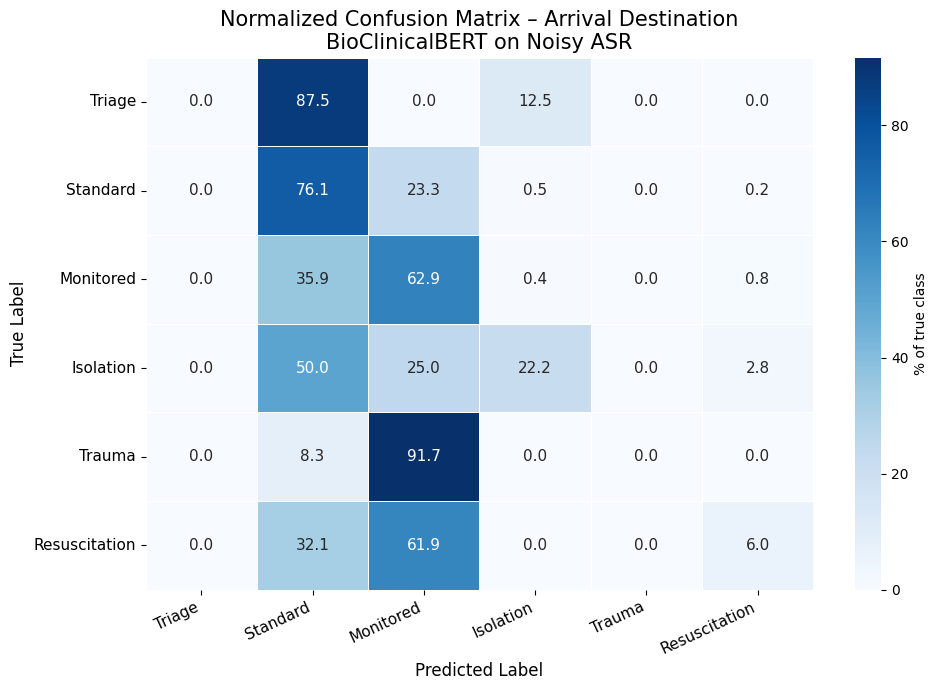

In [ ]:
# ============================================================
# Cleaner normalized confusion matrix for arrival_destination
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np


# Original order
arrival_label_order = [
    "triage_or_waiting_room",
    "standard_ed_bed",
    "monitored_bed",
    "isolation_room",
    "trauma_bay",
    "resuscitation_bay"
]

# Short display names for presentation
arrival_label_display_names = {
    "triage_or_waiting_room": "Triage",
    "standard_ed_bed": "Standard",
    "monitored_bed": "Monitored",
    "isolation_room": "Isolation",
    "trauma_bay": "Trauma",
    "resuscitation_bay": "Resuscitation"
}

arrival_display_order = [
    arrival_label_display_names[label]
    for label in arrival_label_order
]

# Create confusion matrix
arrival_cm = confusion_matrix(
    arrival_final_error_df["true_label"],
    arrival_final_error_df["predicted_label"],
    labels=arrival_label_order
)

# Normalize rows to percentages
arrival_cm_normalized = (
    arrival_cm.astype(float)
    / arrival_cm.sum(axis=1, keepdims=True)
    * 100
)

arrival_cm_normalized = np.nan_to_num(arrival_cm_normalized)

# Convert to DataFrame
arrival_cm_df = pd.DataFrame(
    arrival_cm_normalized,
    index=arrival_display_order,
    columns=arrival_display_order
)

# Plot
plt.figure(figsize=(10, 7))

sns.heatmap(
    arrival_cm_df,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "% of true class"},
    linewidths=0.5,
    annot_kws={"size": 11}
)

plt.title(
    "Normalized Confusion Matrix – Arrival Destination\n"
    "BioClinicalBERT on Noisy ASR",
    fontsize=15
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

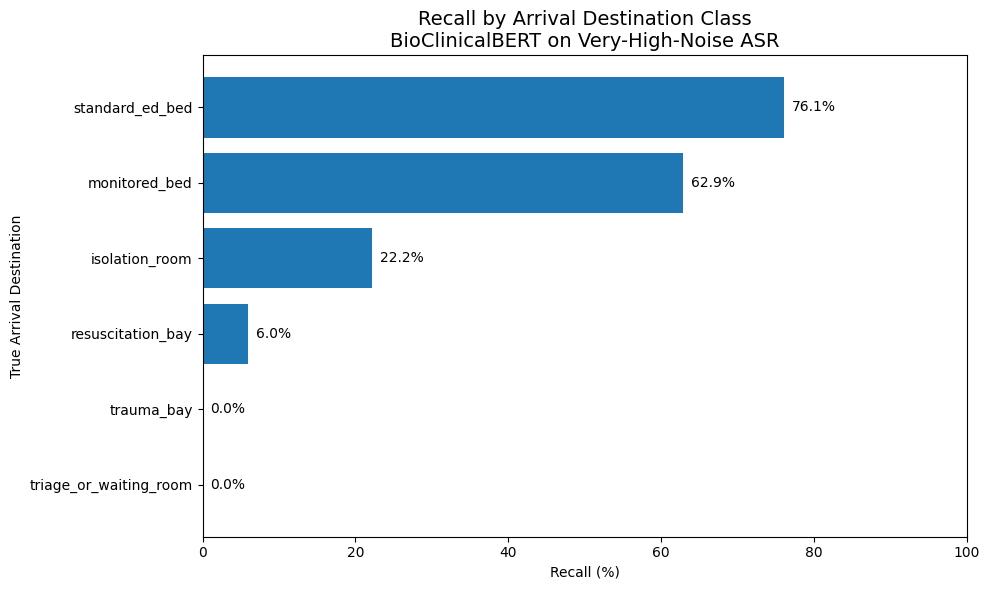

In [ ]:
# ============================================================
# Recall by true arrival class
# ============================================================

arrival_recall_plot = (
    arrival_class_summary
    .sort_values("recall_percent")
    .copy()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    arrival_recall_plot["true_label"],
    arrival_recall_plot["recall_percent"]
)

plt.title(
    "Recall by Arrival Destination Class\n"
    "BioClinicalBERT on Very-High-Noise ASR",
    fontsize=14
)

plt.xlabel("Recall (%)")
plt.ylabel("True Arrival Destination")

plt.xlim(0, 100)

for bar, value in zip(
    bars,
    arrival_recall_plot["recall_percent"]
):
    plt.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        str(round(value, 1)) + "%",
        va="center"
    )

plt.tight_layout()
plt.show()

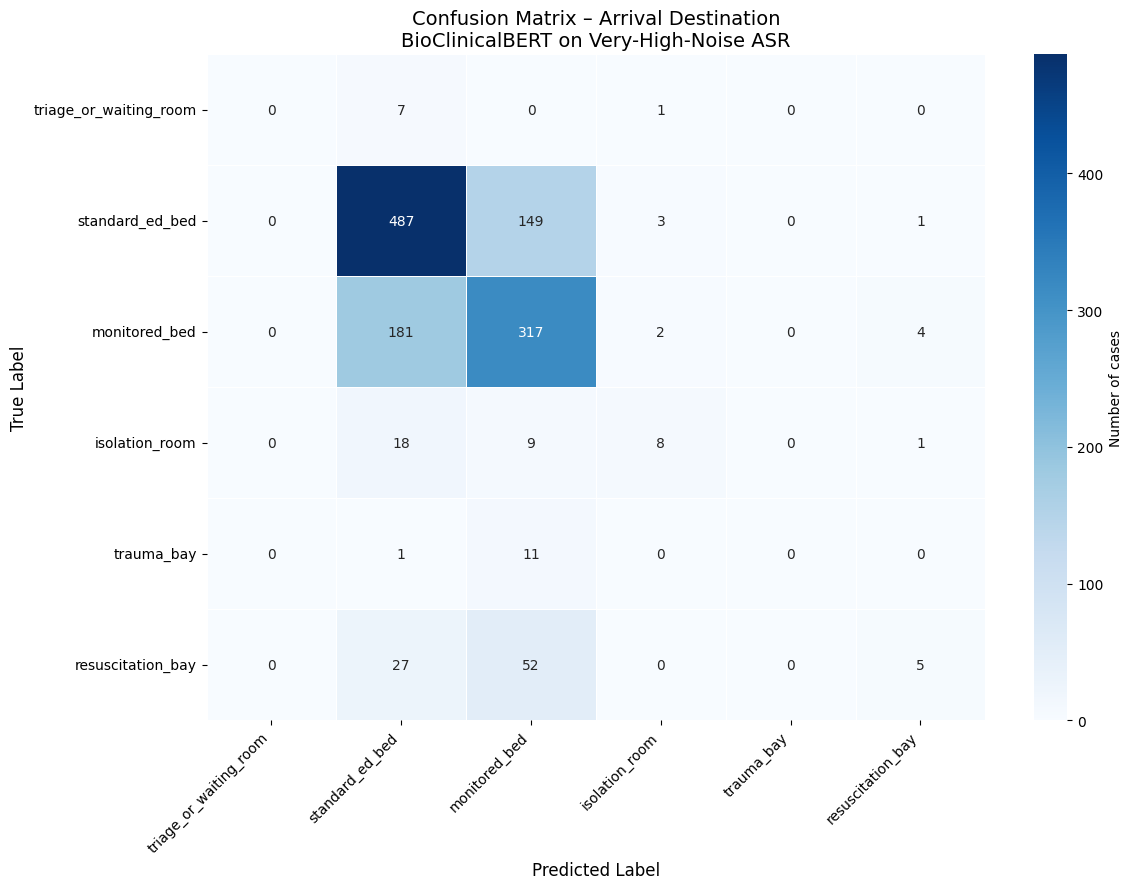

In [ ]:
# ============================================================
# Confusion matrix with absolute case counts
# ============================================================

arrival_cm_counts_df = pd.DataFrame(
    arrival_cm,
    index=arrival_label_order,
    columns=arrival_label_order
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    arrival_cm_counts_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Number of cases"},
    linewidths=0.5
)

plt.title(
    "Confusion Matrix – Arrival Destination\n"
    "BioClinicalBERT on Very-High-Noise ASR",
    fontsize=14
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Finding 2:
# Most common specialty-consultation confusions
# ============================================================

specialty_mistakes = specialty_final_error_df[
    specialty_final_error_df["is_correct"] == False
].copy()

specialty_confusions = (
    specialty_mistakes
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("=" * 100)
print("MOST COMMON SPECIALTY-CONFUSION PAIRS")
print("=" * 100)

for _, row in specialty_confusions.head(20).iterrows():
    print(
        row["true_label"],
        "→",
        row["predicted_label"],
        ":",
        row["count"],
        "cases"
    )

MOST COMMON SPECIALTY-CONFUSION PAIRS
general_surgery_consult → gastroenterology_consult : 68 cases
gastroenterology_consult → general_surgery_consult : 38 cases
neurosurgery_consult → neurology_consult : 24 cases
neurosurgery_consult → orthopedic_consult : 17 cases
urology_consult → gastroenterology_consult : 14 cases
neurology_consult → orthopedic_consult : 11 cases
vascular_surgery_consult → orthopedic_consult : 11 cases
ent_or_eye_oral_consult → orthopedic_consult : 11 cases
hematology_oncology_consult → gastroenterology_consult : 8 cases
cardiology_consult → pulmonology_consult : 8 cases
pulmonology_consult → hematology_oncology_consult : 8 cases
neurology_consult → neurosurgery_consult : 7 cases
cardiology_consult → neurology_consult : 7 cases
gastroenterology_consult → hematology_oncology_consult : 7 cases
infectious_dermatology_consult → gastroenterology_consult : 7 cases
medicine_or_ed_consult → cardiology_consult : 7 cases
infectious_dermatology_consult → orthopedic_consult :

In [ ]:
# ============================================================
# Add confusion percentage within each true specialty class
# ============================================================

specialty_true_class_counts = (
    specialty_final_error_df["true_label"]
    .value_counts()
    .rename_axis("true_label")
    .reset_index(name="total_true_cases")
)


specialty_confusions_with_percent = (
    specialty_confusions
    .merge(
        specialty_true_class_counts,
        on="true_label",
        how="left"
    )
)


specialty_confusions_with_percent["confusion_percent"] = (
    100
    * specialty_confusions_with_percent["count"]
    / specialty_confusions_with_percent["total_true_cases"]
)


specialty_confusions_with_percent["confusion_percent"] = (
    specialty_confusions_with_percent["confusion_percent"]
    .round(2)
)


print(
    specialty_confusions_with_percent[
        [
            "true_label",
            "predicted_label",
            "count",
            "total_true_cases",
            "confusion_percent"
        ]
    ]
    .head(20)
)

                        true_label              predicted_label  count  \
0          general_surgery_consult     gastroenterology_consult     68   
1         gastroenterology_consult      general_surgery_consult     38   
2             neurosurgery_consult            neurology_consult     24   
3             neurosurgery_consult           orthopedic_consult     17   
4                  urology_consult     gastroenterology_consult     14   
5                neurology_consult           orthopedic_consult     11   
6         vascular_surgery_consult           orthopedic_consult     11   
7          ent_or_eye_oral_consult           orthopedic_consult     11   
8      hematology_oncology_consult     gastroenterology_consult      8   
9               cardiology_consult          pulmonology_consult      8   
10             pulmonology_consult  hematology_oncology_consult      8   
11               neurology_consult         neurosurgery_consult      7   
12              cardiology_consult    

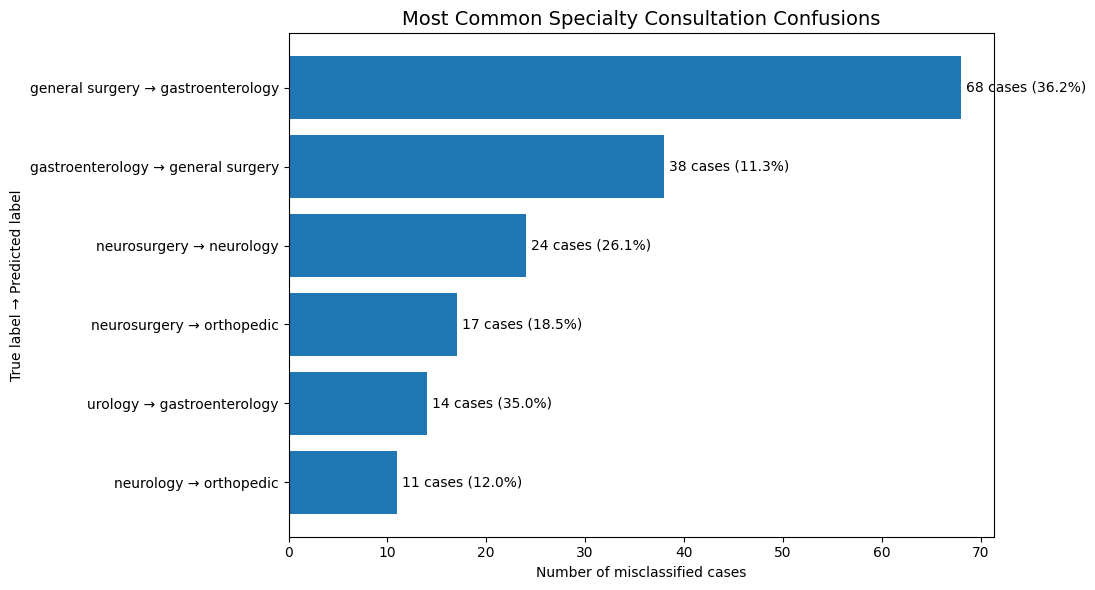

In [ ]:
# ============================================================
# Top specialty confusions with counts and percentages
# ============================================================

number_of_pairs_to_show = 6

specialty_top_confusions_percent = (
    specialty_confusions_with_percent
    .head(number_of_pairs_to_show)
    .copy()
)


specialty_top_confusions_percent["confusion_pair"] = (
    specialty_top_confusions_percent["true_label"]
    .str.replace("_consult", "", regex=False)
    .str.replace("_", " ", regex=False)
    + " → "
    + specialty_top_confusions_percent["predicted_label"]
    .str.replace("_consult", "", regex=False)
    .str.replace("_", " ", regex=False)
)


specialty_top_confusions_percent = (
    specialty_top_confusions_percent
    .sort_values("count", ascending=True)
)


plt.figure(figsize=(11, 6))

bars = plt.barh(
    specialty_top_confusions_percent["confusion_pair"],
    specialty_top_confusions_percent["count"]
)

plt.title(
    "Most Common Specialty Consultation Confusions",
    fontsize=14
)

plt.xlabel("Number of misclassified cases")
plt.ylabel("True label → Predicted label")


for bar, (_, row) in zip(
    bars,
    specialty_top_confusions_percent.iterrows()
):
    label_text = (
        str(int(row["count"]))
        + " cases ("
        + str(round(row["confusion_percent"], 1))
        + "%)"
    )

    plt.text(
        row["count"] + 0.5,
        bar.get_y() + bar.get_height() / 2,
        label_text,
        va="center"
    )


plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Finding 3:
# Check whether wrong primary-label predictions are valid
# secondary specialties in the multi-label annotation
# ============================================================

def parse_specialty_multi_labels(value):
    """
    Convert the multi-label column into a Python list.
    Supports Python-list strings and comma/pipe-separated values.
    """

    if pd.isna(value):
        return []

    if isinstance(value, list):
        return [
            str(item).strip()
            for item in value
        ]

    text_value = str(value).strip()

    try:
        parsed_value = ast.literal_eval(text_value)

        if isinstance(parsed_value, list):
            return [
                str(item).strip()
                for item in parsed_value
            ]

    except (ValueError, SyntaxError):
        pass

    text_value = text_value.replace("|", ",")

    return [
        item.strip().strip("'").strip('"')
        for item in text_value.split(",")
        if item.strip()
    ]


specialty_final_error_df["multi_label_list"] = (
    specialty_final_error_df[
        "specialty_consult_multi_labels"
    ]
    .apply(parse_specialty_multi_labels)
)

specialty_final_error_df[
    "prediction_is_valid_secondary"
] = specialty_final_error_df.apply(
    lambda row: (
        row["predicted_label"]
        in row["multi_label_list"]
    ),
    axis=1
)

specialty_wrong_final = specialty_final_error_df[
    specialty_final_error_df["is_correct"] == False
].copy()

total_wrong = len(specialty_wrong_final)

valid_secondary_count = int(
    specialty_wrong_final[
        "prediction_is_valid_secondary"
    ].sum()
)

valid_secondary_percent = (
    100 * valid_secondary_count / total_wrong
    if total_wrong > 0
    else 0
)

print("=" * 100)
print("MULTI-LABEL VALIDITY ANALYSIS")
print("=" * 100)

print("Total wrong primary-label predictions:", total_wrong)

print(
    "Predictions that were valid secondary specialties:",
    valid_secondary_count
)

print(
    "Percentage of errors that were valid secondary specialties:",
    round(valid_secondary_percent, 2),
    "%"
)

MULTI-LABEL VALIDITY ANALYSIS
Total wrong primary-label predictions: 610
Predictions that were valid secondary specialties: 70
Percentage of errors that were valid secondary specialties: 11.48 %


In [ ]:
# ============================================================
# Print readable examples of valid secondary predictions
# ============================================================

valid_secondary_examples = specialty_wrong_final[
    specialty_wrong_final[
        "prediction_is_valid_secondary"
    ] == True
].copy()

number_of_examples = min(
    5,
    len(valid_secondary_examples)
)

for example_number, (_, row) in enumerate(
    valid_secondary_examples
    .head(number_of_examples)
    .iterrows(),
    start=1
):
    print("\n" + "=" * 120)
    print("EXAMPLE", example_number)
    print("=" * 120)

    print("Source case ID:")
    print(row["source_case_id"])

    print("\nText variant:")
    print(row["text_variant"])

    print("\nPrimary true specialty:")
    print(row["true_label"])

    print("\nModel prediction:")
    print(row["predicted_label"])

    print("\nAll valid specialties:")
    print(row["multi_label_list"])

    print("\nWER:")
    print(round(row["wer"] * 100, 2), "%")

    print("\nClean report:")
    print(row["text_cleaned"])

    print("\nVery-high-noise ASR transcript:")
    print(row["asr_text_noisy"])


EXAMPLE 1
Source case ID:
32822973

Text variant:
brief_radio_missing_details

Primary true specialty:
neurology_consult

Model prediction:
pulmonology_consult

All valid specialties:
['neurology_consult', 'pulmonology_consult']

WER:
66.67 %

Clean report:
80-year-old female with recent sepsis and intubation, now worsening shortness of breath and cough. Febrile at 100.2, tachypneic with RR 28, borderline low BP 99/47, oxygenating well on 2 liters nasal cannula. No chest pain reported.

Very-high-noise ASR transcript:
80-year-old female who's in substance and incubation, now receiving shortness of breath and cough. Fabrilyd-120, the kidney equipped with R-28, Waterline-LVP-9947, oxygenating mild on two-eaters

EXAMPLE 2
Source case ID:
32822973

Text variant:
patient_reported_uncertain

Primary true specialty:
neurology_consult

Model prediction:
pulmonology_consult

All valid specialties:
['neurology_consult', 'pulmonology_consult']

WER:
49.18 %

Clean report:
We’re bringing in an 8

In [ ]:
# ============================================================
# Compact presentation version
# ============================================================

import textwrap


example_row = specialty_wrong_final[
    (specialty_wrong_final["source_case_id"] == 34525212)
    & (
        specialty_wrong_final["text_variant"]
        == "professional_complete"
    )
].iloc[0]


clinical_summary = (
    "48-year-old male with diabetes, spreading gangrene and infection "
    "in the right foot, with gas in the tissues and need for urgent "
    "surgical intervention."
)


print("=" * 85)
print("VALID SECONDARY PREDICTION IN THE DATASET ANNOTATION")
print("=" * 85)

print("\nCase summary:")
print(
    textwrap.fill(
        clinical_summary,
        width=80
    )
)

print("\nPrimary true label:")
print("General Surgery")

print("\nModel prediction:")
print("Vascular Surgery")

print("\nValid specialty annotations:")
print("General Surgery | Orthopedic | Vascular Surgery")

print("\nWhy is this important?")
print(
    textwrap.fill(
        "The prediction was counted as an error in the single-label "
        "evaluation, although Vascular Surgery was marked as a valid "
        "consultation for this case.",
        width=80
    )
)

print("=" * 85)

VALID SECONDARY PREDICTION IN THE DATASET ANNOTATION

Case summary:
48-year-old male with diabetes, spreading gangrene and infection in the right
foot, with gas in the tissues and need for urgent surgical intervention.

Primary true label:
General Surgery

Model prediction:
Vascular Surgery

Valid specialty annotations:
General Surgery | Orthopedic | Vascular Surgery

Why is this important?
The prediction was counted as an error in the single-label evaluation, although
Vascular Surgery was marked as a valid consultation for this case.


In [ ]:
# ============================================================
# Compare two BioClinicalBERT models on the same noisy test set
# Target: specialty_consult_label
# ============================================================

specialty_clean_results = evaluate_saved_model_for_error_analysis(
    df_test=df_asr_test_very_high,
    model_dir=(
        "/content/drive/MyDrive/ems_nlp_results/"
        "best_bioclinicalbert_specialty_maxlen192_no_weights"
    ),
    target_column="specialty_consult_label",
    text_column="asr_text_noisy",
    max_length=192
)

specialty_noisy_results = evaluate_saved_model_for_error_analysis(
    df_test=df_asr_test_very_high,
    model_dir=(
        "/content/drive/MyDrive/ems_nlp_results/"
        "bioclinicalbert_specialty_train_very_high_test_very_high"
    ),
    target_column="specialty_consult_label",
    text_column="asr_text_noisy",
    max_length=192
)

Model directory: /content/drive/MyDrive/ems_nlp_results/best_bioclinicalbert_specialty_maxlen192_no_weights
Target: specialty_consult_label
Text column: asr_text_noisy


In [ ]:
# ============================================================
# Build comparison dataframe
# Clean-trained vs noisy-trained BioClinicalBERT
# Same noisy ASR test set
# ============================================================

clean_error_df = (
    specialty_clean_results["error_df"]
    .copy()
    .reset_index(drop=True)
)

noisy_error_df = (
    specialty_noisy_results["error_df"]
    .copy()
    .reset_index(drop=True)
)


# Verify that both evaluations use the same test rows
assert len(clean_error_df) == len(noisy_error_df), (
    "The two error-analysis dataframes have different lengths."
)

assert clean_error_df["generated_report_id"].equals(
    noisy_error_df["generated_report_id"]
), "The test rows are not in the same order."

assert clean_error_df["specialty_consult_label"].equals(
    noisy_error_df["specialty_consult_label"]
), "The true labels do not match."


# Start from one copy of the test dataframe
comparison_df = clean_error_df.copy()


# Rename clean-trained model outputs
comparison_df = comparison_df.rename(
    columns={
        "predicted_label": "clean_trained_prediction",
        "is_correct": "clean_trained_correct"
    }
)


# Add noisy-trained model outputs
comparison_df["noisy_trained_prediction"] = (
    noisy_error_df["predicted_label"]
)

comparison_df["noisy_trained_correct"] = (
    noisy_error_df["is_correct"]
)


print("Comparison dataframe created successfully.")
print("Shape:", comparison_df.shape)

print("\nClean-trained model correct predictions:")
print(int(comparison_df["clean_trained_correct"].sum()))

print("\nNoisy-trained model correct predictions:")
print(int(comparison_df["noisy_trained_correct"].sum()))

In [ ]:
# ============================================================
# Select one readable example:
# Clean-trained model was wrong
# Noisy-trained model was correct
# Moderate-to-high WER
# ============================================================

candidate_examples = comparison_df[
    (comparison_df["clean_trained_correct"] == False)
    &
    (comparison_df["noisy_trained_correct"] == True)
    &
    (comparison_df["wer"] >= 0.35)
    &
    (comparison_df["wer"] <= 0.65)
].copy()

print("Number of suitable examples:", len(candidate_examples))

example = candidate_examples.sort_values(
    by="wer",
    ascending=False
).iloc[0]

print("=" * 120)
print("EXAMPLE: NOISY TRAINING CORRECTED THE PREDICTION")
print("=" * 120)

print("\nTrue specialty:")
print(example["specialty_consult_label"])

print("\nClean-trained model prediction:")
print(example["clean_trained_prediction"])

print("\nNoisy-trained model prediction:")
print(example["noisy_trained_prediction"])

print("\nWER:")
print(round(example["wer"] * 100, 2), "%")

print("\nClean report:")
print(example["text_cleaned"])

print("\nVery-high-noise ASR transcript:")
print(example["asr_text_noisy"])

Number of suitable examples: 142
EXAMPLE: NOISY TRAINING CORRECTED THE PREDICTION

True specialty:
orthopedic_consult

Clean-trained model prediction:
ent_or_eye_oral_consult

Noisy-trained model prediction:
orthopedic_consult

WER:
64.91 %

Clean report:
We’re bringing in a 27-year-old male who slipped on stairs carrying laundry and fractured his left distal tibia. He denies passing out or hitting his head, no other pain, numbness, or tingling reported. He’s holding the ankle due to pain but no movement. Vitals are stable: pulse 80, breathing 16, BP 140/70, oxygen 98% on room air.

Very-high-noise ASR transcript:
We're bringing in a 27-year-old nail whose lip comes there to carry one re-intruch of his leftus with tidius. He denies passing out or hitting his head, no other being, none as once in the world reported. He's holding the ankle through the head, but no moving. Witals are stable, plus 80, breathing 16, if he wants 40, slightly 70, oxygen 98% of the room air.


In [ ]:
# ============================================================
# Print one example in a screenshot-friendly format
# ============================================================

import textwrap

# Example content
true_label = "orthopedic_consult"
clean_pred = "ent_or_eye_oral_consult"
noisy_pred = "orthopedic_consult"
wer_value = 64.91

clean_report = (
    "We’re bringing in a 27-year-old male who slipped on stairs carrying laundry "
    "and fractured his left distal tibia. He denies passing out or hitting his head, "
    "no other pain, numbness, or tingling reported. He’s holding the ankle due to pain "
    "but no movement. Vitals are stable: pulse 80, breathing 16, BP 140/70, oxygen 98% on room air."
)

asr_report = (
    "We're bringing in a 27-year-old nail whose lip comes there to carry one re-intruch "
    "of his leftus with tidius. He denies passing out or hitting his head, no other being, "
    "none as once in the world reported. He's holding the ankle through the head, but no moving. "
    "Witals are stable, plus 80, breathing 16, if he wants 40, slightly 70, oxygen 98% of the room air."
)

# Function to print wrapped text nicely
def print_wrapped_block(title, text, width=90):
    print(title)
    print("-" * len(title))
    print(textwrap.fill(str(text), width=width))
    print()

# Print the formatted example
print("=" * 110)
print("EXAMPLE: NOISY TRAINING CORRECTED THE PREDICTION")
print("=" * 110)
print()

print("True specialty:", true_label)
print("Clean-trained model prediction:", clean_pred)
print("Noisy-trained model prediction:", noisy_pred)
print("WER:", str(wer_value) + "%")
print()

print_wrapped_block("Clean report", clean_report, width=90)
print_wrapped_block("noise ASR transcript", asr_report, width=90)

EXAMPLE: NOISY TRAINING CORRECTED THE PREDICTION

True specialty: orthopedic_consult
Clean-trained model prediction: ent_or_eye_oral_consult
Noisy-trained model prediction: orthopedic_consult
WER: 64.91%

Clean report
------------
We’re bringing in a 27-year-old male who slipped on stairs carrying laundry and fractured
his left distal tibia. He denies passing out or hitting his head, no other pain, numbness,
or tingling reported. He’s holding the ankle due to pain but no movement. Vitals are
stable: pulse 80, breathing 16, BP 140/70, oxygen 98% on room air.

noise ASR transcript
--------------------
We're bringing in a 27-year-old nail whose lip comes there to carry one re-intruch of his
leftus with tidius. He denies passing out or hitting his head, no other being, none as
once in the world reported. He's holding the ankle through the head, but no moving. Witals
are stable, plus 80, breathing 16, if he wants 40, slightly 70, oxygen 98% of the room
air.



In [ ]:
# ============================================================
# Most common confusions - arrival_destination
# Corrected final model
# ============================================================

arrival_mistakes = arrival_final_error_df[
    arrival_final_error_df["is_correct"] == False
].copy()

arrival_confusions = (
    arrival_mistakes
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

arrival_confusions.head(20)

,true_label,predicted_label,count
5,monitored_bed,standard_ed_bed,181
9,standard_ed_bed,monitored_bed,149
6,resuscitation_bay,monitored_bed,52
7,resuscitation_bay,standard_ed_bed,27
2,isolation_room,standard_ed_bed,18
11,trauma_bay,monitored_bed,11
0,isolation_room,monitored_bed,9
14,triage_or_waiting_room,standard_ed_bed,7
4,monitored_bed,resuscitation_bay,4
8,standard_ed_bed,isolation_room,3


In [ ]:
# ============================================================
# Most common confusions - specialty_consult_label
# ============================================================

specialty_mistakes = specialty_final_error_df[specialty_final_error_df["is_correct"] == False].copy()

specialty_confusions = (
    specialty_mistakes
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

specialty_confusions.head(20)

,true_label,predicted_label,count
35,general_surgery_consult,gastroenterology_consult,64
24,gastroenterology_consult,general_surgery_consult,37
99,neurosurgery_consult,neurology_consult,22
25,gastroenterology_consult,hematology_oncology_consult,16
100,neurosurgery_consult,orthopedic_consult,13
87,neurology_consult,gastroenterology_consult,13
6,cardiology_consult,pulmonology_consult,12
118,orthopedic_consult,vascular_surgery_consult,9
61,medicine_or_ed_consult,cardiology_consult,9
124,pulmonology_consult,cardiology_consult,9


In [ ]:
# ============================================================
# Error summary by class - arrival_destination
# Corrected final model
# ============================================================

arrival_error_summary = (
    arrival_final_error_df
    .groupby("true_label")
    .agg(
        total_cases=("true_label", "count"),
        correct_cases=("is_correct", "sum"),
        average_wer=("wer", "mean")
    )
    .reset_index()
)

arrival_error_summary["wrong_cases"] = (
    arrival_error_summary["total_cases"]
    - arrival_error_summary["correct_cases"]
)

# Recall for each true class
arrival_error_summary["recall_per_class"] = (
    arrival_error_summary["correct_cases"]
    / arrival_error_summary["total_cases"]
)

arrival_error_summary["recall_percent"] = (
    arrival_error_summary["recall_per_class"] * 100
)

arrival_error_summary = (
    arrival_error_summary
    .sort_values(by="recall_per_class")
    .reset_index(drop=True)
)

arrival_error_summary

,true_label,total_cases,correct_cases,average_wer,wrong_cases,recall_per_class,recall_percent
0,triage_or_waiting_room,8,0,0.426240,8,0.000000,0.000000
1,trauma_bay,12,0,0.352397,12,0.000000,0.000000
2,resuscitation_bay,84,5,0.444738,79,0.059524,5.952381
3,isolation_room,36,8,0.429426,28,0.222222,22.222222
4,monitored_bed,504,317,0.448739,187,0.628968,62.896825
5,standard_ed_bed,640,487,0.451010,153,0.760938,76.093750


In [ ]:
# ============================================================
# Error summary by class - specialty_consult_label
# ============================================================

specialty_error_summary = (
    specialty_final_error_df
    .groupby("true_label")
    .agg(
        total_cases=("true_label", "count"),
        correct_cases=("is_correct", "sum"),
        average_wer=("wer", "mean")
    )
    .reset_index()
)

specialty_error_summary["wrong_cases"] = (
    specialty_error_summary["total_cases"]
    - specialty_error_summary["correct_cases"]
)

# Recall for each true class
specialty_error_summary["recall_per_class"] = (
    specialty_error_summary["correct_cases"]
    / specialty_error_summary["total_cases"]
)

specialty_error_summary["recall_percent"] = (
    specialty_error_summary["recall_per_class"] * 100
)

specialty_error_summary = (
    specialty_error_summary
    .sort_values(by="recall_per_class")
    .reset_index(drop=True)
)

specialty_error_summary

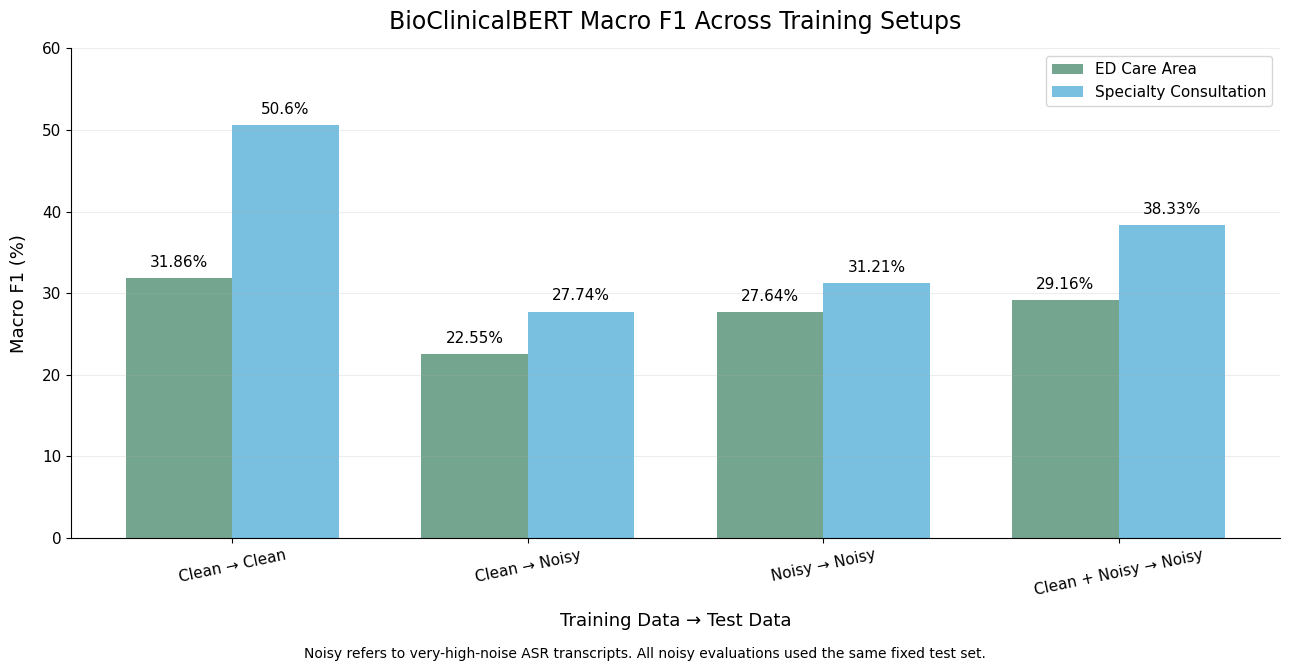

In [5]:
# ============================================================
# BioClinicalBERT performance across training setups
# README-ready version using presentation colors
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# Training and test setups
setups = [
    "Clean → Clean",
    "Clean → Noisy",
    "Noisy → Noisy",
    "Clean + Noisy → Noisy"
]

# Macro F1 results in percentages
arrival_macro_f1 = [
    31.86,
    22.55,
    27.64,
    29.16
]

specialty_macro_f1 = [
    50.6,
    27.74,
    31.21,
    38.33
]

# Text labels preserve the preferred number of decimal places
arrival_value_labels = [
    "31.86%",
    "22.55%",
    "27.64%",
    "29.16%"
]

specialty_value_labels = [
    "50.6%",
    "27.74%",
    "31.21%",
    "38.33%"
]

# Positions of the setup groups
x_positions = np.arange(len(setups))

# Width of each bar
bar_width = 0.36

# Colors adapted from the presentation design
arrival_color = "#73A58F"       # Presentation green
specialty_color = "#78BFE0"     # Presentation light blue


# Create the figure
fig, ax = plt.subplots(figsize=(13, 6.5))


# Plot ED care-area results
arrival_bars = ax.bar(
    x_positions - bar_width / 2,
    arrival_macro_f1,
    width=bar_width,
    label="ED Care Area",
    color=arrival_color
)

# Plot specialty-consultation results
specialty_bars = ax.bar(
    x_positions + bar_width / 2,
    specialty_macro_f1,
    width=bar_width,
    label="Specialty Consultation",
    color=specialty_color
)


# Add value labels above the ED care-area bars
for bar, label in zip(arrival_bars, arrival_value_labels):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        label,
        ha="center",
        va="bottom",
        fontsize=11
    )


# Add value labels above the specialty bars
for bar, label in zip(
    specialty_bars,
    specialty_value_labels
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        label,
        ha="center",
        va="bottom",
        fontsize=11
    )


# Main title
ax.set_title(
    "BioClinicalBERT Macro F1 Across Training Setups",
    fontsize=17,
    pad=14
)

# Axis labels
ax.set_xlabel(
    "Training Data → Test Data",
    fontsize=13,
    labelpad=10
)

ax.set_ylabel(
    "Macro F1 (%)",
    fontsize=13,
    labelpad=10
)


# X-axis setup labels
ax.set_xticks(x_positions)

ax.set_xticklabels(
    setups,
    rotation=12,
    ha="center",
    fontsize=11
)


# Y-axis range
ax.set_ylim(0, 60)

ax.tick_params(
    axis="y",
    labelsize=11
)


# Light horizontal grid only
ax.grid(
    axis="y",
    linestyle="-",
    alpha=0.22
)

# Remove unnecessary upper and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Legend
ax.legend(
    loc="upper right",
    fontsize=11,
    frameon=True
)


# Add a short note below the graph
fig.text(
    0.5,
    -0.02,
    "Noisy refers to very-high-noise ASR transcripts. "
    "All noisy evaluations used the same fixed test set.",
    ha="center",
    fontsize=10
)


plt.tight_layout()

# Save a high-resolution version for GitHub
plt.savefig(
    "bioclinicalbert_training_setup_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "bioclinicalbert_macro_f1_training_setups.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()

In [6]:
from google.colab import files

files.download(
    "bioclinicalbert_macro_f1_training_setups.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Main Results

BioClinicalBERT was evaluated under four training and testing
configurations. Macro F1 was selected as the primary metric because
both prediction targets were highly imbalanced.

Training only on clean text resulted in a substantial performance drop
when evaluated on noisy ASR transcripts. Training with noisy transcripts
improved performance, while the combined clean-and-noisy training strategy
achieved the highest Macro F1 under noisy evaluation for both targets.

The results indicate that exposure to ASR errors during training improves
model robustness, although performance under severe noise remained below
the clean-text baseline.

In [7]:
# ============================================================
# Create final model results table
# ============================================================

import pandas as pd

final_model_results = pd.DataFrame([
    # Clean → Clean
    {
        "Model": "BioClinicalBERT",
        "Target": "ED Care Area",
        "Training Data": "Clean",
        "Test Data": "Clean",
        "Accuracy": 0.6710,
        "Macro F1": 0.3190
    },
    {
        "Model": "BioClinicalBERT",
        "Target": "Specialty Consultation",
        "Training Data": "Clean",
        "Test Data": "Clean",
        "Accuracy": 0.6570,
        "Macro F1": 0.5060
    },
    {
        "Model": "DistilBERT",
        "Target": "ED Care Area",
        "Training Data": "Clean",
        "Test Data": "Clean",
        "Accuracy": 0.6650,
        "Macro F1": 0.2800
    },
    {
        "Model": "DistilBERT",
        "Target": "Specialty Consultation",
        "Training Data": "Clean",
        "Test Data": "Clean",
        "Accuracy": 0.6070,
        "Macro F1": 0.3440
    },

    # Clean → Noisy
    {
        "Model": "BioClinicalBERT",
        "Target": "ED Care Area",
        "Training Data": "Clean",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.5900,
        "Macro F1": 0.2255
    },
    {
        "Model": "BioClinicalBERT",
        "Target": "Specialty Consultation",
        "Training Data": "Clean",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.3930,
        "Macro F1": 0.2774
    },
    {
        "Model": "DistilBERT",
        "Target": "ED Care Area",
        "Training Data": "Clean",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.5590,
        "Macro F1": 0.2387
    },
    {
        "Model": "DistilBERT",
        "Target": "Specialty Consultation",
        "Training Data": "Clean",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.4080,
        "Macro F1": 0.2245
    },

    # Noisy → Noisy
    {
        "Model": "BioClinicalBERT",
        "Target": "ED Care Area",
        "Training Data": "Noisy ASR",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.6464,
        "Macro F1": 0.2764
    },
    {
        "Model": "BioClinicalBERT",
        "Target": "Specialty Consultation",
        "Training Data": "Noisy ASR",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.4977,
        "Macro F1": 0.3121
    },
    {
        "Model": "DistilBERT",
        "Target": "ED Care Area",
        "Training Data": "Noisy ASR",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.6246,
        "Macro F1": 0.2198
    },
    {
        "Model": "DistilBERT",
        "Target": "Specialty Consultation",
        "Training Data": "Noisy ASR",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.4509,
        "Macro F1": 0.1982
    },

    # Clean + Noisy → Noisy
    {
        "Model": "BioClinicalBERT",
        "Target": "ED Care Area",
        "Training Data": "Clean + Noisy ASR",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.6363,
        "Macro F1": 0.2916
    },
    {
        "Model": "BioClinicalBERT",
        "Target": "Specialty Consultation",
        "Training Data": "Clean + Noisy ASR",
        "Test Data": "Noisy ASR",
        "Accuracy": 0.5250,
        "Macro F1": 0.3833
    }
])

display(final_model_results)

,Model,Target,Training Data,Test Data,Accuracy,Macro F1
0,BioClinicalBERT,ED Care Area,Clean,Clean,0.6710,0.3190
1,BioClinicalBERT,Specialty Consultation,Clean,Clean,0.6570,0.5060
2,DistilBERT,ED Care Area,Clean,Clean,0.6650,0.2800
3,DistilBERT,Specialty Consultation,Clean,Clean,0.6070,0.3440
4,BioClinicalBERT,ED Care Area,Clean,Noisy ASR,0.5900,0.2255
5,BioClinicalBERT,Specialty Consultation,Clean,Noisy ASR,0.3930,0.2774
6,DistilBERT,ED Care Area,Clean,Noisy ASR,0.5590,0.2387
7,DistilBERT,Specialty Consultation,Clean,Noisy ASR,0.4080,0.2245
8,BioClinicalBERT,ED Care Area,Noisy ASR,Noisy ASR,0.6464,0.2764
9,BioClinicalBERT,Specialty Consultation,Noisy ASR,Noisy ASR,0.4977,0.3121


In [8]:
final_model_results.to_csv(
    "final_model_results.csv",
    index=False
)

print("Saved: final_model_results.csv")

Saved: final_model_results.csv


In [9]:
from google.colab import files

files.download("final_model_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Appendix: Additional Experiments**

### Baseline setup: imports + helper function

In [ ]:
# ============================================================
# Baseline setup - clear text output version
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report


# ------------------------------------------------------------
# Helper function for running baseline model
# ------------------------------------------------------------

def run_text_baseline_clear_output(df, text_column, target_column, group_column):
    """
    Run a TF-IDF + Logistic Regression baseline model.

    The split is performed by source_case_id using GroupShuffleSplit,
    so all text variants of the same source case stay together.
    """

    # --------------------------------------------------------
    # 1. Define X, y, and groups
    # --------------------------------------------------------

    X = df[[text_column]].copy()
    y = df[target_column].copy()
    groups = df[group_column].copy()

    # --------------------------------------------------------
    # 2. Group-based train-test split
    # --------------------------------------------------------

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    groups_train = groups.iloc[train_idx].copy()
    groups_test = groups.iloc[test_idx].copy()

    # --------------------------------------------------------
    # 3. Print split information
    # --------------------------------------------------------

    print("Target:", target_column)
    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    print("\nUnique source cases:")
    print("Train:", groups_train.nunique())
    print("Test:", groups_test.nunique())

    source_case_overlap = len(set(groups_train).intersection(set(groups_test)))
    print("Source case overlap between train and test:", source_case_overlap)

    print("\nTrain target distribution:")
    print(y_train.value_counts())

    print("\nTest target distribution:")
    print(y_test.value_counts())

    # --------------------------------------------------------
    # 4. Build TF-IDF + Logistic Regression pipeline
    # --------------------------------------------------------

    model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ])

    # --------------------------------------------------------
    # 5. Train the model
    # --------------------------------------------------------

    model.fit(X_train[text_column], y_train)

    # --------------------------------------------------------
    # 6. Predict on the test set
    # --------------------------------------------------------

    y_pred = model.predict(X_test[text_column])

    # --------------------------------------------------------
    # 7. Calculate evaluation metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    # --------------------------------------------------------
    # 8. Print results clearly
    # --------------------------------------------------------

    print("\n" + "=" * 120)
    print("RESULTS FOR TARGET:", target_column)
    print("=" * 120)

    print("\nAccuracy:")
    print(accuracy)

    print("\nMacro F1:")
    print(macro_f1)

    print("\nWeighted F1:")
    print(weighted_f1)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # --------------------------------------------------------
    # 9. Return objects for later analysis
    # --------------------------------------------------------

    return model, X_train, X_test, y_train, y_test, y_pred

In [ ]:
# ============================================================
# Baseline model for arrival_destination
# ============================================================

arrival_model, X_train_arrival, X_test_arrival, y_train_arrival, y_test_arrival, y_pred_arrival = run_text_baseline_clear_output(
    df=df,
    text_column="text_cleaned",
    target_column="arrival_destination",
    group_column="source_case_id"
)


Target: arrival_destination
Train shape: (6844, 1)
Test shape: (1712, 1)

Unique source cases:
Train: 1711
Test: 428
Source case overlap between train and test: 0

Train target distribution:
arrival_destination
standard_ed_bed           3388
monitored_bed             2772
resuscitation_bay          460
isolation_room             148
triage_or_waiting_room      60
trauma_bay                  16
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_bed           828
monitored_bed             704
resuscitation_bay         120
isolation_room             44
triage_or_waiting_room      8
trauma_bay                  8
Name: count, dtype: int64

RESULTS FOR TARGET: arrival_destination

Accuracy:
0.6816588785046729

Macro F1:
0.3098072806290804

Weighted F1:
0.66254726680461

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.43      0.14      0.21        44
         monitored_bed       0.66      

In [ ]:
# ============================================================
# Baseline model for specialty_consult_label
# ============================================================

specialty_model, X_train_specialty, X_test_specialty, y_train_specialty, y_test_specialty, y_pred_specialty = run_text_baseline_clear_output(
    df=df,
    text_column="text_cleaned",
    target_column="specialty_consult_label",
    group_column="source_case_id"
)

Target: specialty_consult_label
Train shape: (6844, 1)
Test shape: (1712, 1)

Unique source cases:
Train: 1711
Test: 428
Source case overlap between train and test: 0

Train target distribution:
specialty_consult_label
gastroenterology_consult          1784
general_surgery_consult           1040
orthopedic_consult                1024
neurology_consult                  392
neurosurgery_consult               372
infectious_dermatology_consult     280
cardiology_consult                 272
hematology_oncology_consult        260
pulmonology_consult                212
ent_or_eye_oral_consult            196
vascular_surgery_consult           180
urology_consult                    180
nephrology_consult                 156
other_consult                      140
obgyn_consult                      104
endocrinology_consult               96
medicine_or_ed_consult              92
psychiatry_addiction_consult        64
Name: count, dtype: int64

Test target distribution:
specialty_consult_label
ga


TF-IDF + Logistic Regression Hyperparameter Tuning

In [ ]:
# Grid search for TF-IDF + Logistic Regression settings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

def tune_tfidf_logistic_regression(df_train, df_val, target_column):
    X_train = df_train["text_cleaned"].fillna("").astype(str)
    y_train = df_train[target_column]

    X_val = df_val["text_cleaned"].fillna("").astype(str)
    y_val = df_val[target_column]

    ngram_options = [(1, 1), (1, 2), (1, 3)]
    min_df_options = [1, 2, 3]
    class_weight_options = [None, "balanced"]

    results = []

    for ngram_range in ngram_options:
        for min_df in min_df_options:
            for class_weight in class_weight_options:

                model = Pipeline([
                    ("tfidf", TfidfVectorizer(
                        lowercase=True,
                        stop_words="english",
                        ngram_range=ngram_range,
                        min_df=min_df,
                        max_df=0.95
                    )),
                    ("classifier", LogisticRegression(
                        max_iter=1000,
                        class_weight=class_weight,
                        solver="liblinear",
                        random_state=42
                    ))
                ])

                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)

                accuracy = accuracy_score(y_val, y_pred)
                macro_f1 = f1_score(y_val, y_pred, average="macro")
                weighted_f1 = f1_score(y_val, y_pred, average="weighted")

                results.append({
                    "target": target_column,
                    "ngram_range": str(ngram_range),
                    "min_df": min_df,
                    "class_weight": class_weight,
                    "accuracy": accuracy,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

                print("Finished:",
                      "ngram_range =", ngram_range,
                      "| min_df =", min_df,
                      "| class_weight =", class_weight,
                      "| Macro F1 =", round(macro_f1, 4))

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 100)
    print("Best TF-IDF settings for target:", target_column)
    print("=" * 100)

    best_row = results_df.iloc[0]

    print("ngram_range:", best_row["ngram_range"])
    print("min_df:", best_row["min_df"])
    print("class_weight:", best_row["class_weight"])
    print("Accuracy:", best_row["accuracy"])
    print("Macro F1:", best_row["macro_f1"])
    print("Weighted F1:", best_row["weighted_f1"])

    print("\nTop 10 results:")
    print(results_df.head(10))

    return results_df

Run tuning for arrival_destination

In [ ]:
# Tune TF-IDF baseline for arrival_destination

arrival_tfidf_results = tune_tfidf_logistic_regression(
    df_train=df_train_arrival,
    df_val=df_val_arrival,
    target_column="arrival_destination"
)

Target: arrival_destination
Train shape: (5988, 14)
Validation shape: (1284, 14)
Test shape: (1284, 14)

Unique source cases:
Train: 1497
Validation: 321
Test: 321

Source case overlap checks:
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
trauma_bay                 12
triage_or_waiting_room      

Final evaluation on test for arrival_destination

In [ ]:
# Final TF-IDF + Logistic Regression test evaluation - arrival_destination

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

df_train_final_arrival = pd.concat(
    [df_train_arrival, df_val_arrival],
    axis=0
).reset_index(drop=True)

X_train_final = df_train_final_arrival["text_cleaned"].fillna("").astype(str)
y_train_final = df_train_final_arrival["arrival_destination"]

X_test_final = df_test_arrival["text_cleaned"].fillna("").astype(str)
y_test_final = df_test_arrival["arrival_destination"]

final_arrival_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

final_arrival_model.fit(X_train_final, y_train_final)
y_pred_final_arrival = final_arrival_model.predict(X_test_final)

accuracy = accuracy_score(y_test_final, y_pred_final_arrival)
macro_f1 = f1_score(y_test_final, y_pred_final_arrival, average="macro")
weighted_f1 = f1_score(y_test_final, y_pred_final_arrival, average="weighted")

print("Final test results for target: arrival_destination")
print("=" * 100)

print("\nBest validation settings:")
print("ngram_range: (1, 2)")
print("min_df: 2")
print("class_weight: balanced")

print("\nTrain + Validation size:")
print(len(X_train_final))

print("\nTest size:")
print(len(X_test_final))

print("\nTest target distribution:")
print(y_test_final.value_counts())

print("\nAccuracy:")
print(accuracy)

print("\nMacro F1:")
print(macro_f1)

print("\nWeighted F1:")
print(weighted_f1)

print("\nClassification report:")
print(classification_report(y_test_final, y_pred_final_arrival, zero_division=0))

Final test results for target: arrival_destination

Best validation settings:
ngram_range: (1, 2)
min_df: 2
class_weight: balanced

Train + Validation size:
7272

Test size:
1284

Test target distribution:
arrival_destination
standard_ed_bed           640
monitored_bed             504
resuscitation_bay          84
isolation_room             36
trauma_bay                 12
triage_or_waiting_room      8
Name: count, dtype: int64

Accuracy:
0.6814641744548287

Macro F1:
0.33005399149619513

Weighted F1:
0.6637317923916877

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.56      0.25      0.35        36
         monitored_bed       0.63      0.67      0.65       504
     resuscitation_bay       0.33      0.15      0.21        84
       standard_ed_bed       0.74      0.80      0.77       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8



In [ ]:
# ============================================================
# Save final TF-IDF arrival model to Google Drive
# ============================================================

import os
import joblib

results_dir = "/content/drive/MyDrive/ems_nlp_results"
os.makedirs(results_dir, exist_ok=True)

model_path = f"{results_dir}/tfidf_logreg_arrival_clean_model.joblib"

joblib.dump(final_arrival_model, model_path)

print("Saved model to:")
print(model_path)

Saved model to:
/content/drive/MyDrive/ems_nlp_results/tfidf_logreg_arrival_clean_model.joblib


Run tuning for specialty_consult_label




In [ ]:
# Tune TF-IDF baseline for specialty_consult_label

specialty_tfidf_results = tune_tfidf_logistic_regression(
    df_train=df_train_specialty,
    df_val=df_val_specialty,
    target_column="specialty_consult_label"
)

Target: specialty_consult_label
Train shape: (5988, 14)
Validation shape: (1284, 14)
Test shape: (1284, 14)

Unique source cases:
Train: 1497
Validation: 321
Test: 321

Source case overlap checks:
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  324
neurosurgery_consult               272
infectious_dermatology_consult     260
cardiology_consult                 260
hematology_oncology_consult        216
vascular_surgery_consult           184
pulmonology_consult                180
urology_consult                    172
ent_or_eye_oral_consult            168
nephrology_consult                 140
other_consult                      116
medicine_or_ed_consult             100
obgyn_consult                       80
endocrinology_consult               76
psychiatry_addiction_cons

Final evaluation on test for specialty_consult_label

In [ ]:
# Final TF-IDF + Logistic Regression test evaluation - specialty_consult_label

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

df_train_final_specialty = pd.concat(
    [df_train_specialty, df_val_specialty],
    axis=0
).reset_index(drop=True)

X_train_final = df_train_final_specialty["text_cleaned"].fillna("").astype(str)
y_train_final = df_train_final_specialty["specialty_consult_label"]

X_test_final = df_test_specialty["text_cleaned"].fillna("").astype(str)
y_test_final = df_test_specialty["specialty_consult_label"]

final_specialty_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 1),
        min_df=1,
        max_df=0.95
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

final_specialty_model.fit(X_train_final, y_train_final)
y_pred_final_specialty = final_specialty_model.predict(X_test_final)

accuracy = accuracy_score(y_test_final, y_pred_final_specialty)
macro_f1 = f1_score(y_test_final, y_pred_final_specialty, average="macro")
weighted_f1 = f1_score(y_test_final, y_pred_final_specialty, average="weighted")

print("Final test results for target: specialty_consult_label")
print("=" * 100)

print("\nBest validation settings:")
print("ngram_range: (1, 1)")
print("min_df: 1")
print("class_weight: balanced")

print("\nTrain + Validation size:")
print(len(X_train_final))

print("\nTest size:")
print(len(X_test_final))

print("\nTest target distribution:")
print(y_test_final.value_counts())

print("\nAccuracy:")
print(accuracy)

print("\nMacro F1:")
print(macro_f1)

print("\nWeighted F1:")
print(weighted_f1)

print("\nClassification report:")
print(classification_report(y_test_final, y_pred_final_specialty, zero_division=0))

Final test results for target: specialty_consult_label

Best validation settings:
ngram_range: (1, 1)
min_df: 1
class_weight: balanced

Train + Validation size:
7272

Test size:
1284

Test target distribution:
specialty_consult_label
gastroenterology_consult          336
general_surgery_consult           188
orthopedic_consult                160
neurology_consult                  92
neurosurgery_consult               92
cardiology_consult                 60
infectious_dermatology_consult     56
ent_or_eye_oral_consult            48
urology_consult                    40
pulmonology_consult                40
vascular_surgery_consult           36
hematology_oncology_consult        28
nephrology_consult                 24
endocrinology_consult              24
medicine_or_ed_consult             24
obgyn_consult                      20
other_consult                       8
psychiatry_addiction_consult        8
Name: count, dtype: int64

Accuracy:
0.6191588785046729

Macro F1:
0.4518231703663

In [ ]:
# ============================================================
# Save final TF-IDF specialty model to Google Drive
# ============================================================

import os
import joblib

results_dir = "/content/drive/MyDrive/ems_nlp_results"
os.makedirs(results_dir, exist_ok=True)

model_path = f"{results_dir}/tfidf_logreg_specialty_clean_model.joblib"

joblib.dump(final_specialty_model, model_path)

print("Saved model to:")
print(model_path)

Saved model to:
/content/drive/MyDrive/ems_nlp_results/tfidf_logreg_specialty_clean_model.joblib


### Transformer Classification

**DistilBERT**

 Additional experiment - not selected
 DistilBERT with partial freeze - arrival_destination
 Result:
  - Accuracy = 0.660
 - Macro F1 = 0.268
 - Weighted F1 = 0.628
Although accuracy increased, Macro F1 decreased compared to
full fine-tuning, so this setting was not selected.


In [ ]:
# ============================================================
# DistilBERT with partial freeze - arrival_destination
# Less aggressive freeze: train last 2 layers + classifier
# ============================================================

distilbert_arrival_freeze_last2_trainer, distilbert_arrival_freeze_last2_tokenizer, distilbert_arrival_freeze_last2_label_encoder, y_test_arrival_distilbert_freeze_last2, y_pred_arrival_distilbert_freeze_last2 = train_transformer_classifier_with_freeze(
    df_train=df_train_arrival,
    df_val=df_val_arrival,
    df_test=df_test_arrival,
    target_column="arrival_destination",
    model_name="distilbert-base-uncased",
    run_name="distilbert_arrival_maxlen192_freeze_last2",
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    num_unfrozen_layers=2
)

Target: arrival_destination
Model: distilbert-base-uncased
Freeze: True
Max length: 192
Run name: distilbert_arrival_maxlen192_freeze_last2
Output directory: ./transformer_results_distilbert_arrival_maxlen192_freeze_last2
Number of labels: 6

Label mapping:
0 = isolation_room
1 = monitored_bed
2 = resuscitation_bay
3 = standard_ed_bed
4 = trauma_bay
5 = triage_or_waiting_room

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model type: DistilBERT
Total transformer layers: 6
Unfrozen last layers: 2
Trainable parameters: 14770950
Total parameters: 66958086
Trainable percentage: 22.06 %


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.002340,0.896461,0.643302,0.224632,0.616928
2,0.866533,0.846879,0.657321,0.241766,0.626028
3,0.828825,0.841343,0.661994,0.270407,0.635518


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final evaluation on test set:



Accuracy:
0.660436137071651

Macro F1:
0.268292284476212

Weighted F1:
0.6278083842842518

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.62      0.14      0.23        36
         monitored_bed       0.61      0.66      0.64       504
     resuscitation_bay       0.00      0.00      0.00        84
       standard_ed_bed       0.70      0.79      0.74       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.66      1284
             macro avg       0.32      0.27      0.27      1284
          weighted avg       0.61      0.66      0.63      1284



 Additional experiment - not selected
 DistilBERT with partial freeze - specialty_consult_label
 Result:
- Accuracy = 0.550
- Macro F1 = 0.271
- Weighted F1 = 0.498

 This setting was not selected because full fine-tuning
 performed better on all main metrics.


In [ ]:
# ============================================================
# DistilBERT with partial freeze - specialty_consult_label
# Less aggressive freeze: train last 2 layers + classifier
# ============================================================

distilbert_specialty_freeze_last2_trainer, distilbert_specialty_freeze_last2_tokenizer, distilbert_specialty_freeze_last2_label_encoder, y_test_specialty_distilbert_freeze_last2, y_pred_specialty_distilbert_freeze_last2 = train_transformer_classifier_with_freeze(
    df_train=df_train_specialty,
    df_val=df_val_specialty,
    df_test=df_test_specialty,
    target_column="specialty_consult_label",
    model_name="distilbert-base-uncased",
    run_name="distilbert_specialty_maxlen192_freeze_last2",
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    num_unfrozen_layers=2
)

Target: specialty_consult_label
Model: distilbert-base-uncased
Freeze: True
Max length: 192
Run name: distilbert_specialty_maxlen192_freeze_last2
Output directory: ./transformer_results_distilbert_specialty_maxlen192_freeze_last2
Number of labels: 18

Label mapping:
0 = cardiology_consult
1 = endocrinology_consult
2 = ent_or_eye_oral_consult
3 = gastroenterology_consult
4 = general_surgery_consult
5 = hematology_oncology_consult
6 = infectious_dermatology_consult
7 = medicine_or_ed_consult
8 = nephrology_consult
9 = neurology_consult
10 = neurosurgery_consult
11 = obgyn_consult
12 = orthopedic_consult
13 = other_consult
14 = psychiatry_addiction_consult
15 = pulmonology_consult
16 = urology_consult
17 = vascular_surgery_consult

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  32

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model type: DistilBERT
Total transformer layers: 6
Unfrozen last layers: 2
Trainable parameters: 14780178
Total parameters: 66967314
Trainable percentage: 22.07 %


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,2.071088,1.671279,0.478972,0.184509,0.374697
2,1.534027,1.503925,0.535826,0.275061,0.477010
3,1.391907,1.468708,0.551402,0.301299,0.493238


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final evaluation on test set:



Accuracy:
0.5498442367601246

Macro F1:
0.2708552478458736

Weighted F1:
0.4982130873471234

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.37      0.58      0.45        60
         endocrinology_consult       0.00      0.00      0.00        24
       ent_or_eye_oral_consult       0.66      0.44      0.53        48
      gastroenterology_consult       0.58      0.82      0.68       336
       general_surgery_consult       0.59      0.57      0.58       188
   hematology_oncology_consult       0.00      0.00      0.00        28
infectious_dermatology_consult       0.47      0.43      0.45        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.00      0.00      0.00        24
             neurology_consult       0.49      0.66      0.56        92
          neurosurgery_consult       0.71      0.32      0.44        92
                 o

**BioClinicalBERT**

In [ ]:
# ============================================================
# Medical Transformer model - BioClinicalBERT - arrival_destination
# ============================================================

clinicalbert_arrival_trainer, clinicalbert_arrival_tokenizer, clinicalbert_arrival_label_encoder, y_test_arrival_clinicalbert, y_pred_arrival_clinicalbert = train_transformer_classifier(
    df_train=df_train_arrival,
    df_val=df_val_arrival,
    df_test=df_test_arrival,
    target_column="arrival_destination",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_arrival_destination",
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: arrival_destination
Model: emilyalsentzer/Bio_ClinicalBERT
Run name: bioclinicalbert_arrival_destination
Output directory: ./transformer_results_bioclinicalbert_arrival_destination
Number of labels: 6

Label mapping:
0 = isolation_room
1 = monitored_bed
2 = resuscitation_bay
3 = standard_ed_bed
4 = trauma_bay
5 = triage_or_waiting_room

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_bed           640
mo

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.923038,0.957856,0.603583,0.211691,0.577873
2,0.675413,0.949942,0.647975,0.304599,0.636876
3,0.509786,1.027906,0.637850,0.325714,0.628226


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final evaluation on test set:



Accuracy:
0.647196261682243

Macro F1:
0.31233723204820557

Weighted F1:
0.6347015706548309

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.57      0.22      0.32        36
         monitored_bed       0.58      0.67      0.62       504
     resuscitation_bay       0.25      0.15      0.19        84
       standard_ed_bed       0.74      0.73      0.74       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.65      1284
             macro avg       0.36      0.30      0.31      1284
          weighted avg       0.63      0.65      0.63      1284



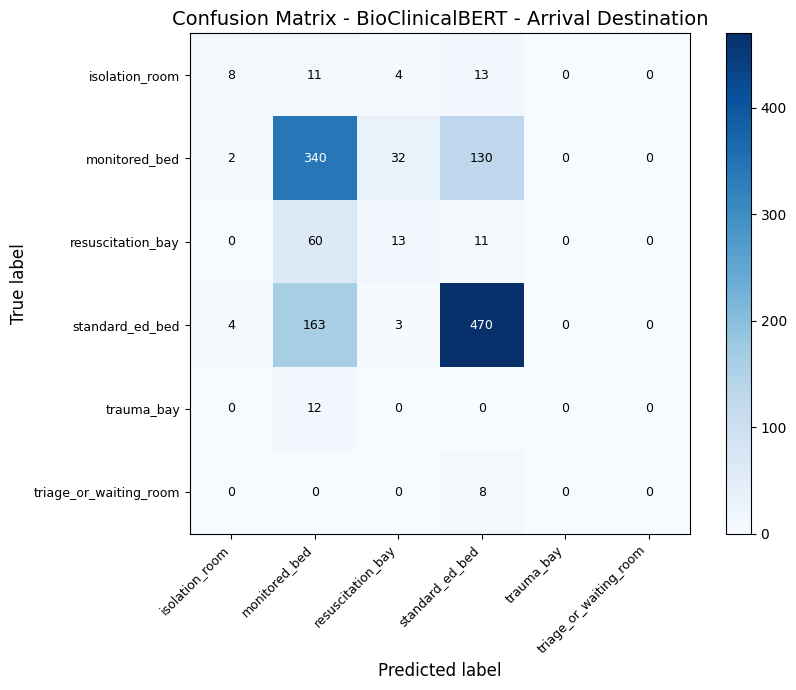

Saved confusion matrix to:
/content/drive/MyDrive/ems_nlp_results/bioclinicalbert_arrival_confusion_matrix_blues.png


In [ ]:
# ============================================================
# Confusion Matrix - BioClinicalBERT - arrival_destination
# Better colors and readable numbers
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

results_dir = "/content/drive/MyDrive/ems_nlp_results"
os.makedirs(results_dir, exist_ok=True)

# Get label names
label_names = list(clinicalbert_arrival_label_encoder.classes_)

# Create confusion matrix
cm = confusion_matrix(
    y_test_arrival_clinicalbert,
    y_pred_arrival_clinicalbert,
    labels=range(len(label_names))
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))

# Use a clearer color map
im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix - BioClinicalBERT - Arrival Destination", fontsize=14)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

ax.set_xticks(np.arange(len(label_names)))
ax.set_yticks(np.arange(len(label_names)))

ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(label_names, fontsize=9)

# Add numbers inside cells with readable color
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm[i, j] > threshold else "black"
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=9,
            color=text_color
        )

fig.colorbar(im, ax=ax)

plt.tight_layout()

confusion_matrix_path = f"{results_dir}/bioclinicalbert_arrival_confusion_matrix_blues.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved confusion matrix to:")
print(confusion_matrix_path)

F1-score per class:


,class,precision,recall,f1-score,support
5,triage_or_waiting_room,0.000000,0.000000,0.000000,8.0
4,trauma_bay,0.000000,0.000000,0.000000,12.0
2,resuscitation_bay,0.250000,0.154762,0.191176,84.0
0,isolation_room,0.571429,0.222222,0.320000,36.0
1,monitored_bed,0.580205,0.674603,0.623853,504.0
3,standard_ed_bed,0.743671,0.734375,0.738994,640.0


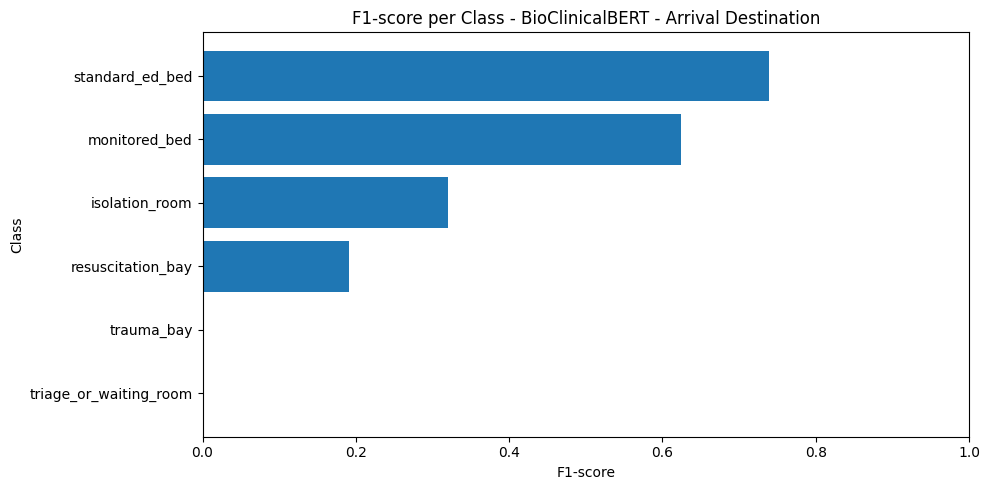

Saved F1 per class plot to:
/content/drive/MyDrive/ems_nlp_results/bioclinicalbert_arrival_f1_per_class.png


In [ ]:
# ============================================================
# F1-score per class - BioClinicalBERT - arrival_destination
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

results_dir = "/content/drive/MyDrive/ems_nlp_results"
os.makedirs(results_dir, exist_ok=True)

label_names = list(clinicalbert_arrival_label_encoder.classes_)

# Create classification report as dictionary
report_dict = classification_report(
    y_test_arrival_clinicalbert,
    y_pred_arrival_clinicalbert,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose().reset_index()
report_df = report_df.rename(columns={"index": "class"})

# Keep only real classes
report_df = report_df[
    ~report_df["class"].isin(["accuracy", "macro avg", "weighted avg"])
].copy()

# Sort by F1-score
report_df = report_df.sort_values("f1-score", ascending=True)

# Display table
print("F1-score per class:")
display(report_df[["class", "precision", "recall", "f1-score", "support"]])

# Plot F1-score per class
plt.figure(figsize=(10, 5))
plt.barh(report_df["class"], report_df["f1-score"])

plt.title("F1-score per Class - BioClinicalBERT - Arrival Destination")
plt.xlabel("F1-score")
plt.ylabel("Class")
plt.xlim(0, 1)
plt.tight_layout()

f1_plot_path = f"{results_dir}/bioclinicalbert_arrival_f1_per_class.png"
plt.savefig(f1_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved F1 per class plot to:")
print(f1_plot_path)

**specialty_consult_label**

In [ ]:
# ============================================================
# Medical Transformer model - BioClinicalBERT - specialty_consult_label
# ============================================================

clinicalbert_specialty_trainer, clinicalbert_specialty_tokenizer, clinicalbert_specialty_label_encoder, y_test_specialty_clinicalbert, y_pred_specialty_clinicalbert = train_transformer_classifier(
    df_train=df_train_specialty,
    df_val=df_val_specialty,
    df_test=df_test_specialty,
    target_column="specialty_consult_label",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_specialty_consult_label",
    max_length=128,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: specialty_consult_label
Model: emilyalsentzer/Bio_ClinicalBERT
Run name: bioclinicalbert_specialty_consult_label
Output directory: ./transformer_results_bioclinicalbert_specialty_consult_label
Number of labels: 18

Label mapping:
0 = cardiology_consult
1 = endocrinology_consult
2 = ent_or_eye_oral_consult
3 = gastroenterology_consult
4 = general_surgery_consult
5 = hematology_oncology_consult
6 = infectious_dermatology_consult
7 = medicine_or_ed_consult
8 = nephrology_consult
9 = neurology_consult
10 = neurosurgery_consult
11 = obgyn_consult
12 = orthopedic_consult
13 = other_consult
14 = psychiatry_addiction_consult
15 = pulmonology_consult
16 = urology_consult
17 = vascular_surgery_consult

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  324
neurosurgery_consult       

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final evaluation on test set:



Accuracy:
0.6565420560747663

Macro F1:
0.49714915145974076

Weighted F1:
0.6382797480111988

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.48      0.55      0.51        60
         endocrinology_consult       0.85      0.71      0.77        24
       ent_or_eye_oral_consult       0.69      0.65      0.67        48
      gastroenterology_consult       0.73      0.85      0.79       336
       general_surgery_consult       0.69      0.68      0.68       188
   hematology_oncology_consult       0.30      0.32      0.31        28
infectious_dermatology_consult       0.61      0.68      0.64        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.11      0.04      0.06        24
             neurology_consult       0.55      0.57      0.56        92
          neurosurgery_consult       0.69      0.52      0.59        92
                 

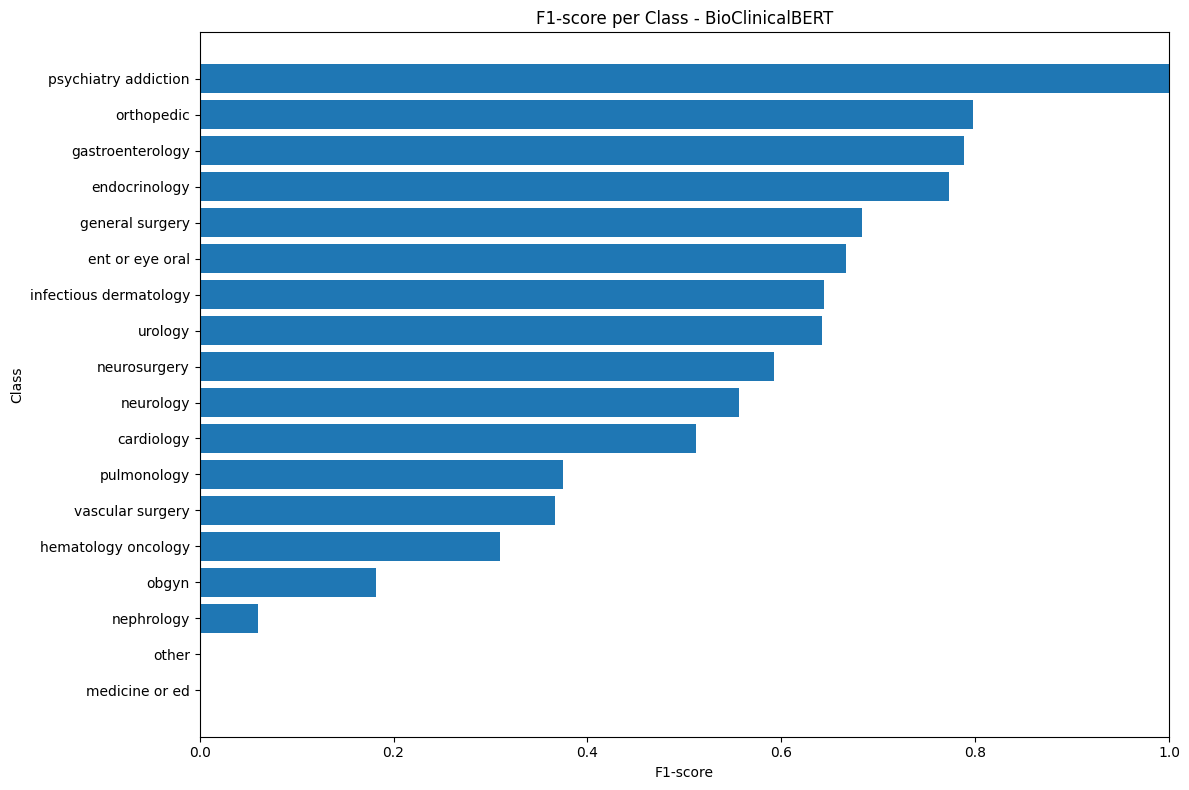

Saved F1 per class plot to:
/content/drive/MyDrive/ems_nlp_results/bioclinicalbert_specialty_f1_per_class.png


In [ ]:
# ============================================================
# F1-score per class - BioClinicalBERT - specialty_consult_label
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

results_dir = "/content/drive/MyDrive/ems_nlp_results"
os.makedirs(results_dir, exist_ok=True)

label_names = list(clinicalbert_specialty_label_encoder.classes_)

report_dict = classification_report(
    y_test_specialty_clinicalbert,
    y_pred_specialty_clinicalbert,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose().reset_index()
report_df = report_df.rename(columns={"index": "class"})

# Keep only real classes
report_df = report_df[
    ~report_df["class"].isin(["accuracy", "macro avg", "weighted avg"])
].copy()

report_df["short_class"] = (
    report_df["class"]
    .str.replace("_consult", "", regex=False)
    .str.replace("_", " ", regex=False)
)

report_df = report_df.sort_values("f1-score", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(report_df["short_class"], report_df["f1-score"])

plt.title("F1-score per Class - BioClinicalBERT")
plt.xlabel("F1-score")
plt.ylabel("Class")
plt.xlim(0, 1)
plt.tight_layout()

f1_plot_path = f"{results_dir}/bioclinicalbert_specialty_f1_per_class.png"
plt.savefig(f1_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved F1 per class plot to:")
print(f1_plot_path)

#### Class-weighted training experiments


In [ ]:
# ============================================================
# Weighted Trainer for imbalanced multi-class classification
# ============================================================

import torch
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
# ============================================================
# Transformer training function with class-weighted loss
# ============================================================

import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    EarlyStoppingCallback
)

def train_weighted_transformer_classifier(
    df_train,
    df_val,
    df_test,
    target_column,
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name=None,
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
):
    print("Target:", target_column)
    print("Model:", model_name)
    print("Weighted loss: True")
    print("Max length:", max_length)
    print("=" * 100)

    # ------------------------------------------------------------
    # 1. Create safe run name
    # ------------------------------------------------------------

    if run_name is None:
        safe_model_name = model_name.replace("/", "_")
        run_name = safe_model_name + "_" + target_column + "_weighted"

    output_dir = "./transformer_results_" + run_name

    print("Run name:", run_name)
    print("Output directory:", output_dir)

    # ------------------------------------------------------------
    # 2. Encode labels
    # ------------------------------------------------------------

    label_encoder = LabelEncoder()

    y_train = label_encoder.fit_transform(df_train[target_column])
    y_val = label_encoder.transform(df_val[target_column])
    y_test = label_encoder.transform(df_test[target_column])

    label_names = list(label_encoder.classes_)
    num_labels = len(label_names)

    print("Number of labels:", num_labels)
    print("\nLabel mapping:")
    for idx, label in enumerate(label_names):
        print(idx, "=", label)

    # ------------------------------------------------------------
    # 3. Compute class weights from training labels only
    # ------------------------------------------------------------

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = torch.tensor(class_weights, dtype=torch.float)

    print("\nClass weights:")
    for label, weight in zip(label_names, class_weights):
        print(label, ":", round(weight.item(), 4))

    # ------------------------------------------------------------
    # 4. Prepare text columns
    # ------------------------------------------------------------

    X_train = df_train["text_cleaned"].fillna("").astype(str)
    X_val = df_val["text_cleaned"].fillna("").astype(str)
    X_test = df_test["text_cleaned"].fillna("").astype(str)

    print("\nTrain size:", len(X_train))
    print("Validation size:", len(X_val))
    print("Test size:", len(X_test))

    print("\nTrain target distribution:")
    print(df_train[target_column].value_counts())

    print("\nValidation target distribution:")
    print(df_val[target_column].value_counts())

    print("\nTest target distribution:")
    print(df_test[target_column].value_counts())

    # ------------------------------------------------------------
    # 5. Load tokenizer and create datasets
    # ------------------------------------------------------------

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = EMSReportDataset(X_train, y_train, tokenizer, max_length=max_length)
    val_dataset = EMSReportDataset(X_val, y_val, tokenizer, max_length=max_length)
    test_dataset = EMSReportDataset(X_test, y_test, tokenizer, max_length=max_length)

    # ------------------------------------------------------------
    # 6. Load model
    # ------------------------------------------------------------

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

    # ------------------------------------------------------------
    # 7. Metrics function
    # ------------------------------------------------------------

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)

        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro"),
            "weighted_f1": f1_score(labels, preds, average="weighted")
        }

    # ------------------------------------------------------------
    # 8. Training arguments
    # ------------------------------------------------------------

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_strategy="epoch",
        save_total_limit=1,
        report_to="none"
    )

    # ------------------------------------------------------------
    # 9. Weighted Trainer
    # ------------------------------------------------------------

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        class_weights=class_weights
    )

    trainer.train()

    # ------------------------------------------------------------
    # 10. Final evaluation on test set
    # ------------------------------------------------------------

    print("\nFinal evaluation on test set:")
    test_output = trainer.predict(test_dataset)

    y_pred = np.argmax(test_output.predictions, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:")
    print(accuracy)

    print("\nMacro F1:")
    print(macro_f1)

    print("\nWeighted F1:")
    print(weighted_f1)

    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    return trainer, tokenizer, label_encoder, y_test, y_pred

In [ ]:
# ============================================================
# Experiment:
# BioClinicalBERT + max_length=192 without weighted loss
# Target: arrival_destination
# ============================================================

clinicalbert_arrival_maxlen192_trainer, clinicalbert_arrival_maxlen192_tokenizer, clinicalbert_arrival_maxlen192_label_encoder, y_test_arrival_clinicalbert_maxlen192, y_pred_arrival_clinicalbert_maxlen192 = train_transformer_classifier(
    df_train=df_train_arrival,
    df_val=df_val_arrival,
    df_test=df_test_arrival,
    target_column="arrival_destination",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_arrival_maxlen192_no_weights",
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: arrival_destination
Model: emilyalsentzer/Bio_ClinicalBERT
Run name: bioclinicalbert_arrival_maxlen192_no_weights
Output directory: ./transformer_results_bioclinicalbert_arrival_maxlen192_no_weights
Number of labels: 6

Label mapping:
0 = isolation_room
1 = monitored_bed
2 = resuscitation_bay
3 = standard_ed_bed
4 = trauma_bay
5 = triage_or_waiting_room

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
arrival_destination
standard_ed_bed           2896
monitored_bed             2492
resuscitation_bay          412
isolation_room             136
triage_or_waiting_room      44
trauma_bay                   8
Name: count, dtype: int64

Validation target distribution:
arrival_destination
standard_ed_bed           680
monitored_bed             480
resuscitation_bay          84
isolation_room             20
triage_or_waiting_room     16
trauma_bay                  4
Name: count, dtype: int64

Test target distribution:
arrival_destination
standard_ed_be

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.905826,0.936907,0.619938,0.231435,0.599164
2,0.661483,0.942933,0.648754,0.284948,0.634413
3,0.497738,1.028030,0.641745,0.277215,0.632313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final evaluation on test set:



Accuracy:
0.647196261682243

Macro F1:
0.28954245049089505

Weighted F1:
0.6302694761384533

Classification report:
                        precision    recall  f1-score   support

        isolation_room       0.56      0.14      0.22        36
         monitored_bed       0.60      0.61      0.60       504
     resuscitation_bay       0.19      0.13      0.15        84
       standard_ed_bed       0.72      0.79      0.76       640
            trauma_bay       0.00      0.00      0.00        12
triage_or_waiting_room       0.00      0.00      0.00         8

              accuracy                           0.65      1284
             macro avg       0.34      0.28      0.29      1284
          weighted avg       0.62      0.65      0.63      1284



In [ ]:
# ============================================================
# Experiment 1:
# BioClinicalBERT + max_length=192 + weighted loss
# Target: specialty_consult_label
# ============================================================

clinicalbert_specialty_weighted_trainer, clinicalbert_specialty_weighted_tokenizer, clinicalbert_specialty_weighted_label_encoder, y_test_specialty_clinicalbert_weighted, y_pred_specialty_clinicalbert_weighted = train_weighted_transformer_classifier(
    df_train=df_train_specialty,
    df_val=df_val_specialty,
    df_test=df_test_specialty,
    target_column="specialty_consult_label",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_specialty_weighted_maxlen192",
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5
)

Target: specialty_consult_label
Model: emilyalsentzer/Bio_ClinicalBERT
Weighted loss: True
Max length: 192
Run name: bioclinicalbert_specialty_weighted_maxlen192
Output directory: ./transformer_results_bioclinicalbert_specialty_weighted_maxlen192
Number of labels: 18

Label mapping:
0 = cardiology_consult
1 = endocrinology_consult
2 = ent_or_eye_oral_consult
3 = gastroenterology_consult
4 = general_surgery_consult
5 = hematology_oncology_consult
6 = infectious_dermatology_consult
7 = medicine_or_ed_consult
8 = nephrology_consult
9 = neurology_consult
10 = neurosurgery_consult
11 = obgyn_consult
12 = orthopedic_consult
13 = other_consult
14 = psychiatry_addiction_consult
15 = pulmonology_consult
16 = urology_consult
17 = vascular_surgery_consult

Class weights:
cardiology_consult : 1.2795
endocrinology_consult : 4.3772
ent_or_eye_oral_consult : 1.9802
gastroenterology_consult : 0.2116
general_surgery_consult : 0.3585
hematology_oncology_consult : 1.5401
infectious_dermatology_consult : 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final evaluation on test set:



Accuracy:
0.5957943925233645

Macro F1:
0.4711265217775614

Weighted F1:
0.5931003471903663

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.55      0.58      0.56        60
         endocrinology_consult       0.67      1.00      0.80        24
       ent_or_eye_oral_consult       0.65      0.83      0.73        48
      gastroenterology_consult       0.74      0.62      0.67       336
       general_surgery_consult       0.55      0.57      0.56       188
   hematology_oncology_consult       0.21      0.29      0.24        28
infectious_dermatology_consult       0.55      0.62      0.58        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.14      0.12      0.13        24
             neurology_consult       0.58      0.42      0.49        92
          neurosurgery_consult       0.65      0.68      0.67        92
                 o

In [ ]:
# ============================================================
# Experiment:
# BioClinicalBERT + max_length=192 + 5 epochs + lower LR
# Target: specialty_consult_label
# ============================================================

clinicalbert_specialty_maxlen192_lr1e5_trainer, clinicalbert_specialty_maxlen192_lr1e5_tokenizer, clinicalbert_specialty_maxlen192_lr1e5_label_encoder, y_test_specialty_clinicalbert_maxlen192_lr1e5, y_pred_specialty_clinicalbert_maxlen192_lr1e5 = train_transformer_classifier(
    df_train=df_train_specialty,
    df_val=df_val_specialty,
    df_test=df_test_specialty,
    target_column="specialty_consult_label",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_specialty_maxlen192_lr1e5_epochs5",
    max_length=192,
    num_epochs=5,
    batch_size=16,
    learning_rate=1e-5
)

Target: specialty_consult_label
Model: emilyalsentzer/Bio_ClinicalBERT
Run name: bioclinicalbert_specialty_maxlen192_lr1e5_epochs5
Output directory: ./transformer_results_bioclinicalbert_specialty_maxlen192_lr1e5_epochs5
Number of labels: 18

Label mapping:
0 = cardiology_consult
1 = endocrinology_consult
2 = ent_or_eye_oral_consult
3 = gastroenterology_consult
4 = general_surgery_consult
5 = hematology_oncology_consult
6 = infectious_dermatology_consult
7 = medicine_or_ed_consult
8 = nephrology_consult
9 = neurology_consult
10 = neurosurgery_consult
11 = obgyn_consult
12 = orthopedic_consult
13 = other_consult
14 = psychiatry_addiction_consult
15 = pulmonology_consult
16 = urology_consult
17 = vascular_surgery_consult

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult                  324
neurosu

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.989278,1.539321,0.545950,0.262483,0.481025
2,1.264443,1.304729,0.633956,0.416580,0.595667
3,0.999073,1.264215,0.644081,0.461331,0.614501
4,0.851556,1.263581,0.649533,0.472701,0.621984
5,0.776519,1.267675,0.647975,0.475393,0.622693


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final evaluation on test set:



Accuracy:
0.6448598130841121

Macro F1:
0.4792383791003327

Weighted F1:
0.6251877185249392

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.49      0.53      0.51        60
         endocrinology_consult       0.75      0.50      0.60        24
       ent_or_eye_oral_consult       0.65      0.58      0.62        48
      gastroenterology_consult       0.69      0.86      0.77       336
       general_surgery_consult       0.70      0.63      0.66       188
   hematology_oncology_consult       0.27      0.29      0.28        28
infectious_dermatology_consult       0.55      0.57      0.56        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.29      0.08      0.13        24
             neurology_consult       0.54      0.53      0.54        92
          neurosurgery_consult       0.70      0.60      0.64        92
                 o

In [ ]:
# ============================================================
# BioClinicalBERT with less aggressive partial freeze
# Target: specialty_consult_label
# Freeze lower layers, train last 8 BERT layers + classifier
# ============================================================

clinicalbert_specialty_freeze_last8_trainer, clinicalbert_specialty_freeze_last8_tokenizer, clinicalbert_specialty_freeze_last8_label_encoder, y_test_specialty_clinicalbert_freeze_last8, y_pred_specialty_clinicalbert_freeze_last8 = train_transformer_classifier_with_freeze(
    df_train=df_train_specialty,
    df_val=df_val_specialty,
    df_test=df_test_specialty,
    target_column="specialty_consult_label",
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    run_name="bioclinicalbert_specialty_maxlen192_freeze_last8",
    max_length=192,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    num_unfrozen_layers=8
)

Target: specialty_consult_label
Model: emilyalsentzer/Bio_ClinicalBERT
Freeze: True
Max length: 192
Run name: bioclinicalbert_specialty_maxlen192_freeze_last8
Output directory: ./transformer_results_bioclinicalbert_specialty_maxlen192_freeze_last8
Number of labels: 18

Label mapping:
0 = cardiology_consult
1 = endocrinology_consult
2 = ent_or_eye_oral_consult
3 = gastroenterology_consult
4 = general_surgery_consult
5 = hematology_oncology_consult
6 = infectious_dermatology_consult
7 = medicine_or_ed_consult
8 = nephrology_consult
9 = neurology_consult
10 = neurosurgery_consult
11 = obgyn_consult
12 = orthopedic_consult
13 = other_consult
14 = psychiatry_addiction_consult
15 = pulmonology_consult
16 = urology_consult
17 = vascular_surgery_consult

Train size: 5988
Validation size: 1284
Test size: 1284

Train target distribution:
specialty_consult_label
gastroenterology_consult          1572
general_surgery_consult            928
orthopedic_consult                 892
neurology_consult  

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Model type: BERT-style
Total transformer layers: 12
Unfrozen last layers: 8
Trainable parameters: 56716818
Total parameters: 108324114
Trainable percentage: 52.36 %


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.903888,1.511875,0.572430,0.327114,0.513396
2,1.254448,1.330395,0.636293,0.438515,0.601145
3,1.045420,1.287308,0.644081,0.455042,0.611501


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final evaluation on test set:



Accuracy:
0.6370716510903427

Macro F1:
0.4642283017165507

Weighted F1:
0.6141826020170363

Classification report:
                                precision    recall  f1-score   support

            cardiology_consult       0.51      0.63      0.57        60
         endocrinology_consult       1.00      0.38      0.55        24
       ent_or_eye_oral_consult       0.66      0.60      0.63        48
      gastroenterology_consult       0.69      0.83      0.75       336
       general_surgery_consult       0.69      0.63      0.66       188
   hematology_oncology_consult       0.27      0.25      0.26        28
infectious_dermatology_consult       0.53      0.57      0.55        56
        medicine_or_ed_consult       0.00      0.00      0.00        24
            nephrology_consult       0.00      0.00      0.00        24
             neurology_consult       0.56      0.54      0.55        92
          neurosurgery_consult       0.75      0.50      0.60        92
                 o